In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from scipy.stats import wilcoxon
import utils
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu, wilcoxon

subjects = ['485', '486', '487', '488', '497', '498', '499', '505', '5107', '515', '520', '545']
controls = ['394', '396', '398', '402', '404', '405', '406', '415', '416', '417'] # noisy- '423', '426', '429'
stim_side = {'485': 'R', '486': 'L', '487': 'R', '488': 'L', '489': 'R', '496': 'R', '497': 'R', '498': 'L', '499': 'L', '505': 'L', '5101': 'R', '5107': 'R', '515': 'R', '520': 'R', '538': 'R', '541': 'L', '544':'R', '545': 'R'}
frontal_chans = [f"{side}{string}{number}" for string in ['OF', 'AC', 'AF', 'FA', 'IF-dAC', 'OPR'] for number in range(1, 9) for side in ['R', 'L']]
temporal_chans = [f"{string}{number}" for string in ['RA', 'LA', 'RAH', 'LAH', 'RMH', 'LMH', 'REC', 'LEC', 'RPHG', 'LPHG'] for number in range(1, 9)]
temporal_soz = ['485', '487', '488', '489', '496', '497', '498', '515', '520', '538', '541', '544']
frontal_soz = ['486', '499', '505', '5101', '5107', '545']
soz_side = {'485': 'R', '486': 'R', '487': 'L', '488': 'R', '489': 'L', '496': 'R', '497': 'B', '498': 'B', '499': 'R', '505': 'L', '5101': 'L', '5107': 'L', '515': 'R', '520': 'B', '538': 'L', '541': 'B', '544':'L', '545': 'L'}
temporal_stim = ['489', '496', '538']

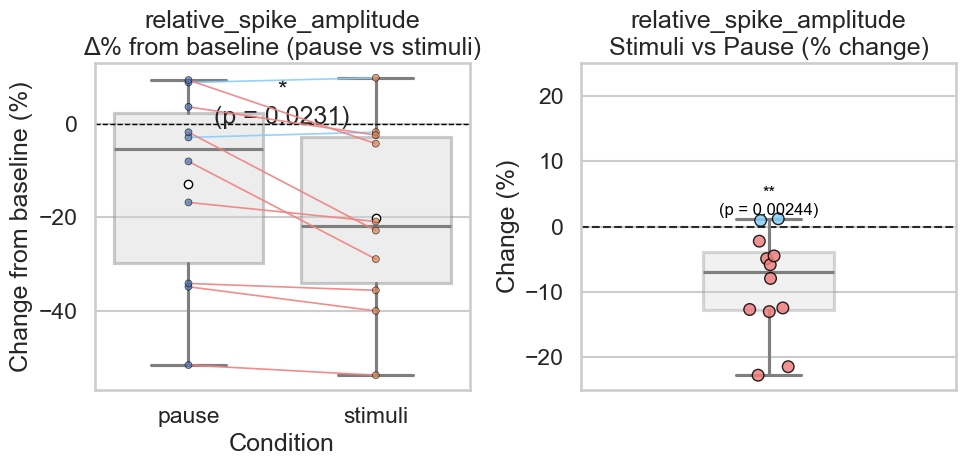

In [2]:
# first from each group
# ----------------------------------------------------
# הגדרות משתמש
# ----------------------------------------------------
subject_ids = [x for x in subjects if x not in ['5101','541', '544']]
base_path = r"D:\Ofer_backup\V6_model"

features = ["amplitude", "relative_spike_duration", "group_event_size", "relative_spike_amplitude", "group_event_spatial_spread", "angle"]
timestamp_col = "timestamp"

baseline_cond   = "before_first_stimuli_session"
condition_order = ["pause_block", "stimuli_block"]
condition_labels = {"pause_block": "pause", "stimuli_block": "stimuli"}

target_param = "relative_spike_amplitude"  # הפיצ'ר להצגה בשני הגרפים

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

# ----------------------------------------------------
# קריאה + ניקוי + ממוצע לכל מצב לכל נבדק (פעם אחת)
# ----------------------------------------------------
all_data = []

for subj in subject_ids:
    feat_path = os.path.join(
        base_path, f"p{subj}", "unichannel_model", "min_amplitude_1",
        "features", f"p{subj}_flat_features.csv"
    )
    if not os.path.exists(feat_path):
        print(f"Missing feature file for subject {subj}")
        continue

    df = pd.read_csv(feat_path)

    cols = ["stimuli_flag", "hypnogram_flag", "channel", "group", timestamp_col] + features
    df = df[cols].copy()

    # רק NREM
    df = df[df["hypnogram_flag"] == "nrem"]
    df = df.drop_duplicates(subset="group", keep="first")


    # סינון ארטיפקטים
    ann_path = fr"D:\Maya\clean Stim Project\P{subj}\P{subj}_annotations_ms.csv"
    df = utils.remove_noisy_samples_and_channels(
        subj, df, ann_path, ts_col="timestamp", channel_col="channel"
    )

    df["subject_id"] = subj

    # ממוצע לכל מצב לכל נבדק
    subj_avg = df.groupby(["subject_id", "stimuli_flag"], as_index=False)[features].mean()
    all_data.append(subj_avg)

data = pd.concat(all_data, ignore_index=True)

# ----------------------------------------------------
# חישוב 1: Δ% מהבייסליין (כמו בקוד הראשון)
# ----------------------------------------------------
df_melt = data.melt(
    id_vars=["subject_id", "stimuli_flag"],
    value_vars=features,
    var_name="Parameter",
    value_name="Value"
)

baseline = (
    df_melt[df_melt["stimuli_flag"] == baseline_cond]
    [["subject_id", "Parameter", "Value"]]
    .rename(columns={"Value": "Baseline"})
)

df_melt = df_melt.merge(baseline, on=["subject_id", "Parameter"], how="left")
df_melt = df_melt[df_melt["Baseline"].notna() & (df_melt["Baseline"] != 0)].copy()
df_melt["Value_pct"] = (df_melt["Value"] - df_melt["Baseline"]) / df_melt["Baseline"] * 100

# ----------------------------------------------------
# חישוב 2: % שינוי Stimuli לעומת Pause (כמו בקוד השני)
# ----------------------------------------------------
data_ps = data[data["stimuli_flag"].isin(condition_order)].copy()
df_pivot = data_ps.pivot(index="subject_id", columns="stimuli_flag", values=features)  # MultiIndex columns

pct_change_df = pd.DataFrame(index=df_pivot.index)
for feat in features:
    val_pause = df_pivot[(feat, "pause_block")]
    val_stim  = df_pivot[(feat, "stimuli_block")]

    ok = val_pause.notna() & (val_pause != 0) & val_stim.notna()
    pct_change_df.loc[ok, feat] = ((val_stim[ok] - val_pause[ok]) / val_pause[ok]) * 100

df_plot = pct_change_df.melt(var_name="Parameter", value_name="Percent_Change", ignore_index=False).reset_index()

# ----------------------------------------------------
# ויזואליזציה: שני גרפים אחד ליד השני
# ----------------------------------------------------
sns.set(style="whitegrid", context="talk")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# ========== גרף שמאל: Pause vs Stimuli על ציר Δ% מהבייסליין ==========
df_left = df_melt[
    (df_melt["Parameter"] == target_param) &
    (df_melt["stimuli_flag"].isin(condition_order))
].copy()

ax1.axhline(0, color="black", linestyle="--", linewidth=1)

sns.boxplot(
    data=df_left,
    x="stimuli_flag",
    y="Value_pct",
    order=condition_order,
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"},
    fliersize=2,
    color="lightgray",
    boxprops=dict(alpha=0.4),
    zorder=1,
    ax=ax1
)

wide_left = df_left.pivot(index="subject_id", columns="stimuli_flag", values="Value_pct").reindex(columns=condition_order)
wide_left_clean = wide_left.dropna()

# paired t-test (stim vs pause)
if len(wide_left_clean) >= 2:
    pause_vals = wide_left_clean["pause_block"].values
    stim_vals  = wide_left_clean["stimuli_block"].values
    t_stat, p_t = ttest_rel(stim_vals, pause_vals)
    ax1.text(0.5, 0.95, f"{p_to_stars(p_t)}\n(p = {p_t:.3g})",
             transform=ax1.transAxes, ha="center", va="top")

# קווים מחברים לכל נבדק
x_positions = np.arange(len(condition_order))
for subj, row in wide_left.iterrows():
    y = row.values.astype(float)
    mask = ~np.isnan(y)
    xs = x_positions[mask]
    ys = y[mask]
    if len(ys) < 2:
        continue

    slope = ys[-1] - ys[0]
    line_color = "lightskyblue" if slope > 0 else ("lightcoral" if slope < 0 else "lightgray")
    ax1.plot(xs, ys, color=line_color, alpha=0.9, linewidth=1.2, zorder=3)

sns.stripplot(
    data=df_left,
    x="stimuli_flag",
    y="Value_pct",
    order=condition_order,
    jitter=False,
    linewidth=0.5,
    edgecolor="black",
    alpha=0.7,
    size=5,
    zorder=4,
    ax=ax1
)

ax1.set_title(f"{target_param}\nΔ% from baseline (pause vs stimuli)")
ax1.set_xlabel("Condition")
ax1.set_ylabel("Change from baseline (%)")
ax1.set_xticklabels([condition_labels[c] for c in condition_order])

# ========== גרף ימין: Stimuli vs Pause %Change מול 0 ==========
df_right = df_plot[df_plot["Parameter"] == target_param].copy()
values = df_right["Percent_Change"].dropna()

ax2.axhline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.8)

# Boxplot (עמודה אחת)
sns.boxplot(
    y=values,
    width=0.35,
    color="lightgray",
    boxprops=dict(alpha=0.3),
    showfliers=False,
    ax=ax2
)

# נקודות בצביעה לפי סימן (matplotlib, כדי להימנע מטריקים של seaborn)
rng = np.random.default_rng(0)
x_jitter = rng.normal(loc=0.0, scale=0.04, size=len(values))
colors = np.where(values > 0, "lightskyblue", "lightcoral")
ax2.scatter(x_jitter, values, s=70, c=colors, edgecolors="black", linewidths=1, alpha=0.85, zorder=3)

# Wilcoxon מול 0
if len(values) >= 1:
    stat, p_val = wilcoxon(values)  # signed-rank vs 0
    stars = p_to_stars(p_val)
    y_max = float(np.nanmax(values)) if len(values) else 1.0
    ax2.text(0, y_max + (abs(y_max) * 0.12 + 1e-6), f"{stars}\n(p = {p_val:.3g})",
             ha="center", va="bottom", fontsize=12, color="black")

# גבולות יפים סימטריים
if len(values) > 0:
    limit = max(abs(values.min()), abs(values.max())) * 1.1
    ax2.set_ylim(-limit, limit)

ax2.set_title(f"{target_param}\nStimuli vs Pause (% change)")
ax2.set_ylabel("Change (%)")
ax2.set_xlabel("")
ax2.set_xticks([])

plt.tight_layout()
plt.show()


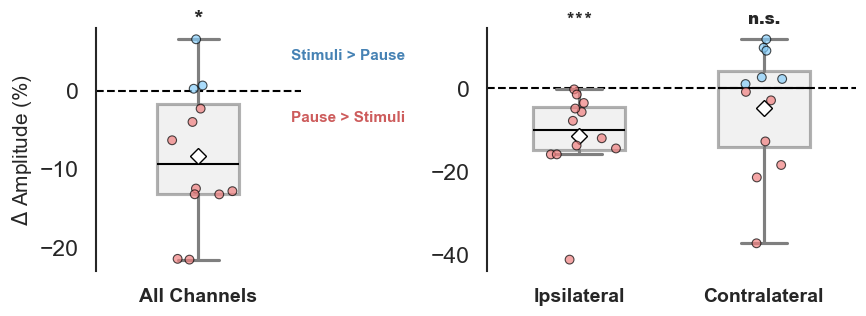

In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import utils

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

def compute_pct_change_pause_vs_stim(data, index_cols, feats):
    cond_order = ["pause_block", "stimuli_block"]
    data_ps = data[data["stimuli_flag"].isin(cond_order)].copy()
    
    # וידוא שאין כפילויות לפני הפיבוט
    data_ps = data_ps.groupby(index_cols + ["stimuli_flag"])[feats].mean().reset_index()
    
    df_pivot = data_ps.pivot(index=index_cols, columns="stimuli_flag", values=feats)
    pct_change_df = pd.DataFrame(index=df_pivot.index)
    
    for feat in feats:
        val_pause = df_pivot[(feat, "pause_block")]
        val_stim  = df_pivot[(feat, "stimuli_block")]
        ok = val_pause.notna() & (val_pause != 0) & val_stim.notna()
        pct_change_df.loc[ok, feat] = ((val_stim[ok] - val_pause[ok]) / val_pause[ok]) * 100
        
    return pct_change_df.melt(var_name="Parameter", value_name="Percent_Change", ignore_index=False).reset_index()

# ----------------------------------------------------
# 1. עיבוד נתונים (כולל תיקון NREM והסרת כפילויות)
# ----------------------------------------------------
all_data_lat = [] # עבור הגרף הימני (Ipsi/Contra)
all_data_all = [] # עבור הגרף השמאלי (All Channels - משוקלל נכון)
subject_ids_to_run = [x for x in subjects if x not in ['5101','541', '544']]

for subj in subject_ids_to_run:
    feat_path = os.path.join(base_path, f"p{subj}", "unichannel_model", "min_amplitude_1", "features", f"p{subj}_flat_features.csv")
    if not os.path.exists(feat_path): continue
    
    df = pd.read_csv(feat_path)
    
    # חובה: סינון NREM והסרת כפילויות כדי לשמור על עקביות
    # df = df[df["hypnogram_flag"] == "nrem"].copy() 
    df = df.drop_duplicates(subset="group", keep="first")
    
    ann_path = fr"D:\Maya\clean Stim Project\P{subj}\P{subj}_annotations_ms.csv"
    try:
        df = utils.remove_noisy_samples_and_channels(subj, df, ann_path, ts_col="timestamp", channel_col="channel")
    except: continue
    
    df["subject_id"] = subj
    stim = stim_side.get(str(subj))
    df["chan_side"] = df["channel"].astype(str).str[0]
    
    # סינון לערוצים רלוונטיים (R/L)
    df_lat = df[df["chan_side"].isin(["R", "L"])].copy()
    
    if stim:
        # 1. חישוב עבור הגרף המפוצל (הממוצע נשמר לפי lat_group)
        df_lat["lat_group"] = np.where(df_lat["chan_side"] == stim, "ipsi", "contra")
        subj_avg_lat = df_lat.groupby(["subject_id", "stimuli_flag", "lat_group"], as_index=False)[[target_param]].mean()
        all_data_lat.append(subj_avg_lat)
        
        # 2. חישוב עבור הגרף המאוחד (מתעלמים מהצד, כל הערוצים מקבלים משקל שווה בממוצע)
        subj_avg_all = df_lat.groupby(["subject_id", "stimuli_flag"], as_index=False)[[target_param]].mean()
        all_data_all.append(subj_avg_all)

# איחוד הנתונים בנפרד
data_lat_combined = pd.concat(all_data_lat, ignore_index=True)
data_all_combined = pd.concat(all_data_all, ignore_index=True)

# חישוב אחוז השינוי על אובייקטים נפרדים
df_plot_lat = compute_pct_change_pause_vs_stim(data_lat_combined, ["subject_id", "lat_group"], [target_param])
df_plot_all = compute_pct_change_pause_vs_stim(data_all_combined, ["subject_id"], [target_param])
# ----------------------------------------------------
# ויזואליזציה מאוחדת: לייבלים נקיים וסטטיסטיקה מיושרת
# ----------------------------------------------------
sns.set(style="white", context="talk")

# יצירת Figure עם צירים עצמאיים
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5), sharey=False, gridspec_kw={'width_ratios': [1, 1.8]})

# --- גרף שמאל: All Channels ---
vals_all = df_plot_all[df_plot_all["Parameter"] == target_param]["Percent_Change"].dropna()
ax1.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)

sns.boxplot(y=vals_all, width=0.4, color="lightgray", showmeans=True, ax=ax1,
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":8},
            boxprops=dict(alpha=0.3, edgecolor="black"), medianprops=dict(color="black", linewidth=1.5), 
            showfliers=False, zorder=2)

rng1 = np.random.default_rng(3)
xj1 = rng1.normal(loc=0.0, scale=0.05, size=len(vals_all))
ax1.scatter(xj1, vals_all, s=40, c=np.where(vals_all > 0, "lightskyblue", "lightcoral"), 
            edgecolors="black", linewidths=0.8, alpha=0.7, zorder=3)

# סטטיסטיקה (ax1)
_, p_all = wilcoxon(vals_all)
y_max_all = vals_all.max()
ax1.text(0, y_max_all + abs(y_max_all)*0.2, f"{p_to_stars(p_all)}", ha="center", va="bottom", fontsize=15, fontweight='heavy')

# לייבלים וכיתובים כיווניים (רק בגרף השמאלי)
ax1.set_xticks([0])
ax1.set_xticklabels(["All Channels"], fontsize=14, fontweight='bold')
curr_ylim1 = ax1.get_ylim()
ax1.text(0.45, 4, "Stimuli > Pause", color="steelblue", fontsize=11, fontweight='bold', ha='left')
ax1.text(0.45, -4, "Pause > Stimuli", color="indianred", fontsize=11, fontweight='bold', ha='left')

# --- גרף ימין: By Laterality (Ipsi/Contra) ---
df_plot_final = df_plot_lat[df_plot_lat["Parameter"] == target_param].copy()
lat_order = ["ipsi", "contra"]
ax2.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)

sns.boxplot(data=df_plot_final, x="lat_group", y="Percent_Change", order=lat_order, width=0.5, color="lightgray", 
            showmeans=True, ax=ax2, meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":8},
            boxprops=dict(alpha=0.3, edgecolor="black"), medianprops=dict(color="black", linewidth=1.5), 
            showfliers=False, zorder=2)

# חישוב גובה אחיד לכוכביות בגרף הימני
y_max_lat = df_plot_final[df_plot_final["lat_group"].isin(lat_order)]["Percent_Change"].max()
star_y_lat = y_max_lat + abs(y_max_lat)*0.25


for i, grp in enumerate(lat_order):
    vals = df_plot_final[df_plot_final["lat_group"] == grp]["Percent_Change"].dropna().values
    rng2 = np.random.default_rng(3 + i)
    xj2 = rng2.normal(loc=i, scale=0.06, size=len(vals))
    ax2.scatter(xj2, vals, s=40, c=np.where(vals > 0, "lightskyblue", "lightcoral"), 
                edgecolors="black", linewidths=0.8, alpha=0.7, zorder=3)
    
    _, p_v = wilcoxon(vals)
    # שימוש ב-star_y_lat האחיד לשני הבוקסים
    ax2.text(i, star_y_lat, f"{p_to_stars(p_v)}", ha="center", va="bottom", fontsize=12, fontweight='heavy')

ax2.set_xlabel("")
ax2.set_xticklabels(["Ipsilateral", "Contralateral"], fontsize=14, fontweight='bold')

# --- עיצוב סופי ---
for ax_obj in [ax1, ax2]:
    for spine in ['top', 'right', 'bottom']: ax_obj.spines[spine].set_visible(False)
    ax_obj.spines['left'].set_linewidth(1.5)

ax1.set_ylabel("$\Delta$ Amplitude (%)", fontsize=15)
ax2.set_ylabel("")

plt.tight_layout()

plt.show()


   STATISTICAL ANALYSIS RESULTS
1. All Channels (vs 0):      p = 0.01611 (*)
2. Ipsilateral (vs 0):       p = 0.00049 (***)
3. Contralateral (vs 0):     p = 0.51855 (n.s.)
4. Comparison (Ipsi vs Contra): p = 0.20361 (n.s.)


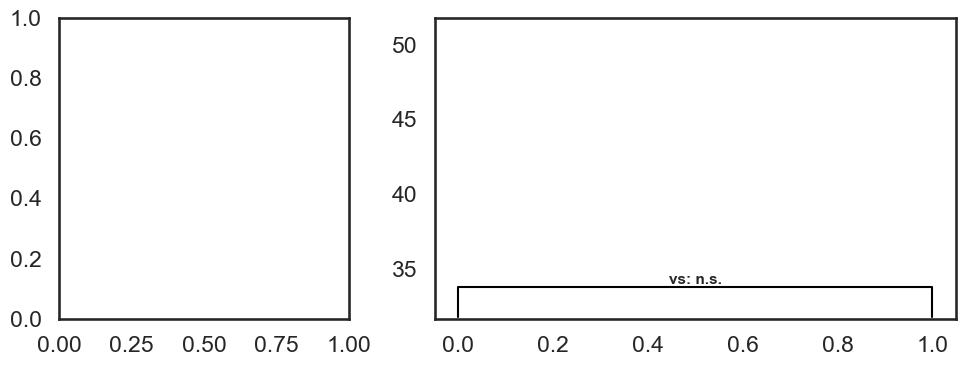

In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import utils

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

def compute_pct_change_pause_vs_stim(data, index_cols, feats):
    cond_order = ["pause_block", "stimuli_block"]
    data_ps = data[data["stimuli_flag"].isin(cond_order)].copy()
    
    # וידוא שאין כפילויות לפני הפיבוט
    data_ps = data_ps.groupby(index_cols + ["stimuli_flag"])[feats].mean().reset_index()
    
    df_pivot = data_ps.pivot(index=index_cols, columns="stimuli_flag", values=feats)
    pct_change_df = pd.DataFrame(index=df_pivot.index)
    
    for feat in feats:
        val_pause = df_pivot[(feat, "pause_block")]
        val_stim  = df_pivot[(feat, "stimuli_block")]
        ok = val_pause.notna() & (val_pause != 0) & val_stim.notna()
        pct_change_df.loc[ok, feat] = ((val_stim[ok] - val_pause[ok]) / val_pause[ok]) * 100
        
    return pct_change_df.melt(var_name="Parameter", value_name="Percent_Change", ignore_index=False).reset_index()

# ----------------------------------------------------
# 1. עיבוד נתונים (כולל תיקון NREM והסרת כפילויות)
# ----------------------------------------------------
all_data_lat = [] # עבור הגרף הימני (Ipsi/Contra)
all_data_all = [] # עבור הגרף השמאלי (All Channels - משוקלל נכון)
subject_ids_to_run = [x for x in subjects if x not in ['5101','541', '544']]

for subj in subject_ids_to_run:
    feat_path = os.path.join(base_path, f"p{subj}", "unichannel_model", "min_amplitude_1", "features", f"p{subj}_flat_features.csv")
    if not os.path.exists(feat_path): continue
    
    df = pd.read_csv(feat_path)
    
    # חובה: סינון NREM והסרת כפילויות כדי לשמור על עקביות
    # df = df[df["hypnogram_flag"] == "nrem"].copy() 
    df = df.drop_duplicates(subset="group", keep="first")
    
    ann_path = fr"D:\Maya\clean Stim Project\P{subj}\P{subj}_annotations_ms.csv"
    try:
        df = utils.remove_noisy_samples_and_channels(subj, df, ann_path, ts_col="timestamp", channel_col="channel")
    except: continue
    
    df["subject_id"] = subj
    stim = stim_side.get(str(subj))
    df["chan_side"] = df["channel"].astype(str).str[0]
    
    # סינון לערוצים רלוונטיים (R/L)
    df_lat = df[df["chan_side"].isin(["R", "L"])].copy()
    
    if stim:
        # 1. חישוב עבור הגרף המפוצל (הממוצע נשמר לפי lat_group)
        df_lat["lat_group"] = np.where(df_lat["chan_side"] == stim, "ipsi", "contra")
        subj_avg_lat = df_lat.groupby(["subject_id", "stimuli_flag", "lat_group"], as_index=False)[[target_param]].mean()
        all_data_lat.append(subj_avg_lat)
        
        # 2. חישוב עבור הגרף המאוחד (מתעלמים מהצד, כל הערוצים מקבלים משקל שווה בממוצע)
        subj_avg_all = df_lat.groupby(["subject_id", "stimuli_flag"], as_index=False)[[target_param]].mean()
        all_data_all.append(subj_avg_all)

# איחוד הנתונים בנפרד
data_lat_combined = pd.concat(all_data_lat, ignore_index=True)
data_all_combined = pd.concat(all_data_all, ignore_index=True)
# --- 1. המשך ישיר אחרי חישוב אחוזי השינוי ---
df_plot_lat = compute_pct_change_pause_vs_stim(data_lat_combined, ["subject_id", "lat_group"], [target_param])
df_plot_all = compute_pct_change_pause_vs_stim(data_all_combined, ["subject_id"], [target_param])

# --- 2. חישוב והדפסת סטטיסטיקה (לפני הציור) ---
print("\n" + "="*30)
print("   STATISTICAL ANALYSIS RESULTS")
print("="*30)

# בדיקת All Channels (האם שונה מ-0)
vals_all = df_plot_all[df_plot_all["Parameter"] == target_param]["Percent_Change"].dropna()
stat_all, p_all = wilcoxon(vals_all)
print(f"1. All Channels (vs 0):      p = {p_all:.5f} ({p_to_stars(p_all)})")

# הכנת נתונים להשוואת צדדים (חשוב למיין לפי subject_id כדי שהזיווג יהיה נכון)
df_lat_final = df_plot_lat[df_plot_lat["Parameter"] == target_param].copy()
ipsi_data = df_lat_final[df_lat_final["lat_group"] == "ipsi"].set_index("subject_id")["Percent_Change"].sort_index()
contra_data = df_lat_final[df_lat_final["lat_group"] == "contra"].set_index("subject_id")["Percent_Change"].sort_index()

# שומרים רק נבדקים שקיימים בשני הצדדים לצורך המבחן המזווג
common_subs = ipsi_data.index.intersection(contra_data.index)
v_ipsi = ipsi_data.loc[common_subs]
v_contra = contra_data.loc[common_subs]

# מבחני Wilcoxon
stat_ipsi, p_ipsi = wilcoxon(v_ipsi)
stat_contra, p_contra = wilcoxon(v_contra)
stat_comp, p_comp = wilcoxon(v_ipsi, v_contra) # השוואה בין הצדדים

print(f"2. Ipsilateral (vs 0):       p = {p_ipsi:.5f} ({p_to_stars(p_ipsi)})")
print(f"3. Contralateral (vs 0):     p = {p_contra:.5f} ({p_to_stars(p_contra)})")
print(f"4. Comparison (Ipsi vs Contra): p = {p_comp:.5f} ({p_to_stars(p_comp)})")
print("="*30)

# --- 3. ויזואליזציה (עם תוספת קו ההשוואה) ---
sns.set(style="white", context="talk")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 1.8]})

# [כאן נכנס קוד הציור המקורי שלך עבור ax1 ו-ax2...]
# (דילגתי על הקוד הקיים שלך כדי לקצר, פשוט תשאיר אותו כמו שהוא)

# --- הוספת שכבת הסטטיסטיקה מעל ax2 (בסוף הלופ של ה-scatter) ---
# נשתמש ב-y_max_lat שכבר חישבת במקור
star_y_lat = df_lat_final["Percent_Change"].max() + 5 

# קו השוואה בין Ipsi ל-Contra
y_compare = star_y_lat + 15
ax2.plot([0, 0, 1, 1], [y_compare, y_compare+2, y_compare+2, y_compare], lw=1.5, c='black')
ax2.text(0.5, y_compare+2, f"vs: {p_to_stars(p_comp)}", ha="center", va="bottom", fontsize=11, fontweight='bold')

# וידוא שגבול הציר מספיק גבוה לכל הכוכביות
ax2.set_ylim(ax2.get_ylim()[0], y_compare + 20)

plt.tight_layout()
plt.show()

# time-related analysis

In [23]:
stim_side_right = ['485', '487', '489', '490', '496', '497', '5101', '5107', '515', '520', '538', '544', '545',
                       '396', '398', '404', '406', '415']
controls = ['394', '396', '398', '402', '404', '406', '415', '416', '417', '423']
plot_legend = ['all', 'ipsi', 'contra', 'frontal', 'temporal']
frontal_chans = [f"{side}{string}{number}" for string in ['OF', 'AC', 'AF', 'FA', 'IF-dAC', 'OPR'] for number in range(1, 9) for side in ['R', 'L']]
temporal_chans = [f"{string}{number}" for string in ['RA', 'LA', 'RAH', 'LAH', 'RMH', 'LMH', 'REC', 'LEC', 'RPHG', 'LPHG'] for number in range(1, 9)]
feat_path = r'D:\Ofer_backup\V6_model\p%s\unichannel_model\min_amplitude_1\features\p%s_flat_features.csv'
curr_run_subjects = subjects
is_control = curr_run_subjects == controls
for_avg_props = {}
for_avg_props_raw = {} 
baselines = [] 
base_relative = True

scaler = StandardScaler()
def get_subj_data(subj):
    df = pd.read_csv(feat_path % (subj, subj))

    # נוסיף גם timestamp + channel
    cols = ["timestamp", "channel", "amplitude", "duration", "group", "group_event_duration", "group_event_size",
            "group_event_deepest",
            "group_event_shallowest", "group_event_spatial_spread", "stimuli_flag", "hypnogram_flag", "angle",
            "relative_spike_amplitude", "relative_spike_duration"]
    df = df[cols].copy()

    # רק NREM
    # df = df[df["hypnogram_flag"] == "nrem"]
    df = df.drop_duplicates(subset="group", keep="first")

    # סינון דגימות מלוכלכות לפי קובץ הארטיפקטים של אותו נבדק
    ann_path = fr"D:\Maya\clean Stim Project\P{subj}\P{subj}_annotations_ms.csv"
    df = utils.remove_noisy_samples_and_channels(subj, df, ann_path, ts_col="timestamp", channel_col="channel")

    df["subject_id"] = subj
    return df


def init_dicts_with_baseline_rates(subj_features, nrem_start, stim_start, side):
    baseline_minutes = (stim_start - nrem_start) / 60
    baselines.append(baseline_minutes)
    # if there is no sleep before first stim (515, 545)
    # TODO: remove 515 and 545?! maybe avg across all
    if baseline_minutes < 0:
        # take 10 minutes before stimuli as baseline
        baseline = subj_features[(subj_features['timestamp'] > (stim_start - 10 * 60) * 1000) &
                                 (subj_features['timestamp'] < stim_start * 1000)]
        baseline_minutes = 10
    else:
        # take epochs after sleep onset but before first stimuli as baseline
        # baseline = subj_features[subj_features['stimuli_flag'] == 'before_first_stimuli_session']
        baseline = subj_features[(subj_features['stimuli_flag'] == 'before_first_stimuli_session') & (
                    subj_features['timestamp'] > nrem_start * 1000)]
    # נסדר לפי זמן כדי שה"שורה הראשונה" תהיה באמת הכי מוקדמת בזמן
    baseline = baseline.sort_values('timestamp')
    # לקחת שורה ראשונה לכל group
    baseline_groups = baseline.groupby('group', as_index=False).first()

    base_rate = len(baseline_groups) / baseline_minutes
    rates = {'all': [base_rate],
             'ipsi': [len(baseline_groups[baseline_groups['channel'].str[0] == side]) / baseline_minutes],
             'contra': [len(baseline_groups[baseline_groups['channel'].str[0] != side]) / baseline_minutes],
             'frontal': [len(baseline_groups[baseline_groups['channel'].isin(frontal_chans)]) / baseline_minutes],
             'temporal': [len(baseline_groups[baseline_groups['channel'].isin(temporal_chans)]) / baseline_minutes]}
    props = {'rates': rates}
    for prop in ['relative_spike_amplitude', 'relative_spike_duration', 'group_event_size',
                 'group_event_spatial_spread']:
        if 'group' in prop:
            baseline_prop = baseline_groups
        else:
            baseline_prop = baseline
        curr = {'all': [np.mean(baseline_prop[prop])],
                'ipsi': [np.mean(baseline_prop[baseline_prop['channel'].str[0] == side][prop])],
                'contra': [np.mean(baseline_prop[baseline_prop['channel'].str[0] != side][prop])],
                'frontal': [np.mean(baseline_prop[baseline_prop['channel'].isin(frontal_chans)][prop])],
                'temporal': [np.mean(baseline_prop[baseline_prop['channel'].isin(temporal_chans)][prop])]}
        props[prop] = curr

    n_chans = {'all': subj_features['channel'].nunique(),
               'ipsi': subj_features[subj_features['channel'].str[0] == side]['channel'].nunique(),
               'contra': subj_features[subj_features['channel'].str[0] != side]['channel'].nunique(),
               'frontal': subj_features[subj_features['channel'].isin(frontal_chans)]['channel'].nunique(),
               'temporal': subj_features[subj_features['channel'].isin(temporal_chans)]['channel'].nunique()}
    return props, n_chans


def append_to_props(props, curr_df, side, time):
    # rates
    groups_df = curr_df.groupby('group', as_index=False).first()
    props['rates']['all'].append(len(groups_df) / time)
    props['rates']['ipsi'].append(len(groups_df[groups_df['channel'].str[0] == side]) / time)
    props['rates']['contra'].append(len(groups_df[groups_df['channel'].str[0] != side]) / time)
    props['rates']['frontal'].append(len(groups_df[groups_df['channel'].isin(frontal_chans)]) / time)
    props['rates']['temporal'].append(len(groups_df[groups_df['channel'].isin(temporal_chans)]) / time)
    # props
    for prop in ['relative_spike_amplitude', 'relative_spike_duration', 'group_event_size',
                 'group_event_spatial_spread']:
        if 'group' in prop:
            df = groups_df
        else:
            df = curr_df
        props[prop]['all'].append(np.mean(df[prop]))
        props[prop]['ipsi'].append(np.mean(df[df['channel'].str[0] == side][prop]))
        props[prop]['contra'].append(np.mean(df[df['channel'].str[0] != side][prop]))
        props[prop]['frontal'].append(np.mean(df[df['channel'].isin(frontal_chans)][prop]))
        props[prop]['temporal'].append(np.mean(df[df['channel'].isin(temporal_chans)][prop]))



# with and without norm
for subj in curr_run_subjects:  # for now removing 515 and 545 because they don't have baseline before stimuli
    stim_side = 'R' if subj in stim_side_right else 'L'
    final_features = get_subj_data(subj)
    if is_control:
        nrem_epochs = utils.get_control_nrem_epochs(subj)
        # remove first 30 minutes for control (like we started recording 30 min after sleep onset)
        final_features = final_features[(final_features['timestamp'] > (nrem_epochs[0][0] + 30 * 60) * 1000)]
        # initiate all data to new time zero for stimuli timings
        final_features['timestamp'] = final_features['timestamp'] - ((nrem_epochs[0][0] + 30 * 60) * 1000)
        nrem_epochs_unreal, nrem_stim_epochs, stim_epochs = utils.get_nrem_epochs(utils.control_stim[subj])
    else:
        nrem_epochs, nrem_stim_epochs, stim_epochs = utils.get_nrem_epochs(subj)
    props, n_chans = init_dicts_with_baseline_rates(final_features, nrem_epochs[0][0], stim_epochs[0][0], stim_side)

    for i, (start, end) in enumerate(stim_epochs):
        stim_block = final_features[
            (final_features['timestamp'] > start * 1000) & (final_features['timestamp'] < end * 1000)]
        stim_minutes = (end - start) / 60
        append_to_props(props, stim_block, stim_side, stim_minutes)
        if i + 1 < len(stim_epochs):
            pause_block = final_features[(final_features['timestamp'] > end * 1000) & (
                        final_features['timestamp'] < stim_epochs[i + 1][0] * 1000)]
            pause_minutes = (stim_epochs[i + 1][0] - end) / 60
            append_to_props(props, pause_block, stim_side, pause_minutes)
        else:
            # for now using only 5 minutes after last stimuli
            after = final_features[
                (final_features['timestamp'] > end * 1000) & (final_features['timestamp'] < (end + 60 * 5) * 1000)]
            append_to_props(props, after, stim_side, 5)

    # plot the spike rate in each epoch here
    for prop in props.keys():
        if prop not in for_avg_props.keys():
            for_avg_props[prop] = {legend: [] for legend in props[prop].keys()}
        if prop not in for_avg_props_raw.keys():
            for_avg_props_raw[prop] = {legend: [] for legend in props[prop].keys()}
        for (legend, curr_rates) in props[prop].items():
            if legend in plot_legend:
                if base_relative:
                    baseline_val = curr_rates[0] if curr_rates[0] != 0 else 1e-9  # מניעת חלוקה באפס
                    norm = [(x - baseline_val) / baseline_val for x in curr_rates]
                else:
                    norm = scaler.fit_transform(np.array(curr_rates).reshape(-1, 1)).flatten()
                for_avg_props[prop][legend].append(norm)
                for_avg_props_raw[prop][legend].append(curr_rates)
                    

In [7]:
import pandas as pd
import numpy as np

summary_data = []

# Process all subjects in your run
for subj in curr_run_subjects:
    # 1. Get Epochs
    if is_control:
        _, _, stim_epochs = utils.get_nrem_epochs(utils.control_stim[subj])
    else:
        _, _, stim_epochs = utils.get_nrem_epochs(subj)
    
    # 2. Number of stimulation sessions
    num_sessions = len(stim_epochs)
    
    # 3. Total time: (Last End + 5 min) - First Start
    first_stim_start = stim_epochs[0][0]
    last_stim_end = stim_epochs[-1][1]
    total_time_min = ((last_stim_end - first_stim_start) + (5 * 60)) / 60
    avg_session_time = total_time_min / num_sessions 

    # 4. Baseline (Handle the excluded subjects)
    # If the subject was 515 or 545, we don't have a 'natural' baseline recorded in your 'baselines' list
    # We can flag it as NaN so it doesn't break the Mean/Std calculations
    if subj in ['515', '545']:
        subj_baseline = np.nan
    else:
        # We need to find the index in the original 'valid_subjects' list to match 'baselines'
        valid_subs = [x for x in curr_run_subjects if x not in ['515', '545']]
        if subj in valid_subs:
            idx = valid_subs.index(subj)
            subj_baseline = baselines[idx]
        else:
            subj_baseline = np.nan

    summary_data.append({
        'Subject': subj,
        'Baseline_Min': subj_baseline,
        'Num_Sessions': num_sessions,
        'Total_Stim_to_After_Min': total_time_min,
        'Avg_Session_Time_Min': avg_session_time
    })

df_summary = pd.DataFrame(summary_data)

# Calculate stats - .mean() and .std() automatically ignore NaN values
stats = df_summary[['Baseline_Min', 'Num_Sessions', 'Total_Stim_to_After_Min', 'Avg_Session_Time_Min']].agg(['min', 'max', 'mean', 'std']).T

print("--- Per Patient Information (Including 515/545) ---")
print(df_summary)
print("\n--- Aggregate Statistics ---")
print(stats)

--- Per Patient Information (Including 515/545) ---
   Subject  Baseline_Min  Num_Sessions  Total_Stim_to_After_Min  \
0      485     52.176783             4                52.229033   
1      486     43.615217             4                72.061550   
2      487     14.987617             6               114.767500   
3      488     77.243933             7                91.789450   
4      497     16.927700            15               186.056650   
5      498     35.634867            12               134.968867   
6      499      5.871083             8                89.187333   
7      505    106.095467             5                50.051517   
8     5107    119.586633             5                50.146767   
9      515           NaN             6               102.752067   
10     520      9.072658             4                39.901842   
11     545           NaN             5                51.027383   

    Avg_Session_Time_Min  
0              13.057258  
1              18.0153

In [8]:
def get_clean_matrix(raw_data_list, mode='baseline', max_points=13, threshold=3):
    all_rows = []
    for subj_rates in raw_data_list:
        subj_rates = np.array(subj_rates)[:max_points]
        if len(subj_rates) < 2: continue
        
        if mode == 'baseline':
            b = subj_rates[0]
            if b == 0: continue
            vals = ((subj_rates - b) / b) * 100
        else: # consecutive
            prev = subj_rates[:-1]
            denom = np.where(prev == 0, 1e-9, prev)
            vals = np.insert(((subj_rates[1:] - prev) / denom) * 100, 0, 0)
        
        padded = np.full(max_points, np.nan)
        padded[:len(vals)] = vals
        all_rows.append(padded)
    
    df_wide = pd.DataFrame(all_rows)
    for col in df_wide.columns[1:]:
        q1, q3 = df_wide[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df_wide.loc[(df_wide[col] < q1 - threshold*iqr) | (df_wide[col] > q3 + threshold*iqr), col] = np.nan
    return df_wide

Data points per block (after outlier removal):
[10, 10, 10, 10, 10, 10, 10, 10, 10, 7, 7, 5, 5]


C:\Users\user\AppData\Local\Temp\ipykernel_10460\2962429494.py:31: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--',


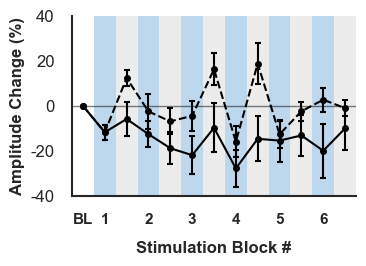

In [9]:


# --- עיבוד נתונים ---
data_list = for_avg_props_raw['relative_spike_amplitude']['all']
df_cum = get_clean_matrix(data_list, mode='baseline')   # Cumulative
df_imm = get_clean_matrix(data_list, mode='consecutive') # Immediate

mean_cum = df_cum.mean()
sem_cum = df_cum.sem()
mean_imm = df_imm.mean()
sem_imm = df_imm.sem()
n_counts = df_cum.count() 
print("Data points per block (after outlier removal):")
print(n_counts.tolist())
x_indices = np.arange(len(mean_cum))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(4, 3))

# 1. רקע צבעוני
for j in range(1, len(mean_cum)):
    color = '#91bde1' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.6, linewidth=0)

# 2. הגדרות סטייל זהות
err_style = {'fmt': '-o', 'color': 'black', 'capsize': 2, 'markersize': 4, 
             'linewidth': 1.5, 'elinewidth': 1.5, 'capthick': 1.5}

# ציור הקווים
ax.errorbar(x_indices, mean_cum, yerr=sem_cum, zorder=5, 
            label='Cumulative Effect (vs. BL)', **err_style)

ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--', 
            label='Immediate Effect (Block-to-Block)', **err_style)

# 3. קו אפס
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)

# 4. עיצוב צירים ו-Ticks (העדכון שביקשת)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# הגדרת שנתות ציר Y כל 10%
y_ticks = np.arange(-40, 50, 20) # מ-40- עד 40 (כולל) בקפיצות של 10
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks, fontsize=12) # הקטנת פונט מספרים בציר Y
ax.set_ylim(-40, 40)

# תוויות ציר X
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_cum), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_cum), 2)])
ax.set_xticklabels(stim_labels, fontsize=11, fontweight='bold')

ax.set_xlabel('Stimulation Block #', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Amplitude Change (%)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, len(mean_cum) - 0.5)
ax.grid(False)

# 5. מקרא (אופציונלי להחזיר אם תרצה)
stim_patch = mpatches.Patch(color='#8db4d3', label='Stimulation Block')
pause_patch = mpatches.Patch(color='#e0e0e0', label='Pause Block')

plt.tight_layout()
plt.show()

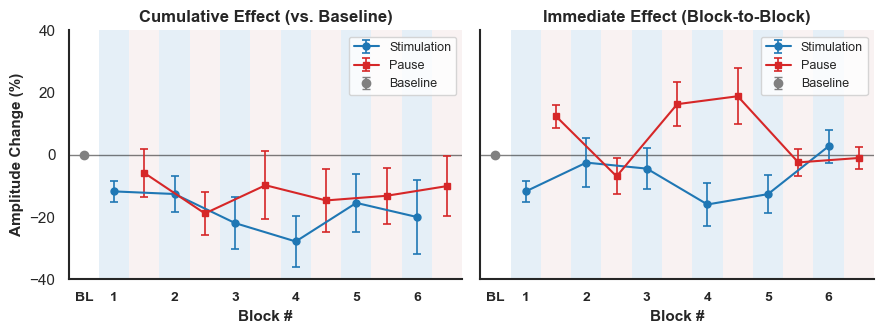

In [76]:
# --- עיבוד נתונים ---
data_list = for_avg_props_raw['relative_spike_amplitude']['all']
df_cum = get_clean_matrix(data_list, mode='baseline')
df_imm = get_clean_matrix(data_list, mode='consecutive')

mean_cum = df_cum.mean()
sem_cum = df_cum.sem()
mean_imm = df_imm.mean()
sem_imm = df_imm.sem()
x_indices = np.arange(len(mean_cum))

# --- הפרדה לאינדקסים של גירוי והפסקה ---
# נניח: אינדקס 0 = BL, אינדקסים אי-זוגיים = גירוי, זוגיים (מלבד 0) = הפסקה
stim_indices = np.array([i for i in range(1, len(mean_cum)) if i % 2 != 0])
pause_indices = np.array([i for i in range(2, len(mean_cum)) if i % 2 == 0])

# --- יצירת שני גרפים ---
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)

# סגנונות
stim_style = {'fmt': '-o', 'color': '#1f77b4', 'capsize': 3, 'markersize': 5,
              'linewidth': 1.5, 'elinewidth': 1.2, 'capthick': 1.2}
pause_style = {'fmt': '-s', 'color': '#d62728', 'capsize': 3, 'markersize': 5,
               'linewidth': 1.5, 'elinewidth': 1.2, 'capthick': 1.2}

titles = ['Cumulative Effect (vs. Baseline)', 'Immediate Effect (Block-to-Block)']
means = [mean_cum, mean_imm]
sems = [sem_cum, sem_imm]

for idx, ax in enumerate(axes):
    mean_data = means[idx]
    sem_data = sems[idx]
    
    # רקע צבעוני
    for j in range(1, len(mean_data)):
        color = '#cce0f0' if j % 2 != 0 else '#f5e6e6'
        ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.5, linewidth=0)
    
    # קו גירוי
    ax.errorbar(stim_indices, mean_data.iloc[stim_indices], 
                yerr=sem_data.iloc[stim_indices], label='Stimulation', 
                zorder=5, **stim_style)
    
    # קו הפסקה
    ax.errorbar(pause_indices, mean_data.iloc[pause_indices], 
                yerr=sem_data.iloc[pause_indices], label='Pause', 
                zorder=5, **pause_style)
    
    # נקודת בייסליין (אם רוצים להוסיף)
    ax.errorbar([0], [mean_data.iloc[0]], yerr=[sem_data.iloc[0]], 
                fmt='o', color='gray', markersize=6, capsize=3, 
                label='Baseline', zorder=6)
    
    # קו אפס
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)
    
    # עיצוב
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    ax.set_yticks(np.arange(-40, 50, 20))
    ax.set_ylim(-40, 40)
    
    # תוויות ציר X - מספרי בלוקים
    stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_data), 2)]
    ax.set_xticks([0] + list(range(1, len(mean_data), 2)))
    ax.set_xticklabels(stim_labels, fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Block #', fontsize=11, fontweight='bold')
    ax.set_xlim(-0.5, len(mean_data) - 0.5)
    ax.set_title(titles[idx], fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)

axes[0].set_ylabel('Amplitude Change (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


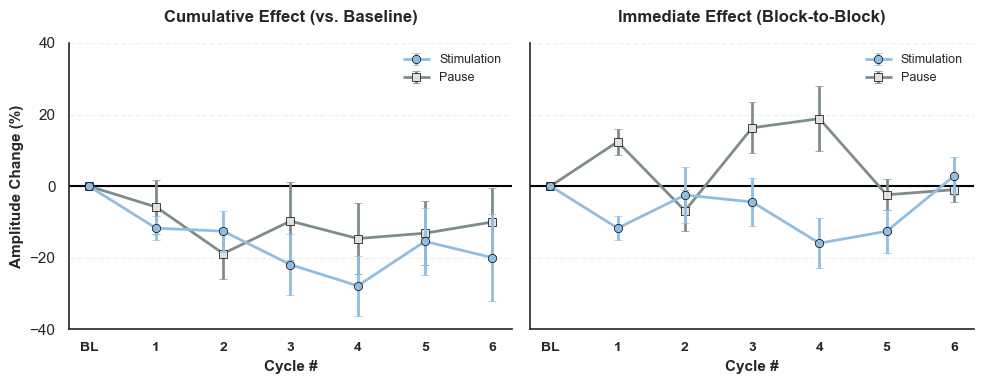

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# --- עיבוד נתונים ---
# (בהנחה ש-mean_cum, mean_imm וכו' כבר קיימים מהשלב הקודם)

# הגדרת אינדקסים (S1=1, P1=2, S2=3, P2=4...)
stim_idx = [i for i in range(1, len(mean_cum)) if i % 2 != 0]
pause_idx = [i for i in range(2, len(mean_cum)) if i % 2 == 0]

# ציר X המשותף (0 ל-Baseline, ואז 1, 2, 3...)
x_axis = np.arange(len(stim_idx) + 1) 

# --- פונקציית עזר לבניית מערך שמתחיל ב-0 ---
def prepare_line(mean_series, sem_series, indices):
    y = [0] + mean_series.iloc[indices].tolist()
    err = [0] + sem_series.iloc[indices].tolist()
    return y, err

# --- יצירת הפיגורה ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# הגדרות צבעים וסטייל (כחול לגירוי, אפור להפסקה)
stim_color = '#91bde1'  # הכחול מהרקע המקורי
pause_color = '#e0e0e0' # האפור מהרקע המקורי

stim_style = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
pause_style = {'fmt': '-s', 'color': '#7f8c8d', 'ecolor': '#7f8c8d', 'capsize': 3, 
               'markersize': 6, 'linewidth': 2, 'markerfacecolor': pause_color, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

titles = ['Cumulative Effect (vs. Baseline)', 'Immediate Effect (Block-to-Block)']
datasets = [(mean_cum, sem_cum), (mean_imm, sem_imm)]

for i, ax in enumerate(axes):
    m_data, s_data = datasets[i]
    
    # הכנת נתוני הקווים (חיבור נקודת ה-0)
    y_stim, err_stim = prepare_line(m_data, s_data, stim_idx)
    y_pause, err_pause = prepare_line(m_data, s_data, pause_idx)
    
    # ציור קו גירוי
    ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation', zorder=5, **stim_style)
    
    # ציור קו הפסקה (מוודאים שאם יש פחות הפסקה מגירוי, המערכים יתאימו)
    ax.errorbar(x_axis[:len(y_pause)], y_pause, yerr=err_pause, label='Pause', zorder=4, **pause_style)
    
    # קו אפס שחור ובולט
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)
    
    # עיצוב צירים
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # הגדרות Y
    ax.set_yticks(np.arange(-40, 50, 20))
    ax.set_ylim(-40, 40)
    
    # הגדרות X
    ax.set_xticks(x_axis)
    ax.set_xticklabels(['BL'] + [f'{j}' for j in x_axis[1:]], fontsize=10, fontweight='bold')
    ax.set_xlabel('Cycle #', fontsize=11, fontweight='bold')
    
    ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=15)
    ax.legend(frameon=False, fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Amplitude Change (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
# --- עיבוד נתונים ---
data_list = for_avg_props_raw['relative_spike_amplitude']['all']
df_cum = get_clean_matrix(data_list, mode='baseline')   
df_imm = get_clean_matrix(data_list, mode='consecutive') 

# --- בחירת נבדק ספציפי ---
subject_index = 11  # שנה את המספר הזה כדי לבחור נבדק אחר (0 הוא הראשון)

# במקום mean ו-sem, אנחנו לוקחים שורה אחת בלבד
mean_cum = df_cum.iloc[subject_index]
mean_imm = df_imm.iloc[subject_index]

# מאחר ומדובר בנבדק אחד, אין "טעות תקן" (Error bars)
sem_cum = None
sem_imm = None

# בדיקה איזה נבדק אנחנו מציגים
print(f"Plotting data for subject index: {subject_index}")

x_indices = np.arange(len(mean_cum))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(4, 3))

# 1. רקע צבעוני (נשאר זהה)
for j in range(1, len(mean_cum)):
    color = '#91bde1' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.6, linewidth=0)

# 2. הגדרות סטייל (נשאר זהה)
err_style = {'fmt': '-o', 'color': 'black', 'capsize': 2, 'markersize': 4, 
             'linewidth': 1.5, 'elinewidth': 1.5, 'capthick': 1.5}

# ציור הקווים (yerr=None יבטל אוטומטית את קווי השגיאה)
ax.errorbar(x_indices, mean_cum, yerr=sem_cum, zorder=5, 
            label=f'Subj {subject_index}: Cumulative', **err_style)

ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--', 
            label=f'Subj {subject_index}: Immediate', **err_style)

# 3. קו אפס ועיצוב צירים (נשאר זהה)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# הגדרות Ticks
y_ticks = np.arange(-40, 65, 20) 
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks, fontsize=12) 
ax.set_ylim(-45, 70)

stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_cum), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_cum), 2)])
ax.set_xticklabels(stim_labels, fontsize=11, fontweight='bold')

ax.set_xlabel('Stimulation Block #', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Amplitude Change (%)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, len(mean_cum) - 0.5)

plt.tight_layout()
plt.show()

IndexError: single positional indexer is out-of-bounds

Data points per block (after outlier removal):
[10, 10, 10, 10, 10, 10, 9, 10, 10, 7, 7, 5, 4]


C:\Users\user\AppData\Local\Temp\ipykernel_10460\2432295872.py:63: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--',


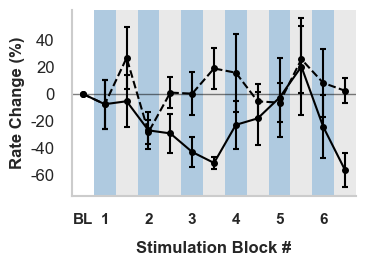

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches

def get_clean_matrix(raw_data_list, mode='baseline', max_points=13, threshold=3):
    all_rows = []
    for subj_rates in raw_data_list:
        subj_rates = np.array(subj_rates)[:max_points]
        if len(subj_rates) < 2: continue
        
        if mode == 'baseline':
            b = subj_rates[0]
            if b == 0: continue
            vals = ((subj_rates - b) / b) * 100
        else: # consecutive
            prev = subj_rates[:-1]
            denom = np.where(prev == 0, 1e-9, prev)
            vals = np.insert(((subj_rates[1:] - prev) / denom) * 100, 0, 0)
        
        padded = np.full(max_points, np.nan)
        padded[:len(vals)] = vals
        all_rows.append(padded)
    
    df_wide = pd.DataFrame(all_rows)
    for col in df_wide.columns[1:]:
        q1, q3 = df_wide[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df_wide.loc[(df_wide[col] < q1 - threshold*iqr) | (df_wide[col] > q3 + threshold*iqr), col] = np.nan
    return df_wide

# --- עיבוד נתונים ---
data_list = for_avg_props_raw['rates']['all']
df_cum = get_clean_matrix(data_list, mode='baseline')   # Cumulative
df_imm = get_clean_matrix(data_list, mode='consecutive') # Immediate

mean_cum = df_cum.mean()
sem_cum = df_cum.sem()
mean_imm = df_imm.mean()
sem_imm = df_imm.sem()
n_counts = df_cum.count() 
print("Data points per block (after outlier removal):")
print(n_counts.tolist())
x_indices = np.arange(len(mean_cum))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(4, 3))

# 1. רקע צבעוני
for j in range(1, len(mean_cum)):
    color = '#8db4d3' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.7, linewidth=0)

# 2. הגדרות סטייל זהות
err_style = {'fmt': '-o', 'color': 'black', 'capsize': 2, 'markersize': 4, 
             'linewidth': 1.5, 'elinewidth': 1.5, 'capthick': 1.5}

# ציור הקווים
ax.errorbar(x_indices, mean_cum, yerr=sem_cum, zorder=5, 
            label='Cumulative Effect (vs. BL)', **err_style)

ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--', 
            label='Immediate Effect (Block-to-Block)', **err_style)

# 3. קו אפס
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)

# 4. עיצוב צירים ו-Ticks (העדכון שביקשת)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# הגדרת שנתות ציר Y כל 10%
y_ticks = np.arange(-60, 50, 20) # מ-40- עד 40 (כולל) בקפיצות של 10
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks, fontsize=12) # הקטנת פונט מספרים בציר Y
# ax.set_ylim(-45, 40)

# תוויות ציר X
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_cum), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_cum), 2)])
ax.set_xticklabels(stim_labels, fontsize=11, fontweight='bold')

ax.set_xlabel('Stimulation Block #', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Rate Change (%)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, len(mean_cum) - 0.5)
ax.grid(False)

# 5. מקרא (אופציונלי להחזיר אם תרצה)
stim_patch = mpatches.Patch(color='#8db4d3', label='Stimulation Block')
pause_patch = mpatches.Patch(color='#e0e0e0', label='Pause Block')

plt.tight_layout()
plt.show()

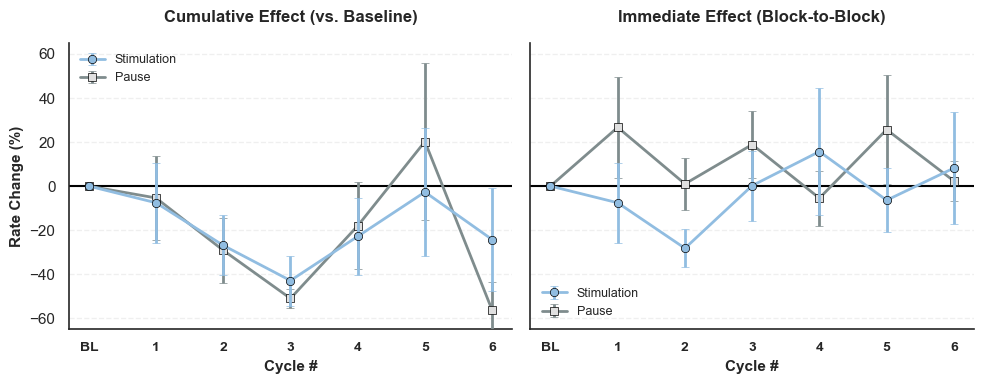

In [78]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד הנתונים עבור קצב הירי (Rates) ---
data_list_rates = for_avg_props_raw['rates']['all']
df_cum_rates = get_clean_matrix(data_list_rates, mode='baseline')
df_imm_rates = get_clean_matrix(data_list_rates, mode='consecutive')

mean_cum_r = df_cum_rates.mean()
sem_cum_r = df_cum_rates.sem()
mean_imm_r = df_imm_rates.mean()
sem_imm_r = df_imm_rates.sem()

# הגדרת אינדקסים (S1=1, P1=2, S2=3, P2=4...)
stim_idx = [i for i in range(1, len(mean_cum_r)) if i % 2 != 0]
pause_idx = [i for i in range(2, len(mean_cum_r)) if i % 2 == 0]

# ציר X המשותף (0 ל-Baseline, ואז 1, 2, 3...)
x_axis = np.arange(len(stim_idx) + 1) 

# פונקציית עזר לבניית מערך שמתחיל ב-0
def prepare_line(mean_series, sem_series, indices):
    y = [0] + mean_series.iloc[indices].tolist()
    err = [0] + sem_series.iloc[indices].tolist()
    return y, err

# --- 2. יצירת הפיגורה ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# הגדרות צבעים וסטייל (כחול לגירוי, אפור להפסקה)
stim_color = '#91bde1'  # הכחול מהרקע המקורי
pause_color = '#e0e0e0' # האפור מהרקע המקורי

stim_style = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
pause_style = {'fmt': '-s', 'color': '#7f8c8d', 'ecolor': '#7f8c8d', 'capsize': 3, 
               'markersize': 6, 'linewidth': 2, 'markerfacecolor': pause_color, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

titles = ['Cumulative Effect (vs. Baseline)', 'Immediate Effect (Block-to-Block)']
datasets = [(mean_cum_r, sem_cum_r), (mean_imm_r, sem_imm_r)]

for i, ax in enumerate(axes):
    m_data, s_data = datasets[i]
    
    # הכנת נתוני הקווים (חיבור נקודת ה-0)
    y_stim, err_stim = prepare_line(m_data, s_data, stim_idx)
    y_pause, err_pause = prepare_line(m_data, s_data, pause_idx)
    
    # ציור קו גירוי
    ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation', zorder=5, **stim_style)
    
    # ציור קו הפסקה
    ax.errorbar(x_axis[:len(y_pause)], y_pause, yerr=err_pause, label='Pause', zorder=4, **pause_style)
    
    # קו אפס שחור ובולט
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)
    
    # עיצוב צירים
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # הגדרות Y (ניתן להתאים את הטווח אם קצב הירי משתנה יותר/פחות מאמפליטודה)
    ax.set_yticks(np.arange(-60, 80, 20))
    ax.set_ylim(-65, 65)
    
    # הגדרות X
    ax.set_xticks(x_axis)
    ax.set_xticklabels(['BL'] + [f'{j}' for j in x_axis[1:]], fontsize=10, fontweight='bold')
    ax.set_xlabel('Cycle #', fontsize=11, fontweight='bold')
    
    ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=15)
    ax.legend(frameon=False, fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Rate Change (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Change in Amplitude Between Consecutive Time Windows (%)
Inter-Window Amplitude Change (%)
Relative Amplitude Change (% from Previous Block)
Amplitude Modulation (% Change)
Amplitude Change Following State Transition (%)
Consecutive Block-to-Block Change (%)

Processing Subj 497...
Processing Subj 498...
Data is ready for plotting!


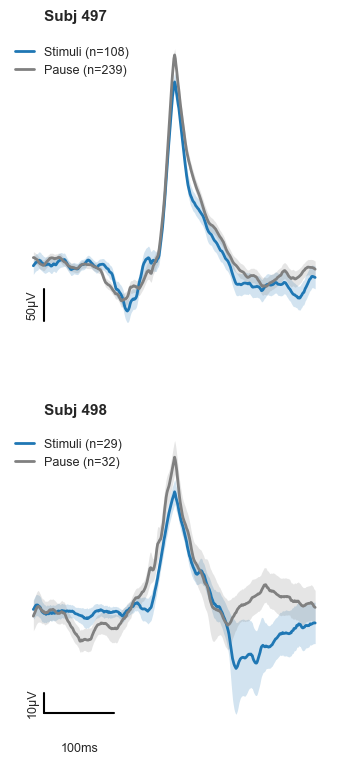

In [133]:
import os
import numpy as np
import pandas as pd
import mne
import utils

# הגדרות בסיס
base_path = r"D:\Ofer_backup\V6_model"
PRE_MS, POST_MS = 200, 200
cases = [
    {"subj": "497", "chan": "LEC1"},
    {"subj": "498", "chan": "RA1"}
]

all_results = {} # כאן יישמרו כל הנתונים המוכנים

for case in cases:
    subj_id, ch_name = case["subj"], case["chan"]
    print(f"Processing Subj {subj_id}...")
    
    # טעינת נתיבים
    edf_path = rf"D:\Maya\p{subj_id}\P{subj_id}_fixed.edf"
    features_csv = os.path.join(base_path, f"p{subj_id}", "unichannel_model", "min_amplitude_1", "features", f"p{subj_id}_flat_features.csv")
    clean_annot_path = rf"D:\Maya\clean Stim Project\P{subj_id}\P{subj_id}_annotations_ms.csv"

    # עיבוד DataFrame
    df = pd.read_csv(features_csv)
    # df = df[df["hypnogram_flag"] == "nrem"].copy()
    df = df.drop_duplicates(subset=["group"], keep="first")
    df = utils.remove_noisy_samples_and_channels(subj_id, df, clean_annot_path, ts_col="timestamp", channel_col="channel")
    df_target = df[(df["channel"] == ch_name) & (df["stimuli_flag"].isin(["stimuli_block", "pause_block"]))]

    # קריאת EDF
    raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
    fs = raw.info["sfreq"]
    w_len = int((PRE_MS + POST_MS) * fs / 1000)
    
    waveforms = {"stimuli_block": [], "pause_block": []}
    for _, row in df_target.iterrows():
        t_start = (row["timestamp"] - PRE_MS) / 1000
        t_stop = (row["timestamp"] + POST_MS) / 1000
        try:
            wf = raw.get_data(picks=[ch_name], tmin=t_start, tmax=t_stop, return_times=False)
            wf = np.squeeze(wf) * 1e6 # המרה ל-uV
            if len(wf) >= w_len:
                wf_final = wf[:w_len] - np.mean(wf[:int(PRE_MS * fs / 1000)])
                waveforms[row["stimuli_flag"]].append(wf_final)
        except: continue
        
    all_results[f"{subj_id}_{ch_name}"] = {"data": waveforms, "fs": fs}

print("Data is ready for plotting!")
# פרמטרים לציור
SCALE_X = 100        
COLORS = {"stimuli_block": "#1f77b4", "pause_block": "#808080"}
LEGEND_LABELS = {"stimuli_block": "Stimuli", "pause_block": "Pause"}

scale_y_values = [50, 10] 

fig, axes = plt.subplots(2, 1, figsize=(4, 9)) # הגבהתי מעט את הפיגורה ל-9

for i, (key, content) in enumerate(all_results.items()):
    waveforms = content["data"]
    fs = content["fs"]
    ax = axes[i]
    t = np.linspace(-PRE_MS, POST_MS, int((PRE_MS + POST_MS) * fs / 1000))
    current_scale_y = scale_y_values[i]
    
    for cond in ["stimuli_block", "pause_block"]:
        wf_list = waveforms[cond]
        if len(wf_list) > 0:
            W = np.vstack(wf_list)
            mean = np.mean(W, axis=0)
            sem = np.std(W, axis=0) / np.sqrt(W.shape[0])
            
            label_with_n = f"{LEGEND_LABELS[cond]} (n={len(wf_list)})"
            ax.plot(t, mean, color=COLORS[cond], lw=2, label=label_with_n)
            ax.fill_between(t, mean - sem, mean + sem, color=COLORS[cond], alpha=0.2, lw=0)

    ax.set_axis_off()
    
    # כותרת נבדק - הוספתי pad ויזואלי על ידי העלאת ה-y position
    # ושימוש ב-va='bottom' כדי שיהיה רווח מהסיגנל
    y_max_curr = ax.get_ylim()[1]
    ax.text(-185, y_max_curr * 1.05, f"Subj {key.split('_')[0]}", 
            fontsize=11, fontweight='bold', va='bottom')

    # מקרא - הוספת bbox_to_anchor עם קצת יותר רווח מלמעלה
    ax.legend(loc='upper left', frameon=False, fontsize=9, 
              bbox_to_anchor=(-0.05, 1.0), handlelength=1.5)

    # Scale Bar
    y_min_local, y_max_local = ax.get_ylim()
    y_range = y_max_local - y_min_local
    x_start, y_start = -185, y_min_local + (y_range * 0.05)
    
    ax.plot([x_start, x_start], [y_start, y_start + current_scale_y], color='black', lw=1.5)
    ax.text(x_start - 8, y_start + current_scale_y/2, f'{current_scale_y}µV', 
            ha='right', va='center', rotation=90, fontsize=9)
    
    if i == 1:
        ax.plot([x_start, x_start + SCALE_X], [y_start, y_start], color='black', lw=1.5)
        ax.text(x_start + SCALE_X/2, y_start - (y_range * 0.1), 
                f'{SCALE_X}ms', ha='center', va='top', fontsize=9)

# הגדלת המרווח בין הגרפים כדי למנוע צפיפות בין הכותרת של התחתון ל-Scale Bar של העליון
plt.subplots_adjust(hspace=0.3)
plt.show()

In [83]:
import os
import numpy as np
import pandas as pd
import mne
import utils

# הגדרות בסיס
base_path = r"D:\Ofer_backup\V6_model"
PRE_MS, POST_MS = 200, 200
cases = [
    {"subj": "497", "chan": "LEC1"},
    {"subj": "497", "chan": "LA1"}
]

all_results = {} # כאן יישמרו כל הנתונים המוכנים

for case in cases:
    subj_id, ch_name = case["subj"], case["chan"]
    print(f"Processing Subj {subj_id}...")
    
    # טעינת נתיבים
    edf_path = rf"D:\Maya\p{subj_id}\P{subj_id}_fixed.edf"
    features_csv = os.path.join(base_path, f"p{subj_id}", "unichannel_model", "min_amplitude_1", "features", f"p{subj_id}_flat_features.csv")
    clean_annot_path = rf"D:\Maya\clean Stim Project\P{subj_id}\P{subj_id}_annotations_ms.csv"

    # עיבוד DataFrame
    df = pd.read_csv(features_csv)
    # df = df[df["hypnogram_flag"] == "nrem"].copy()
    df = df.drop_duplicates(subset=["group"], keep="first")
    df = utils.remove_noisy_samples_and_channels(subj_id, df, clean_annot_path, ts_col="timestamp", channel_col="channel")
    df_target = df[(df["channel"] == ch_name) & (df["stimuli_flag"].isin(["stimuli_block", "pause_block"]))]

    # קריאת EDF
    raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
    fs = raw.info["sfreq"]
    w_len = int((PRE_MS + POST_MS) * fs / 1000)
    
    waveforms = {"stimuli_block": [], "pause_block": []}
    for _, row in df_target.iterrows():
        t_start = (row["timestamp"] - PRE_MS) / 1000
        t_stop = (row["timestamp"] + POST_MS) / 1000
        try:
            wf = raw.get_data(picks=[ch_name], tmin=t_start, tmax=t_stop, return_times=False)
            wf = np.squeeze(wf) * 1e6 # המרה ל-uV
            if len(wf) >= w_len:
                wf_final = wf[:w_len] - np.mean(wf[:int(PRE_MS * fs / 1000)])
                waveforms[row["stimuli_flag"]].append(wf_final)
        except: continue
        
    all_results[f"{subj_id}_{ch_name}"] = {"data": waveforms, "fs": fs}

print("Data is ready for plotting!")

Processing Subj 497...
Processing Subj 497...
Data is ready for plotting!


Case 497_LEC1: Stim Peak=281.90uV, Pause Peak=331.07uV. Difference: 14.9%
Case 497_LA1: Stim Peak=237.73uV, Pause Peak=268.19uV. Difference: 11.4%


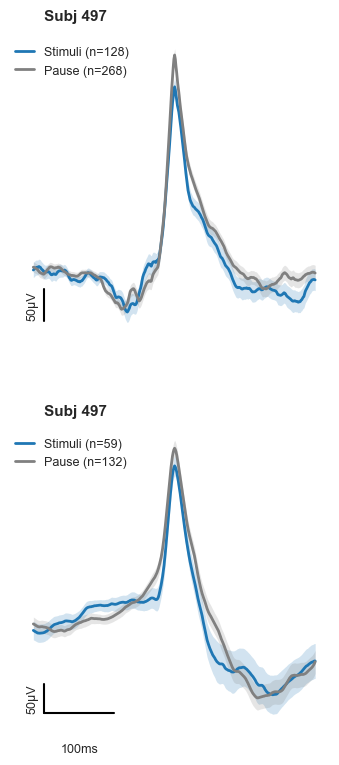

In [87]:
# פרמטרים לציור
SCALE_X = 100        
COLORS = {"stimuli_block": "#1f77b4", "pause_block": "#808080"}
LEGEND_LABELS = {"stimuli_block": "Stimuli", "pause_block": "Pause"}

scale_y_values = [50, 50] 

fig, axes = plt.subplots(2, 1, figsize=(4, 9)) # הגבהתי מעט את הפיגורה ל-9

for i, (key, content) in enumerate(all_results.items()):
    waveforms = content["data"]
    fs = content["fs"]
    ax = axes[i]
    t = np.linspace(-PRE_MS, POST_MS, int((PRE_MS + POST_MS) * fs / 1000))
    current_scale_y = scale_y_values[i]
    
    max_peaks = {} # לאחסון שיאי הגובה
    
    for cond in ["stimuli_block", "pause_block"]:
        wf_list = waveforms[cond]
        if len(wf_list) > 0:
            W = np.vstack(wf_list)
            mean = np.mean(W, axis=0)
            sem = np.std(W, axis=0) / np.sqrt(W.shape[0])
            
            # שמירת שיא הגובה (אבסולוטי) של הממוצע
            max_peaks[cond] = np.max(np.abs(mean))
            
            label_with_n = f"{LEGEND_LABELS[cond]} (n={len(wf_list)})"
            ax.plot(t, mean, color=COLORS[cond], lw=2, label=label_with_n)
            ax.fill_between(t, mean - sem, mean + sem, color=COLORS[cond], alpha=0.2, lw=0)

    # --- חישוב הפרש בשיא הגובה (Peak Amplitude) ---
    if "stimuli_block" in max_peaks and "pause_block" in max_peaks:
        p1, p2 = max_peaks["stimuli_block"], max_peaks["pause_block"]
        pct_diff = abs(p1 - p2) / p2 * 100
        print(f"Case {key}: Stim Peak={p1:.2f}uV, Pause Peak={p2:.2f}uV. Difference: {pct_diff:.1f}%")

    ax.set_axis_off()
    
    # כותרת נבדק - הוספתי pad ויזואלי על ידי העלאת ה-y position
    # ושימוש ב-va='bottom' כדי שיהיה רווח מהסיגנל
    y_max_curr = ax.get_ylim()[1]
    ax.text(-185, y_max_curr * 1.05, f"Subj {key.split('_')[0]}", 
            fontsize=11, fontweight='bold', va='bottom')

    # מקרא - הוספת bbox_to_anchor עם קצת יותר רווח מלמעלה
    ax.legend(loc='upper left', frameon=False, fontsize=9, 
              bbox_to_anchor=(-0.05, 1.0), handlelength=1.5)

    # Scale Bar
    y_min_local, y_max_local = ax.get_ylim()
    y_range = y_max_local - y_min_local
    x_start, y_start = -185, y_min_local + (y_range * 0.05)
    
    ax.plot([x_start, x_start], [y_start, y_start + current_scale_y], color='black', lw=1.5)
    ax.text(x_start - 8, y_start + current_scale_y/2, f'{current_scale_y}µV', 
            ha='right', va='center', rotation=90, fontsize=9)
    
    if i == 1:
        ax.plot([x_start, x_start + SCALE_X], [y_start, y_start], color='black', lw=1.5)
        ax.text(x_start + SCALE_X/2, y_start - (y_range * 0.1), 
                f'{SCALE_X}ms', ha='center', va='top', fontsize=9)

# הגדלת המרווח בין הגרפים כדי למנוע צפיפות בין הכותרת של התחתון ל-Scale Bar של העליון
plt.subplots_adjust(hspace=0.3)
plt.show()

# Rates

In [21]:
import joblib
data_stim = joblib.load(r"C:\repos\spikes_stim\paper\for_avg_props_raw_stim.pkl")
data_control = joblib.load(r"C:\repos\spikes_stim\paper\for_avg_props_raw_controls_10.pkl")

In [6]:
# 1. הרשימה המלאה המקורית (15 נבדקים)
subjects_orig = ['485', '486', '487', '488', '489', '496', '497', '498', '499', '505', '5107', '515', '520', '538', '545']

# 2. הנבדקים שבאמת קיימים בנתונים (13 נבדקים - הורדנו את 545 ו-515)
subjects_in_data = [s for s in subjects_orig if s not in ['515', '545']]

# 3. הרשימה הסופית שאתה רוצה להשאיר (לפי הבקשה הקודמת שלך)
subjects_final = ['485', '486', '487', '488', '497', '498', '499', '505', '5107', '515', '520', '545']
# הערה: מכיוון ש-515 ו-545 לא קיימים בנתונים, הם יוסרו אוטומטית בתהליך הבא.

# 4. ביצוע הסינון
keep_set = set(subjects_final)

for feature in data_stim:
    for location in data_stim[feature]:
        current_list = data_stim[feature][location]
        new_list = []
        
        # רצים על הרשימה הקיימת (באורך 13) ומצמידים לה את השמות מ-subjects_in_data
        for i in range(len(current_list)):
            subj_name = subjects_in_data[i]
            if subj_name in keep_set:
                new_list.append(current_list[i])
        
        # עדכון המבנה
        data_stim[feature][location] = new_list

print(f"Done! New length of lists: {len(data_stim['rates']['all'])}")

Done! New length of lists: 10


Data points per block (after outlier removal):
[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 10]


C:\Users\user\AppData\Local\Temp\ipykernel_44912\2330815547.py:63: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--',


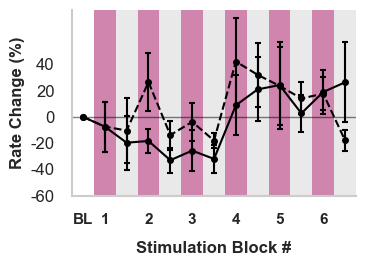

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches

def get_clean_matrix(raw_data_list, mode='baseline', max_points=13, threshold=3):
    all_rows = []
    for subj_rates in raw_data_list:
        subj_rates = np.array(subj_rates)[:max_points]
        if len(subj_rates) < 2: continue
        
        if mode == 'baseline':
            b = subj_rates[0]
            if b == 0: continue
            vals = ((subj_rates - b) / b) * 100
        else: # consecutive
            prev = subj_rates[:-1]
            denom = np.where(prev == 0, 1e-9, prev)
            vals = np.insert(((subj_rates[1:] - prev) / denom) * 100, 0, 0)
        
        padded = np.full(max_points, np.nan)
        padded[:len(vals)] = vals
        all_rows.append(padded)
    
    df_wide = pd.DataFrame(all_rows)
    for col in df_wide.columns[1:]:
        q1, q3 = df_wide[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df_wide.loc[(df_wide[col] < q1 - threshold*iqr) | (df_wide[col] > q3 + threshold*iqr), col] = np.nan
    return df_wide

# --- עיבוד נתונים ---
data_list = data_control['rates']['all']  # רשימת רשימות של כל הנבדקים
df_cum = get_clean_matrix(data_list, mode='baseline')   # Cumulative
df_imm = get_clean_matrix(data_list, mode='consecutive') # Immediate

mean_cum = df_cum.mean()
sem_cum = df_cum.sem()
mean_imm = df_imm.mean()
sem_imm = df_imm.sem()
n_counts = df_cum.count() 
print("Data points per block (after outlier removal):")
print(n_counts.tolist())
x_indices = np.arange(len(mean_cum))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(4, 3))

# 1. רקע צבעוני
for j in range(1, len(mean_cum)):
    color = '#bb528c' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.7, linewidth=0)

# 2. הגדרות סטייל זהות
err_style = {'fmt': '-o', 'color': 'black', 'capsize': 2, 'markersize': 4, 
             'linewidth': 1.5, 'elinewidth': 1.5, 'capthick': 1.5}

# ציור הקווים
ax.errorbar(x_indices, mean_cum, yerr=sem_cum, zorder=5, 
            label='Cumulative Effect (vs. BL)', **err_style)

ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--', 
            label='Immediate Effect (Block-to-Block)', **err_style)

# 3. קו אפס
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)

# 4. עיצוב צירים ו-Ticks (העדכון שביקשת)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# הגדרת שנתות ציר Y כל 10%
y_ticks = np.arange(-60, 50, 20) # מ-40- עד 40 (כולל) בקפיצות של 10
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks, fontsize=12) # הקטנת פונט מספרים בציר Y
# ax.set_ylim(-45, 40)

# תוויות ציר X
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_cum), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_cum), 2)])
ax.set_xticklabels(stim_labels, fontsize=11, fontweight='bold')

ax.set_xlabel('Stimulation Block #', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Rate Change (%)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, len(mean_cum) - 0.5)
ax.grid(False)

# 5. מקרא (אופציונלי להחזיר אם תרצה)
stim_patch = mpatches.Patch(color='#8db4d3', label='Stimulation Block')
pause_patch = mpatches.Patch(color='#e0e0e0', label='Pause Block')

plt.tight_layout()
plt.show()

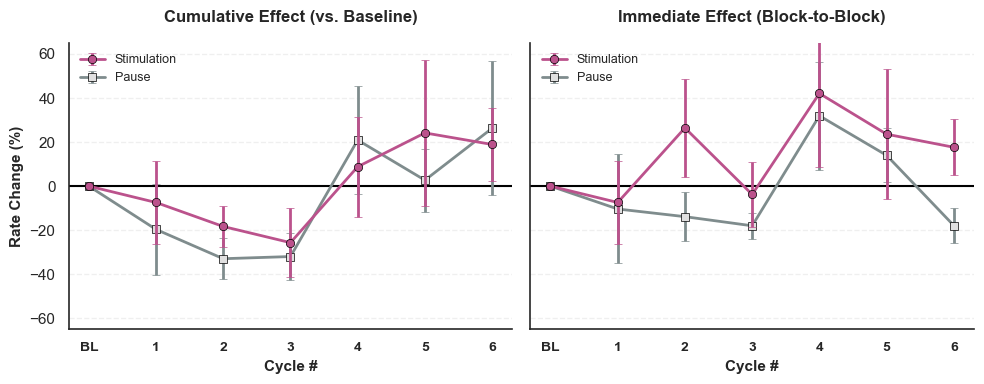

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד הנתונים עבור קצב הירי (Rates) ---
data_list_rates = data_control['rates']['all']
df_cum_rates = get_clean_matrix(data_list_rates, mode='baseline')
df_imm_rates = get_clean_matrix(data_list_rates, mode='consecutive')

mean_cum_r = df_cum_rates.mean()
sem_cum_r = df_cum_rates.sem()
mean_imm_r = df_imm_rates.mean()
sem_imm_r = df_imm_rates.sem()

# הגדרת אינדקסים (S1=1, P1=2, S2=3, P2=4...)
stim_idx = [i for i in range(1, len(mean_cum_r)) if i % 2 != 0]
pause_idx = [i for i in range(2, len(mean_cum_r)) if i % 2 == 0]

# ציר X המשותף (0 ל-Baseline, ואז 1, 2, 3...)
x_axis = np.arange(len(stim_idx) + 1) 

# פונקציית עזר לבניית מערך שמתחיל ב-0
def prepare_line(mean_series, sem_series, indices):
    y = [0] + mean_series.iloc[indices].tolist()
    err = [0] + sem_series.iloc[indices].tolist()
    return y, err

# --- 2. יצירת הפיגורה ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# הגדרות צבעים וסטייל (כחול לגירוי, אפור להפסקה)
stim_color = '#bb528c'  # הכחול מהרקע המקורי
pause_color = '#e0e0e0' # האפור מהרקע המקורי

stim_style = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
pause_style = {'fmt': '-s', 'color': '#7f8c8d', 'ecolor': '#7f8c8d', 'capsize': 3, 
               'markersize': 6, 'linewidth': 2, 'markerfacecolor': pause_color, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

titles = ['Cumulative Effect (vs. Baseline)', 'Immediate Effect (Block-to-Block)']
datasets = [(mean_cum_r, sem_cum_r), (mean_imm_r, sem_imm_r)]

for i, ax in enumerate(axes):
    m_data, s_data = datasets[i]
    
    # הכנת נתוני הקווים (חיבור נקודת ה-0)
    y_stim, err_stim = prepare_line(m_data, s_data, stim_idx)
    y_pause, err_pause = prepare_line(m_data, s_data, pause_idx)
    
    # ציור קו גירוי
    ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation', zorder=5, **stim_style)
    
    # ציור קו הפסקה
    ax.errorbar(x_axis[:len(y_pause)], y_pause, yerr=err_pause, label='Pause', zorder=4, **pause_style)
    
    # קו אפס שחור ובולט
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)
    
    # עיצוב צירים
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # הגדרות Y (ניתן להתאים את הטווח אם קצב הירי משתנה יותר/פחות מאמפליטודה)
    ax.set_yticks(np.arange(-60, 80, 20))
    ax.set_ylim(-65, 65)
    
    # הגדרות X
    ax.set_xticks(x_axis)
    ax.set_xticklabels(['BL'] + [f'{j}' for j in x_axis[1:]], fontsize=10, fontweight='bold')
    ax.set_xlabel('Cycle #', fontsize=11, fontweight='bold')
    
    ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=15)
    ax.legend(frameon=False, fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Rate Change (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

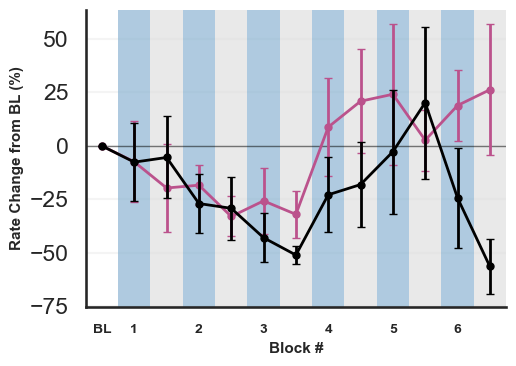

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- עיבוד נתונים (בהנחה שהפונקציה get_clean_matrix הוגדרה קודם) ---
df_stim = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
df_control = get_clean_matrix(data_control['rates']['all'], mode='baseline')

mean_stim = df_stim.mean()
sem_stim = df_stim.sem()
mean_ctrl = df_control.mean()
sem_ctrl = df_control.sem()

x_indices = np.arange(len(mean_stim))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(5.5, 4)) # הגדלתי מעט את הרוחב למקרא

# 1. רקע צבעוני לבלוקים
for j in range(1, len(mean_stim)):
    color = '#8db4d3' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.7, linewidth=0)

# 2. ציור הקווים
# קבוצת הניסוי - כחול עמוק
ax.errorbar(x_indices, mean_stim, yerr=sem_stim, fmt='-o', color='black', 
            capsize=3, markersize=5, linewidth=2, label='Stimulation Group', zorder=5)

# קבוצת הביקורת - ורוד ce84ad
ax.errorbar(x_indices, mean_ctrl, yerr=sem_ctrl, fmt='-o', color='#bb528c', 
            capsize=3, markersize=5, linewidth=2, label='Control Group', zorder=4)

# 3. עיצוב ציר Y
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)
# הגדרה הגיונית לציר Y בהתאם לדאטה (מ-80- עד 60+)
# ax.set_ylim(-60, 40)
# y_ticks = np.arange(-60, 41, 20)
# ax.set_yticks(y_ticks)
# ax.set_yticklabels(y_ticks, fontsize=10)
ax.set_ylabel('Rate Change from BL (%)', fontsize=11, fontweight='bold')

# 4. עיצוב ציר X
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_stim), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_stim), 2)])
ax.set_xticklabels(stim_labels, fontsize=10, fontweight='bold')
ax.set_xlabel('Block #', fontsize=11, fontweight='bold')
ax.set_xlim(-0.5, len(mean_stim) - 0.5)

# 5. ניקוי מסגרת
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)

# 6. מקרא - שמאל למעלה
# ax.legend(frameon=True, fontsize=9, loc='upper left', facecolor='white', framealpha=0.8)
plt.tight_layout()
plt.show()

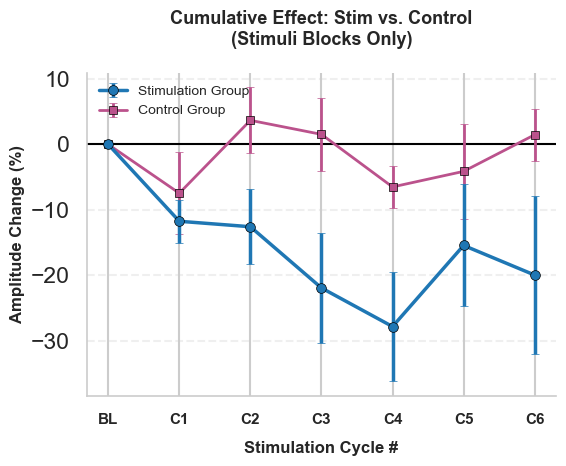

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד נתונים עבור קבוצת הגירוי ---
df_cum_stim = get_clean_matrix(data_stim['relative_spike_amplitude']['all'], mode='baseline')
mean_stim = df_cum_stim.mean()
sem_stim = df_cum_stim.sem()

# --- 2. עיבוד נתונים עבור קבוצת הקונטרול ---
df_cum_ctrl = get_clean_matrix(data_control['relative_spike_amplitude']['all'], mode='baseline')
mean_ctrl = df_cum_ctrl.mean()
sem_ctrl = df_cum_ctrl.sem()

# --- 3. שליפת זמני הגירוי בלבד (אינדקסים 1, 3, 5, 7) ---
stim_idx = [1, 3, 5, 7, 9, 11] # אינדקסים של בלוקי הגירוי בתוך המטריצה

# פונקציה להכנת הקו (הוספת 0 של ה-BL בהתחלה)
def prepare_group_line(mean_s, sem_s, idx_list):
    y = [0] + mean_s.iloc[idx_list].tolist()
    err = [0] + sem_s.iloc[idx_list].tolist()
    return y, err

y_stim, err_stim = prepare_group_line(mean_stim, sem_stim, stim_idx)
y_ctrl, err_ctrl = prepare_group_line(mean_ctrl, sem_ctrl, stim_idx)

# ציר X (BL ואז מחזורים 1 עד 4)
x_axis = np.arange(len(y_stim))

# --- 4. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(6, 5))

# הגדרות סטייל
stim_color = '#1f77b4' # כחול חזק לקבוצת הגירוי
ctrl_color = '#bb528c' # אפור לקבוצת הביקורת

style_stim = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 7, 'linewidth': 2.5, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
style_ctrl = {'fmt': '-s', 'color': ctrl_color, 'ecolor': ctrl_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markerfacecolor': '#bb528c', 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

# ציור הקווים
ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation Group', zorder=5, **style_stim)
ax.errorbar(x_axis, y_ctrl, yerr=err_ctrl, label='Control Group', zorder=4, **style_ctrl)

# קו אפס שחור
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)

# עיצוב צירים
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# הגדרות Y
ax.set_ylabel('Amplitude Change (%)', fontsize=12, fontweight='bold')

# הגדרות X
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6'], fontsize=11, fontweight='bold')
ax.set_xlabel('Stimulation Cycle #', fontsize=12, fontweight='bold', labelpad=10)

ax.set_title('Cumulative Effect: Stim vs. Control\n(Stimuli Blocks Only)', fontsize=13, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

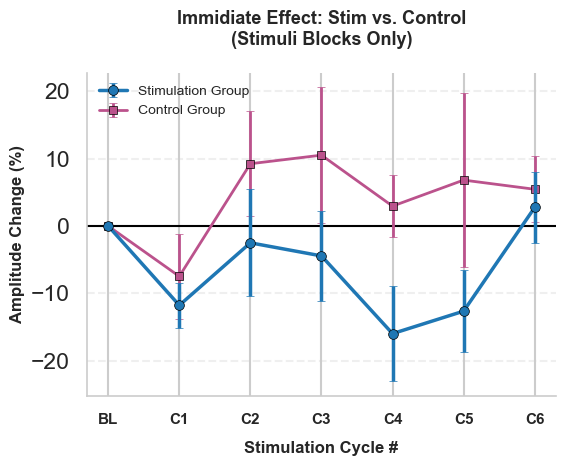

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד נתונים עבור קבוצת הגירוי ---
df_cum_stim = get_clean_matrix(data_stim['relative_spike_amplitude']['all'], mode='consecutive')
mean_stim = df_cum_stim.mean()
sem_stim = df_cum_stim.sem()

# --- 2. עיבוד נתונים עבור קבוצת הקונטרול ---
df_cum_ctrl = get_clean_matrix(data_control['relative_spike_amplitude']['all'], mode='consecutive')
mean_ctrl = df_cum_ctrl.mean()
sem_ctrl = df_cum_ctrl.sem()

# --- 3. שליפת זמני הגירוי בלבד (אינדקסים 1, 3, 5, 7) ---
stim_idx = [1, 3, 5, 7, 9, 11] # אינדקסים של בלוקי הגירוי בתוך המטריצה

# פונקציה להכנת הקו (הוספת 0 של ה-BL בהתחלה)
def prepare_group_line(mean_s, sem_s, idx_list):
    y = [0] + mean_s.iloc[idx_list].tolist()
    err = [0] + sem_s.iloc[idx_list].tolist()
    return y, err

y_stim, err_stim = prepare_group_line(mean_stim, sem_stim, stim_idx)
y_ctrl, err_ctrl = prepare_group_line(mean_ctrl, sem_ctrl, stim_idx)

# ציר X (BL ואז מחזורים 1 עד 4)
x_axis = np.arange(len(y_stim))

# --- 4. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(6, 5))

# הגדרות סטייל
stim_color = '#1f77b4' # כחול חזק לקבוצת הגירוי
ctrl_color = '#bb528c' # אפור לקבוצת הביקורת

style_stim = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 7, 'linewidth': 2.5, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
style_ctrl = {'fmt': '-s', 'color': ctrl_color, 'ecolor': ctrl_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markerfacecolor': '#bb528c', 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

# ציור הקווים
ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation Group', zorder=5, **style_stim)
ax.errorbar(x_axis, y_ctrl, yerr=err_ctrl, label='Control Group', zorder=4, **style_ctrl)

# קו אפס שחור
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)

# עיצוב צירים
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# הגדרות Y
ax.set_ylabel('Amplitude Change (%)', fontsize=12, fontweight='bold')

# הגדרות X
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6'], fontsize=11, fontweight='bold')
ax.set_xlabel('Stimulation Cycle #', fontsize=12, fontweight='bold', labelpad=10)

ax.set_title('Immidiate Effect: Stim vs. Control\n(Stimuli Blocks Only)', fontsize=13, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

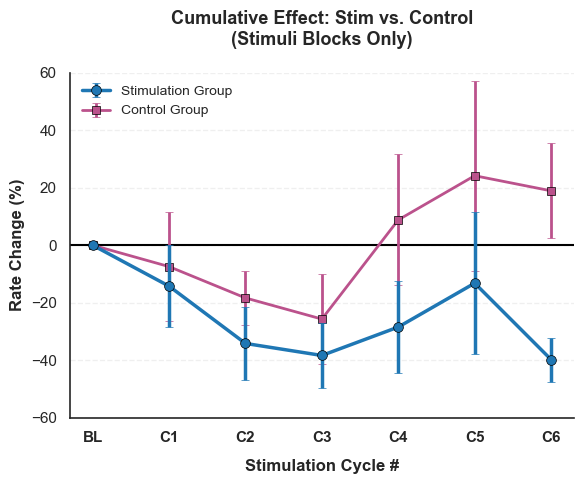

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד נתונים עבור קבוצת הגירוי ---
df_cum_stim = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
mean_stim = df_cum_stim.mean()
sem_stim = df_cum_stim.sem()

# --- 2. עיבוד נתונים עבור קבוצת הקונטרול ---
df_cum_ctrl = get_clean_matrix(data_control['rates']['all'], mode='baseline')
mean_ctrl = df_cum_ctrl.mean()
sem_ctrl = df_cum_ctrl.sem()

# --- 3. שליפת זמני הגירוי בלבד (אינדקסים 1, 3, 5, 7) ---
stim_idx = [1, 3, 5, 7, 9, 11] # אינדקסים של בלוקי הגירוי בתוך המטריצה

# פונקציה להכנת הקו (הוספת 0 של ה-BL בהתחלה)
def prepare_group_line(mean_s, sem_s, idx_list):
    y = [0] + mean_s.iloc[idx_list].tolist()
    err = [0] + sem_s.iloc[idx_list].tolist()
    return y, err

y_stim, err_stim = prepare_group_line(mean_stim, sem_stim, stim_idx)
y_ctrl, err_ctrl = prepare_group_line(mean_ctrl, sem_ctrl, stim_idx)

# ציר X (BL ואז מחזורים 1 עד 4)
x_axis = np.arange(len(y_stim))

# --- 4. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(6, 5))

# הגדרות סטייל
stim_color = '#1f77b4' # כחול חזק לקבוצת הגירוי
ctrl_color = '#bb528c' # אפור לקבוצת הביקורת

style_stim = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 7, 'linewidth': 2.5, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
style_ctrl = {'fmt': '-s', 'color': ctrl_color, 'ecolor': ctrl_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markerfacecolor': '#bb528c', 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

# ציור הקווים
ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation Group', zorder=5, **style_stim)
ax.errorbar(x_axis, y_ctrl, yerr=err_ctrl, label='Control Group', zorder=4, **style_ctrl)

# קו אפס שחור
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)

# עיצוב צירים
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# הגדרות Y
ax.set_yticks(np.arange(-60, 80, 20))
ax.set_ylim(-60, 60)
ax.set_ylabel('Rate Change (%)', fontsize=12, fontweight='bold')

# הגדרות X
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6'], fontsize=11, fontweight='bold')
ax.set_xlabel('Stimulation Cycle #', fontsize=12, fontweight='bold', labelpad=10)

ax.set_title('Cumulative Effect: Stim vs. Control\n(Stimuli Blocks Only)', fontsize=13, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

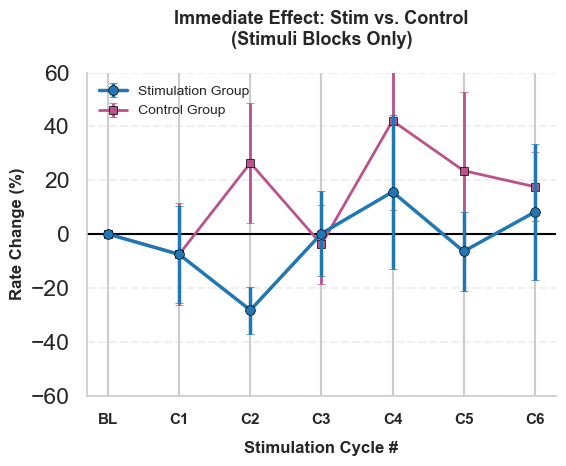

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד נתונים עבור קבוצת הגירוי ---
df_cum_stim = get_clean_matrix(data_stim['rates']['all'], mode='consecutive')
mean_stim = df_cum_stim.mean()
sem_stim = df_cum_stim.sem()

# --- 2. עיבוד נתונים עבור קבוצת הקונטרול ---
df_cum_ctrl = get_clean_matrix(data_control['rates']['all'], mode='consecutive')
mean_ctrl = df_cum_ctrl.mean()
sem_ctrl = df_cum_ctrl.sem()

# --- 3. שליפת זמני הגירוי בלבד (אינדקסים 1, 3, 5, 7) ---
stim_idx = [1, 3, 5, 7, 9, 11] # אינדקסים של בלוקי הגירוי בתוך המטריצה

# פונקציה להכנת הקו (הוספת 0 של ה-BL בהתחלה)
def prepare_group_line(mean_s, sem_s, idx_list):
    y = [0] + mean_s.iloc[idx_list].tolist()
    err = [0] + sem_s.iloc[idx_list].tolist()
    return y, err

y_stim, err_stim = prepare_group_line(mean_stim, sem_stim, stim_idx)
y_ctrl, err_ctrl = prepare_group_line(mean_ctrl, sem_ctrl, stim_idx)

# ציר X (BL ואז מחזורים 1 עד 4)
x_axis = np.arange(len(y_stim))

# --- 4. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(6, 5))

# הגדרות סטייל
stim_color = '#1f77b4' # כחול חזק לקבוצת הגירוי
ctrl_color = '#bb528c' # אפור לקבוצת הביקורת

style_stim = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 7, 'linewidth': 2.5, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
style_ctrl = {'fmt': '-s', 'color': ctrl_color, 'ecolor': ctrl_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markerfacecolor': '#bb528c', 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

# ציור הקווים
ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation Group', zorder=5, **style_stim)
ax.errorbar(x_axis, y_ctrl, yerr=err_ctrl, label='Control Group', zorder=4, **style_ctrl)

# קו אפס שחור
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)

# עיצוב צירים
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# הגדרות Y
ax.set_yticks(np.arange(-60, 80, 20))
ax.set_ylim(-60, 60)
ax.set_ylabel('Rate Change (%)', fontsize=12, fontweight='bold')

# הגדרות X
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6'], fontsize=11, fontweight='bold')
ax.set_xlabel('Stimulation Cycle #', fontsize=12, fontweight='bold', labelpad=10)

ax.set_title('Immediate Effect: Stim vs. Control\n(Stimuli Blocks Only)', fontsize=13, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [98]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# --- 1. הכנת הנתונים (כל בלוקי הגירוי הקיימים) ---
df_stim_raw = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
df_ctrl_raw = get_clean_matrix(data_control['rates']['all'], mode='baseline')

def prepare_all_stim_blocks(df, group_label):
    # שליפת כל האינדקסים האי-זוגיים הקיימים במטריצה (1, 3, 5, 7, 9...)
    all_indices = [i for i in range(len(df)) if i % 2 != 0]
    
    subset = df.iloc[all_indices].copy()
    long_df = subset.melt(ignore_index=False).reset_index()
    long_df.columns = ['block_id', 'subject_id', 'rate_change']
    long_df['group'] = group_label
    
    # חישוב ה-Cycle לכל אורך הדאטה
    long_df['cycle'] = (long_df['block_id'].astype(int) // 2) + 1
    return long_df

# איחוד הקבוצות - הפעם עם כל הבלוקים
df_model_all = pd.concat([
    prepare_all_stim_blocks(df_stim_raw, 'stimulation'),
    prepare_all_stim_blocks(df_ctrl_raw, 'control')
])

# ניקוי NaNs וסידור אינדקסים
df_model_all = df_model_all.dropna(subset=['rate_change', 'subject_id']).reset_index(drop=True)
df_model_all['subject_id'] = df_model_all['subject_id'].astype(str)

# בדיקה: כמה בלוקים יש לנו עכשיו?
print(f"Total observations in model: {len(df_model_all)}")
print(f"Max cycle reached: {df_model_all['cycle'].max()}")

# --- 2. בניית המודל ההיררכי על כל הדאטה ---
hierarchical_model_all = smf.mixedlm("rate_change ~ group * cycle", 
                                     df_model_all, 
                                     groups=df_model_all["subject_id"])

results_all = hierarchical_model_all.fit()

# --- 3. הדפסת תוצאות ---
print("\n" + "="*60)
print("   HIERARCHICAL MODEL RESULTS (ALL STIM BLOCKS)")
print("="*60)
print(results_all.summary().tables[1])

# בדיקת מובהקות האינטראקציה
p_inter = results_all.pvalues['group[T.stimulation]:cycle']
print("-" * 60)
print(f"Interaction P-value (Group x Cycle): {p_inter:.4f}")
print("="*60)

Total observations in model: 133
Max cycle reached: 6

   HIERARCHICAL MODEL RESULTS (ALL STIM BLOCKS)
                              Coef. Std.Err.       z  P>|z|    [0.025   0.975]
Intercept                    24.357   13.495   1.805  0.071    -2.091   50.806
group[T.stimulation]        -79.413   18.559  -4.279  0.000  -115.788  -43.038
cycle                       -12.924    3.966  -3.259  0.001   -20.696   -5.151
group[T.stimulation]:cycle   15.326    5.250   2.919  0.004     5.035   25.616
Group Var                   118.511    2.954                                  
------------------------------------------------------------
Interaction P-value (Group x Cycle): 0.0035


In [99]:
print(df_model_all['cycle'].value_counts().sort_index())

cycle
1    22
2    26
3    26
4    26
5    24
6     9
Name: count, dtype: int64


In [101]:
import pandas as pd
import statsmodels.formula.api as smf

# --- 1. הכנת הנתונים (צורה בטוחה) ---
df_stim_raw = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
df_ctrl_raw = get_clean_matrix(data_control['rates']['all'], mode='baseline')

def get_blocks_by_type_safe(df, group_label, block_type='stim'):
    # הגדרת אינדקסים לפי סוג הבלוק
    if block_type == 'stim':
        indices = [i for i in range(len(df)) if i % 2 != 0] # 1, 3, 5...
    else:
        indices = [i for i in range(len(df)) if i % 2 == 0 and i > 0] # 2, 4, 6...
    
    # שליפת הנתונים הקיימים בלבד עבור המטריצה הספציפית הזו
    # (מוודא שלא נחרוג מהגבולות של המטריצה הזו)
    valid_indices = [i for i in indices if i < len(df)]
    
    long_df = df.iloc[valid_indices].melt(ignore_index=False).reset_index()
    long_df.columns = ['block_id', 'subject_id', 'change']
    long_df['group'] = group_label
    return long_df.dropna(subset=['change', 'subject_id'])

# --- 2. הרצת המודלים ---

# א. מקטעי גירוי בלבד
df_stim_only = pd.concat([
    get_blocks_by_type_safe(df_stim_raw, 'stimulation', 'stim'),
    get_blocks_by_type_safe(df_ctrl_raw, 'control', 'stim')
])
df_stim_only['subject_id'] = df_stim_only['subject_id'].astype(str)

model_stim = smf.mixedlm("change ~ group", df_stim_only, groups=df_stim_only["subject_id"])
res_stim = model_stim.fit()

# ב. מקטעי הפסקה בלבד
df_pause_only = pd.concat([
    get_blocks_by_type_safe(df_stim_raw, 'stimulation', 'pause'),
    get_blocks_by_type_safe(df_ctrl_raw, 'control', 'pause')
])
df_pause_only['subject_id'] = df_pause_only['subject_id'].astype(str)

model_pause = smf.mixedlm("change ~ group", df_pause_only, groups=df_pause_only["subject_id"])
res_pause = model_pause.fit()

# --- 3. הדפסת תוצאות ---
print("="*60)
print("     HIERARCHICAL COMPARISON: STIMULATION BLOCKS")
print("="*60)
print(res_stim.summary().tables[1])
print(f"\nP-value for Group Difference during STIM: {res_stim.pvalues['group[T.stimulation]']:.4f}")

print("\n\n" + "="*60)
print("     HIERARCHICAL COMPARISON: PAUSE BLOCKS")
print("="*60)
print(res_pause.summary().tables[1])
print(f"\nP-value for Group Difference during PAUSE: {res_pause.pvalues['group[T.stimulation]']:.4f}")

C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


     HIERARCHICAL COMPARISON: STIMULATION BLOCKS
                        Coef. Std.Err.       z  P>|z|   [0.025   0.975]
Intercept             -14.413    6.464  -2.230  0.026  -27.082   -1.744
group[T.stimulation]  -32.418    8.165  -3.970  0.000  -48.421  -16.415
Group Var             102.975    2.834                                 

P-value for Group Difference during STIM: 0.0001


     HIERARCHICAL COMPARISON: PAUSE BLOCKS
                        Coef. Std.Err.       z  P>|z|   [0.025  0.975]
Intercept              17.457    8.337   2.094  0.036    1.116  33.798
group[T.stimulation]  -11.683   11.087  -1.054  0.292  -33.413  10.048
Group Var               0.442    3.076                                

P-value for Group Difference during PAUSE: 0.2920



--- Statistical Results ---

Phase: ON
  Stim vs 0: p = 0.06543
  Ctrl vs 0: p = 0.53906
  Stim vs Ctrl: p = 0.08099

Phase: OFF
  Stim vs 0: p = 0.09668
  Ctrl vs 0: p = 0.38477
  Stim vs Ctrl: p = 0.09294


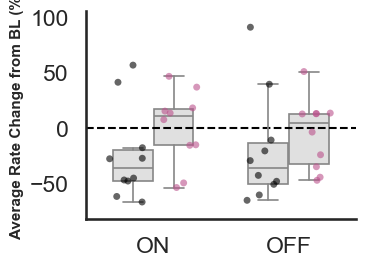

In [38]:

def plot_split_groups_reproducible_safe(data_stim, data_control):
    # 1. ניקוי וסגירת פיגרים קודמים
    plt.close('all')
    fig, ax = plt.subplots(figsize=(4, 3))
    
    # 2. עיבוד נתונים
    df_s = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
    df_c = get_clean_matrix(data_control['rates']['all'], mode='baseline')
    
    def get_split_means(df, group_name):
        stim_blocks = df.iloc[:, 1::2].mean(axis=1)
        pause_blocks = df.iloc[:, 2::2].mean(axis=1)
        return pd.DataFrame({
            'Change': pd.concat([stim_blocks, pause_blocks]),
            'Block_Type': ['ON']*len(stim_blocks) + ['OFF']*len(pause_blocks),
            'Group': group_name
        }).dropna()

    plot_df = pd.concat([get_split_means(df_s, 'Stimulation'), get_split_means(df_c, 'Control')])
    
    group_order = ['Stimulation', 'Control']
    point_pal = {'Stimulation': 'black', 'Control': '#bb528c'}
    box_color = '#e0e0e0'
    
    # 3. יצירת בוקספלוט
    sns.set_style("white")
    sns.boxplot(data=plot_df, x='Block_Type', y='Change', hue='Group', 
                hue_order=group_order, color=box_color, width=0.6, 
                fliersize=0, zorder=2, linewidth=1.2, ax=ax)
    
    for patch in ax.patches:
        patch.set_facecolor(box_color)

    # 4. פריסת נקודות קבועה - הדרך הבטוחה
    # הגדרת ה-Seed כאן מבטיחה שה-Jitter של stripplot יהיה זהה בכל הרצה
    np.random.seed(4) 
    
    sns.stripplot(data=plot_df, x='Block_Type', y='Change', hue='Group', 
                  hue_order=group_order, dodge=True, palette=point_pal, 
                  alpha=0.6, size=5, jitter=0.25, ax=ax, zorder=3)

    # 5. הדפסת סטטיסטיקה מלאה
    print("\n--- Statistical Results ---")
    for b_type in ['ON', 'OFF']:
        s_vals = plot_df[(plot_df['Block_Type'] == b_type) & (plot_df['Group'] == 'Stimulation')]['Change']
        c_vals = plot_df[(plot_df['Block_Type'] == b_type) & (plot_df['Group'] == 'Control')]['Change']
        print(f"\nPhase: {b_type}")
        if len(s_vals) >= 5:
            res_w = wilcoxon(s_vals, alternative='less')
            print(f"  Stim vs 0: p = {res_w.pvalue:.5f}")
        if len(c_vals) >= 5:
            res_w = wilcoxon(c_vals, alternative='less')
            print(f"  Ctrl vs 0: p = {res_w.pvalue:.5f}")
        if len(s_vals) >= 5 and len(c_vals) >= 5:
            _, p_mw = mannwhitneyu(s_vals, c_vals, alternative='less')
            print(f"  Stim vs Ctrl: p = {p_mw:.5f}")

    # 6. עיצוב סופי
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=1)
    ax.set_ylabel('Average Rate Change from BL (%)', fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    if ax.get_legend(): ax.get_legend().remove()
    ax.set_ylim(plot_df['Change'].min() - 15, plot_df['Change'].max() + 15)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_split_groups_reproducible_safe(data_stim, data_control)


   NON-PARAMETRIC ONE-TAILED RESULTS
Stimulation vs 0 (Wilcoxon) | p (one-tailed) = 0.01562
Pause vs 0       (Wilcoxon) | p (one-tailed) = 0.21875
Stim < Pause     (Wilcoxon) | p (one-tailed) = 0.34375


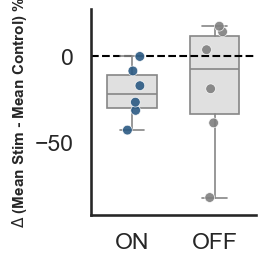

In [40]:
import seaborn as sns
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. חישוב הממוצעים וההפרשים (ממוצע קבוצתי לכל נקודת זמן)
mean_series_stim = df_stim.iloc[:, 1:].mean()
mean_series_ctrl = df_control.iloc[:, 1:].mean()
time_point_diffs = mean_series_stim - mean_series_ctrl

# 2. פיצול ל-6 נקודות גירוי (ON) ו-6 נקודות הפסקה (OFF)
stim_diffs = time_point_diffs.iloc[::2]
pause_diffs = time_point_diffs.iloc[1::2]

# 3. ניתוח סטטיסטי לא-פרמטרי חד-כיווני (One-tailed) - הדפסה בלבד
print("\n" + "="*45)
print("   NON-PARAMETRIC ONE-TAILED RESULTS")
print("="*45)

# א. האם הגירוי מוריד את ה-Rate מול 0? (Wilcoxon)
# alternative='less' בודק אם הערכים קטנים מ-0
_, p_stim_0_one = stats.wilcoxon(stim_diffs, alternative='less')

# ב. האם ההפסקה מראה ירידה מובהקת מול 0? (Wilcoxon)
_, p_pause_0_one = stats.wilcoxon(pause_diffs, alternative='less')

# ג. האם האפקט בגירוי חזק (נמוך) יותר מההפסקה? (Wilcoxon Paired)
# משתמשים ב-wilcoxon כי הנקודות מזווגות כרונולוגית
res_comp_one = stats.wilcoxon(stim_diffs, pause_diffs, alternative='less')

print(f"Stimulation vs 0 (Wilcoxon) | p (one-tailed) = {p_stim_0_one:.5f}")
print(f"Pause vs 0       (Wilcoxon) | p (one-tailed) = {p_pause_0_one:.5f}")
print(f"Stim < Pause     (Wilcoxon) | p (one-tailed) = {res_comp_one.pvalue:.5f}")

# 4. הכנת נתונים לגרף
plot_df = pd.DataFrame({
    'Difference': np.concatenate([stim_diffs.values, pause_diffs.values]),
    'Type': ['ON'] * 6 + ['OFF'] * 6
})

# 5. ויזואליזציה מעוצבת
plt.close('all')
fig, ax = plt.subplots(figsize=(3, 3))
sns.set_style("white")

group_order = ['ON', 'OFF']
point_pal = {'ON': '#2b5a83', 'OFF': '#808080'} 
box_color = '#e0e0e0' 

# בוקספלוט ניטרלי
sns.boxplot(data=plot_df, x='Type', y='Difference', order=group_order,
            color=box_color, width=0.6, fliersize=0, zorder=2, linewidth=1.2, ax=ax)

# צביעת הבוקסים באפור
for patch in ax.patches:
    patch.set_facecolor(box_color)

# הוספת נקודות (Jitter קטן למרכוז כמו במקור) עם Seed קבוע
np.random.seed(4) 
sns.stripplot(data=plot_df, x='Type', y='Difference', order=group_order,
              dodge=True, palette=point_pal, alpha=0.9, size=7, 
              jitter=0.1, edgecolor='white', linewidth=0.5, ax=ax, zorder=3)

# 6. עיצוב סופי
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=1)
ax.set_ylabel(r'$\Delta$ (Mean Stim - Mean Control) %', fontweight='bold', fontsize=11)
ax.set_xlabel('')

if ax.get_legend(): ax.get_legend().remove()
ax.set_ylim(plot_df['Difference'].min() - 10, plot_df['Difference'].max() + 10)

sns.despine()
plt.tight_layout()
plt.show()


   OVERALL EFFECT: ONE-TAILED WILCOXON
Overall Difference vs 0 | p (one-tailed) = 0.01709
ON vs OFF Comparison    | p (one-tailed) = 0.34375


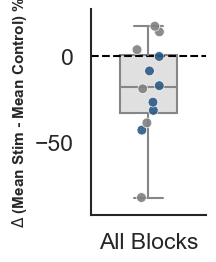

In [41]:
import seaborn as sns
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. חישוב הממוצעים וההפרשים - העתקה מדויקת של הלוגיקה שעבדה לך
mean_series_stim = df_stim.iloc[:, 1:].mean()
mean_series_ctrl = df_control.iloc[:, 1:].mean()
time_point_diffs = mean_series_stim - mean_series_ctrl

# פיצול ל-6 נקודות גירוי (ON) ו-6 נקודות הפסקה (OFF)
stim_diffs = time_point_diffs.iloc[::2]
pause_diffs = time_point_diffs.iloc[1::2]

# 2. ניתוח סטטיסטי לא-פרמטרי חד-כיווני (One-tailed Wilcoxon)
print("\n" + "="*45)
print("   OVERALL EFFECT: ONE-TAILED WILCOXON")
print("="*45)

# א. האם כל 12 הבלוקים יחד נמוכים מ-0 באופן מובהק?
_, p_overall = stats.wilcoxon(time_point_diffs, alternative='less')

# ב. האם הגירוי (ON) נמוך משמעותית מההפסקה (OFF)? (מבחן מזווג)
_, p_on_off = stats.wilcoxon(stim_diffs, pause_diffs, alternative='less')

print(f"Overall Difference vs 0 | p (one-tailed) = {p_overall:.5f}")
print(f"ON vs OFF Comparison    | p (one-tailed) = {p_on_off:.5f}")

# 3. הכנת נתונים לגרף - שימוש ב-concatenate מבטיח עקביות צבעים
# אנחנו יוצרים רשימה של 6 'ON' ואז 6 'OFF' שמתאימה בדיוק לסדר הערכים
plot_df = pd.DataFrame({
    'Difference': np.concatenate([stim_diffs.values, pause_diffs.values]),
    'Type': ['ON'] * 6 + ['OFF'] * 6,
    'Group': 'All Blocks' # שם קטגוריה אחת לציר ה-X
})

# 4. ויזואליזציה מעוצבת ואחידה
plt.close('all')
fig, ax = plt.subplots(figsize=(2.5, 3)) # פרופורציה צרה וגבוהה
sns.set_style("white")

point_pal = {'ON': '#2b5a83', 'OFF': '#808080'} # כחול ואפור המקוריים
box_color = '#e0e0e0' 

# בוקספלוט יחיד
sns.boxplot(data=plot_df, x='Group', y='Difference', color=box_color, 
            width=0.5, fliersize=0, zorder=2, linewidth=1.5, ax=ax)

# צביעת הבוקס
for patch in ax.patches:
    patch.set_facecolor(box_color)

# הוספת הנקודות - dodge=False גורם לכולן להיות על אותו ציר מרכזי
np.random.seed(4) 
sns.stripplot(data=plot_df, x='Group', y='Difference', hue='Type', 
              hue_order=['ON', 'OFF'], dodge=False, 
              palette=point_pal, alpha=0.9, size=7, jitter=0.1, 
              edgecolor='white', linewidth=0.5, ax=ax, zorder=3)

# 5. עיצוב סופי (עובי צירים 1.5 לאחידות)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=1)
ax.set_ylabel(r'$\Delta$ (Mean Stim - Mean Control) %', fontweight='bold', fontsize=11)
ax.set_xlabel('')

# עיבוי צירים (Spines)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(1.5)
ax.tick_params(width=1.5)

# הסרת המקרא
if ax.get_legend():
    ax.get_legend().remove()

# הגדרת גבולות ציר Y (מרווח סביר סביב הנתונים)
ax.set_ylim(plot_df['Difference'].min() - 10, plot_df['Difference'].max() + 10)

sns.despine()
plt.tight_layout()
plt.show()

Processing p485 for electrode RPSMA4...
Found 68 electrodes for p485. Looking for RPSMA4...
Processing p486 for electrode LOF4...
Found 89 electrodes for p486. Looking for LOF4...
Processing p487 for electrode ROF5...
Found 71 electrodes for p487. Looking for ROF5...
Processing p488 for electrode LOF4...
Found 87 electrodes for p488. Looking for LOF4...
Processing p489 for electrode RPHG5...
Found 82 electrodes for p489. Looking for RPHG5...
Processing p496 for electrode RTOP6...
Found 66 electrodes for p496. Looking for RTOP6...
Processing p497 for electrode ROF7...
Found 77 electrodes for p497. Looking for ROF7...
Processing p498 for electrode LOF6...
Found 76 electrodes for p498. Looking for LOF6...
Processing p499 for electrode LOF6...
Found 66 electrodes for p499. Looking for LOF6...
Processing p505 for electrode LOF-AC7...
Found 75 electrodes for p505. Looking for LOF-AC7...
Processing p510 for electrode ROF6...
Found 96 electrodes for p510. Looking for ROF6...
Processing p515 fo

AttributeError: 'GlassBrainAxes' object has no attribute 'cmap'

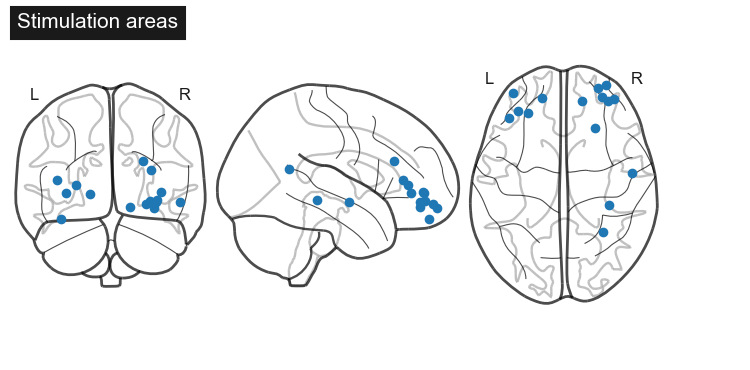

In [42]:
import pandas as pd
import numpy as np
from nilearn import plotting
import matplotlib.pyplot as plt

# --- שלב 1: הגדרת הפונקציות לקריאת וחישוב קואורדינטות ---

def read_coordinates_files(electrodes_name_file_path: str, electrodes_location_file_path: str):
    name_data = pd.read_csv(
        filepath_or_buffer=electrodes_name_file_path,
        delimiter=' ',
        usecols=[0],
        skiprows=2,
        header=None,
        dtype={0: str}
    )
    location_data = pd.read_csv(
        filepath_or_buffer=electrodes_location_file_path,
        delimiter=' ',
        skiprows=2,
        header=None,
        dtype={0: float, 1: float, 2: float}
    )

    name_to_coordinates = {}
    for names_row, location_row in zip(name_data.iterrows(), location_data.iterrows()):
        electrode_name = f'{names_row[1][0]}'
        name_to_coordinates[electrode_name] = (
            location_row[1][0],
            location_row[1][1],
            location_row[1][2]
        )
    return name_to_coordinates

def calculate_coordinates(avarage=True):
    # כאן הגדרתי גרסה פשוטה של הפונקציה שסורקת את התיקייה הכללית
    # הנתיב נלקח מהלוגיקה של הקוד הקודם שלך
    coordinates_dir = r'C:\repos\NirsLabProject\NirsLabProject\data\cordinates'
    
    _sum = {}
    count = {}
    
    # חיפוש קבצי שמות אלקטרודות
    files = [f for f in os.listdir(coordinates_dir) if f.endswith('.electrodeNames')]
    
    for file in files:
        loc_file_path = os.path.join(coordinates_dir, file)
        pial_file_path = os.path.join(coordinates_dir, file.replace('.electrodeNames', '.Pial'))
        
        if not os.path.exists(loc_file_path) or not os.path.exists(pial_file_path):
            continue
            
        electrode_name_to_location = read_coordinates_files(loc_file_path, pial_file_path)
        for electrode_name, location in electrode_name_to_location.items():
            if electrode_name not in _sum:
                _sum[electrode_name] = [0, 0, 0]
                count[electrode_name] = 0
            count[electrode_name] += 1
            _sum[electrode_name][0] += location[0]
            _sum[electrode_name][1] += location[1]
            _sum[electrode_name][2] += location[2]

    for electrode in _sum:
        _sum[electrode][0] /= count[electrode]
        _sum[electrode][1] /= count[electrode]
        _sum[electrode][2] /= count[electrode]

    return _sum

# --- שלב 2: הרצת התהליך על הנבדקים שלך ---

subjects = ['p485', 'p486', 'p487', 'p488', 'p489', 'p496', 'p497', 'p498', 'p499', 'p505', 'p5107', 'p515', 'p520', 'p538', 'p545']
all_coords = calculate_coordinates(avarage=True)

# 1. הגדרת המילון - התאימי את שמות האלקטרודות לפי מה שמופיע אצלך בנתונים
subject_to_electrode = {
    'p485': 'RPSMA4',
    'p486': 'LOF4',
    'p487': 'ROF5',
    'p488': 'LOF4',
    'p489': 'RPHG5',
    'p496': 'RTOP6',
    'p497': 'ROF7',
    'p498': 'LOF6',
    'p499': 'LOF6',
    'p505': 'LOF-AC7',
    'p510': 'ROF6',
    'p515': 'ROF2',
    'p520': 'ROF5',
    'p538': 'RHSG4',
    'p545': 'ROF4'
}

# 2. פונקציה לשליפת המיקומים הספציפיים בלבד
def get_selected_electrodes_data(subject_map):
    coordinates_dir = r'C:\repos\NirsLabProject\NirsLabProject\data\cordinates'
    selected_data = []
    
    for subj, target_electrode in subject_map.items():
        loc_file = os.path.join(coordinates_dir, f'{subj[1:]}.electrodeNames')
        print(f"Processing {subj} for electrode {target_electrode}...")
        pial_file = os.path.join(coordinates_dir, f'{subj[1:]}.PIAL')
        
        if os.path.exists(loc_file):
            # טעינת כל האלקטרודות של הנבדק
            subj_coords = read_coordinates_files(loc_file, pial_file)
            print(f"Found {len(subj_coords)} electrodes for {subj}. Looking for {target_electrode}...")
            
            # בדיקה אם האלקטרודה המבוקשת קיימת עבורו
            if target_electrode in subj_coords:
                x, y, z = subj_coords[target_electrode]
                selected_data.append({
                    'subject': subj,
                    'electrode': target_electrode,
                    'x': x,
                    'y': y,
                    'z': z
                })
            else:
                print(f"Warning: Electrode {target_electrode} not found for subject {subj}")
    
    return pd.DataFrame(selected_data)

# 3. הרצה וויזואליזציה
df_selected = get_selected_electrodes_data(subject_to_electrode)

# חילוץ קואורדינטות
coords = df_selected[['x', 'y', 'z']].values

# ציור ב-Nilearn (תצוגה אורתוגונלית שמראה את המיקום המדויק בתוך המוח)
plotting.plot_connectome(
    adjacency_matrix=np.zeros((len(coords), len(coords))),
    node_coords=coords,
    node_color='tab:blue', 
    node_size=30,
    display_mode='ortho',
    title="Stimulation areas"
)


In [44]:
from matplotlib import colors
from nilearn import plotting

# 1. הגדרת צבע כחול עם שקיפות (Alpha = 0.5)
# אפשר לשנות את ה-0.5 לערך נמוך יותר לשקיפות גבוהה יותר
node_color_transparent = colors.to_rgba('tab:blue', alpha=0.8)

# 2. ציור ושמירה כקובץ PDF
plotting.plot_connectome(
    adjacency_matrix=np.zeros((len(coords), len(coords))),
    node_coords=coords,
    node_color=[node_color_transparent] * len(coords), # רשימת צבעים לכל נקודה
    node_size=30,
    display_mode='ortho',
    colorbar=False,           
    output_file='stimulation_areas.pdf' # שמירה כקובץ PDF וקטורי
)

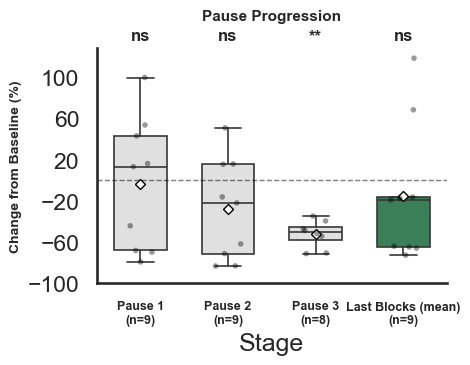

In [13]:


# 2. עיבוד הנתונים למקטעי הפסקה (Pauses)
def prepare_pause_data():
    exclude = ['515', '545']
    all_subjects_processed = []
    raw_data = for_avg_props_raw['rates']['all']
    
    for name, subj_rates in zip(subject_ids, raw_data):
        if name in exclude: continue
            
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue # חייב לפחות בייסליין והפסקה ראשונה
        
        baseline = subj_rates[0]
        # שליפת ההפסקות: אינדקסים 2, 4, 6 (Pause 1, 2, 3)
        pauses = subj_rates[2::2] 
        
        if len(pauses) < 3: continue 
        
        denom = baseline if baseline != 0 else 1e-9
        pct_changes = ((pauses - baseline) / denom) * 100
        
        p1, p2, p3 = pct_changes[0], pct_changes[1], pct_changes[2]
        rest_remaining = pct_changes[3:]
        mean_rest = np.nanmean(rest_remaining) if len(rest_remaining) > 0 else np.nan
        
        all_subjects_processed.append([p1, p2, p3, mean_rest])
    
    stages = ['Pause 1', 'Pause 2', 'Pause 3', 'Last Blocks (mean)']
    df_wide = pd.DataFrame(all_subjects_processed, columns=stages)
    
    # סינון IQR (threshold=3)
    for col in df_wide.columns:
        Q1, Q3 = df_wide[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_wide.loc[(df_wide[col] < Q1 - 3*IQR) | (df_wide[col] > Q3 + 3*IQR), col] = np.nan

    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    return df_wide, df_long

# 3. יצירת הגרף
def plot_pause_graph(df_wide, df_long):
    plt.figure(figsize=(5, 4))
    sns.set_style("white")
    
    pause_gray = '#e0e0e0' # הצבע האפור שהשתמשנו בו להפסקות
    rest_green = '#2e8b57'
    
    new_labels = [f"{col}\n(n={df_wide[col].dropna().count()})" for col in df_wide.columns]
    
    # בוקספלוט
    ax = sns.boxplot(data=df_long, x='Stage', y='Change_Percent', 
                     palette=[pause_gray, pause_gray, pause_gray, rest_green],
                     width=0.6, fliersize=0, zorder=2, linewidth=1.2,
                     showmeans=True,
                     meanprops={"marker":"D", "markerfacecolor":"white", 
                                "markeredgecolor":"black", "markersize":5})
    
    # נקודות (Stripplot)
    sns.stripplot(data=df_long, x='Stage', y='Change_Percent', 
                  color='black', alpha=0.4, size=4, jitter=0.15, ax=ax, zorder=3)
    
    # סטטיסטיקה - Wilcoxon
    y_max = df_long['Change_Percent'].max()
    for i in range(df_wide.shape[1]):
        data = df_wide.iloc[:, i].dropna()
        if len(data) >= 5:
            _, p_val = wilcoxon(data)
            stars = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
            ax.text(i, y_max * 1.15, stars, ha='center', fontweight='bold', fontsize=12)

    plt.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    
    # ציר Y
    y_min = df_long['Change_Percent'].min()
    ax.set_yticks(np.arange(int(y_min//20)*20, int(y_max//20 + 2)*20, 40))
    
    ax.set_xticklabels(new_labels, fontsize=9, fontweight='bold')
    plt.ylabel("Change from Baseline (%)", fontsize=10, fontweight='bold')
    plt.title("Pause Progression", fontsize=11, fontweight='bold', pad=20)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# --- הרצה ---
df_w_pause, df_l_pause = prepare_pause_data()
plot_pause_graph(df_w_pause, df_l_pause)

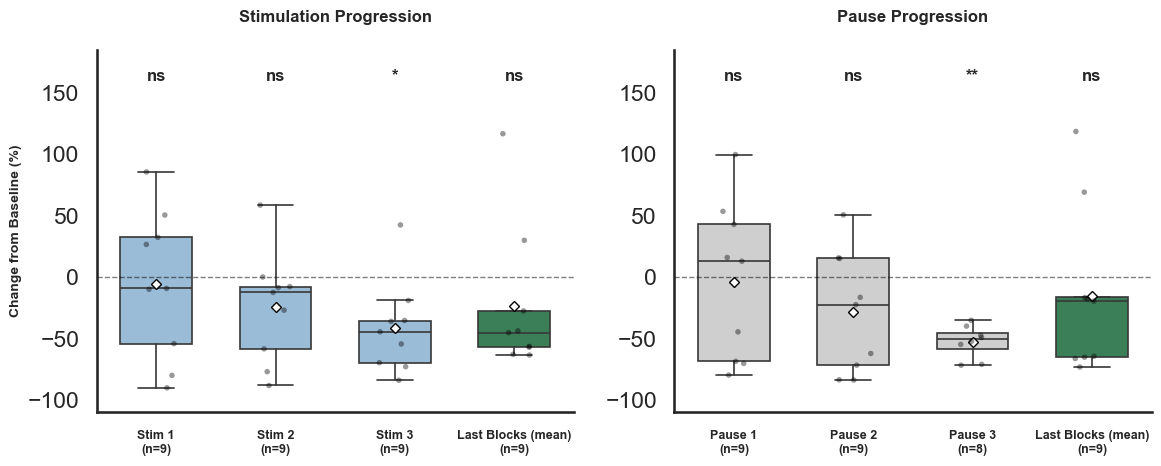

In [14]:
# 1. פונקציית עיבוד גנרית לנתונים מאוחדים (All)
def prepare_unified_data(block_type='stim'):
    exclude = ['515', '545']
    all_subjects_raw_pct = []
    # שימוש בנתוני 'all' כפי שביקשת
    raw_data = for_avg_props_raw['rates']['all']
    
    for name, subj_rates in zip(subject_ids, raw_data):
        if name in exclude: continue
        
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        if baseline == 0: continue
        
        # בחירת בלוקים: אי-זוגיים לגירוי, זוגיים להפסקה
        vals = subj_rates[1::2] if block_type == 'stim' else subj_rates[2::2]
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / baseline) * 100
        all_subjects_raw_pct.append(pd.Series(pct_changes))
    
    df_temp = pd.DataFrame(all_subjects_raw_pct)
    
    # שלב הסינון: IQR על כל בלוק בנפרד לפני המיצוע
    for col in df_temp.columns:
        Q1, Q3 = df_temp[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_temp.loc[(df_temp[col] < Q1 - 3*IQR) | (df_temp[col] > Q3 + 3*IQR), col] = np.nan
        
    # בניית השלבים הסופיים
    label_prefix = 'Stim' if block_type == 'stim' else 'Pause'
    final_dict = {
        f'{label_prefix} 1': df_temp[0],
        f'{label_prefix} 2': df_temp[1],
        f'{label_prefix} 3': df_temp[2],
        'Last Blocks (mean)': df_temp.iloc[:, 3:].mean(axis=1)
    }
    
    df_wide = pd.DataFrame(final_dict)
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    return df_wide, df_long

# 2. פונקציית הציור המשותפת
def plot_combined_unified_graphs():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.set_style("white")
    
    # צבעים
    stim_blue = '#91bde1'
    pause_gray = '#cfcfcf'
    last_blocks_color = '#2e8b57' # ירוק כפי שהיה בגרף המקורי שלך
    
    def draw_ax(ax, block_type):
        df_w, df_l = prepare_unified_data(block_type)
        
        # הגדרת פלטת צבעים: 3 בלוקים ראשונים בצבע המאפיין, והאחרון בירוק
        current_color = stim_blue if block_type == 'stim' else pause_gray
        pal = [current_color, current_color, current_color, last_blocks_color]
        
        # בוקספלוט
        sns.boxplot(data=df_l, x='Stage', y='Change_Percent', palette=pal,
                    width=0.6, fliersize=0, zorder=2, linewidth=1.2, ax=ax,
                    showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                               "markeredgecolor":"black", "markersize":5})
        
        # נקודות (Stripplot)
        sns.stripplot(data=df_l, x='Stage', y='Change_Percent', color='black', 
                      alpha=0.4, size=4, jitter=0.15, ax=ax, zorder=3)
        
        # סטטיסטיקה מול 0
        y_max = df_l['Change_Percent'].max()
        for i in range(df_w.shape[1]):
            data = df_w.iloc[:, i].dropna()
            if len(data) >= 5:
                _, p = wilcoxon(data)
                stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                # הצבת הכוכביות בגובה אחיד ומעט גבוה יותר
                ax.text(i, 160, stars, ha='center', fontweight='bold', fontsize=12)

        ax.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
        
        # כותרות וצירים
        title = "Stimulation Progression" if block_type == 'stim' else "Pause Progression"
        ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
        ax.set_ylabel("Change from Baseline (%)" if ax == ax1 else "", fontsize=10, fontweight='bold')
        ax.set_xlabel("")
        
        # תוויות X עם n
        new_labels = [f"{col}\n(n={df_w[col].dropna().count()})" for col in df_w.columns]
        ax.set_xticklabels(new_labels, fontsize=9, fontweight='bold')
        
        # הגדרת ציר Y אחיד
        ax.set_ylim(-110, 185)
        ax.set_yticks(np.arange(-100, 151, 50))
        sns.despine(ax=ax)

    draw_ax(ax1, 'stim')
    draw_ax(ax2, 'pause')
    
    plt.tight_layout()
    plt.show()

# הרצה
plot_combined_unified_graphs()

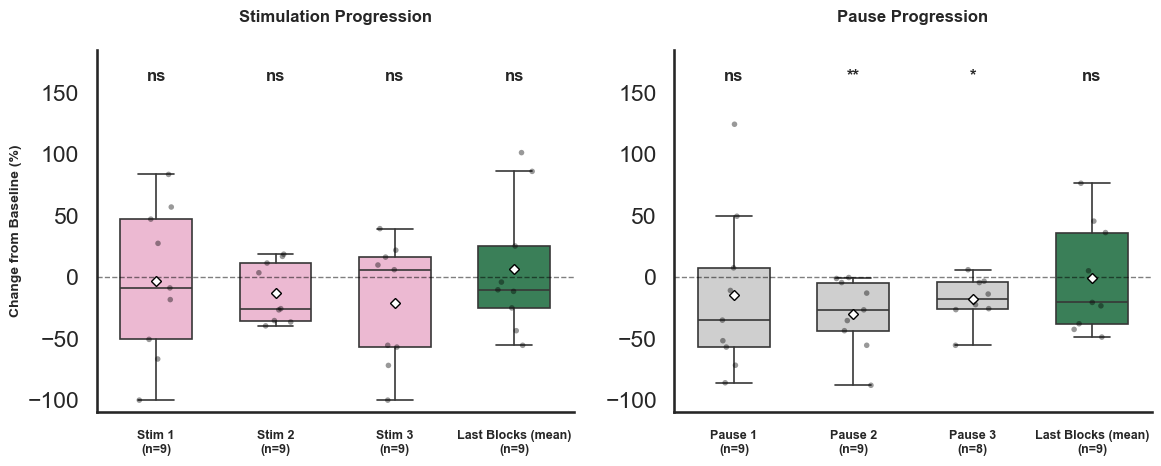

In [38]:
# 1. פונקציית עיבוד גנרית לנתונים מאוחדים (All)
def prepare_unified_data(block_type='stim'):
    exclude = ['515', '545']
    all_subjects_raw_pct = []
    # שימוש בנתוני 'all' כפי שביקשת
    raw_data = data_control['rates']['all']
    
    for name, subj_rates in zip(subject_ids, raw_data):
        if name in exclude: continue
        
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        if baseline == 0: continue
        
        # בחירת בלוקים: אי-זוגיים לגירוי, זוגיים להפסקה
        vals = subj_rates[1::2] if block_type == 'stim' else subj_rates[2::2]
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / baseline) * 100
        all_subjects_raw_pct.append(pd.Series(pct_changes))
    
    df_temp = pd.DataFrame(all_subjects_raw_pct)
    
    # שלב הסינון: IQR על כל בלוק בנפרד לפני המיצוע
    for col in df_temp.columns:
        Q1, Q3 = df_temp[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_temp.loc[(df_temp[col] < Q1 - 3*IQR) | (df_temp[col] > Q3 + 3*IQR), col] = np.nan
        
    # בניית השלבים הסופיים
    label_prefix = 'Stim' if block_type == 'stim' else 'Pause'
    final_dict = {
        f'{label_prefix} 1': df_temp[0],
        f'{label_prefix} 2': df_temp[1],
        f'{label_prefix} 3': df_temp[2],
        'Last Blocks (mean)': df_temp.iloc[:, 3:].mean(axis=1)
    }
    
    df_wide = pd.DataFrame(final_dict)
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    return df_wide, df_long

# 2. פונקציית הציור המשותפת
def plot_combined_unified_graphs():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.set_style("white")
    
    # צבעים
    stim_blue = '#f4b1d2'
    pause_gray = '#cfcfcf'
    last_blocks_color = '#2e8b57' # ירוק כפי שהיה בגרף המקורי שלך
    
    def draw_ax(ax, block_type):
        df_w, df_l = prepare_unified_data(block_type)
        
        # הגדרת פלטת צבעים: 3 בלוקים ראשונים בצבע המאפיין, והאחרון בירוק
        current_color = stim_blue if block_type == 'stim' else pause_gray
        pal = [current_color, current_color, current_color, last_blocks_color]
        
        # בוקספלוט
        sns.boxplot(data=df_l, x='Stage', y='Change_Percent', palette=pal,
                    width=0.6, fliersize=0, zorder=2, linewidth=1.2, ax=ax,
                    showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                               "markeredgecolor":"black", "markersize":5})
        
        # נקודות (Stripplot)
        sns.stripplot(data=df_l, x='Stage', y='Change_Percent', color='black', 
                      alpha=0.4, size=4, jitter=0.15, ax=ax, zorder=3)
        
        # סטטיסטיקה מול 0
        y_max = df_l['Change_Percent'].max()
        for i in range(df_w.shape[1]):
            data = df_w.iloc[:, i].dropna()
            if len(data) >= 5:
                _, p = wilcoxon(data)
                stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                # הצבת הכוכביות בגובה אחיד ומעט גבוה יותר
                ax.text(i, 160, stars, ha='center', fontweight='bold', fontsize=12)

        ax.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
        
        # כותרות וצירים
        title = "Stimulation Progression" if block_type == 'stim' else "Pause Progression"
        ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
        ax.set_ylabel("Change from Baseline (%)" if ax == ax1 else "", fontsize=10, fontweight='bold')
        ax.set_xlabel("")
        
        # תוויות X עם n
        new_labels = [f"{col}\n(n={df_w[col].dropna().count()})" for col in df_w.columns]
        ax.set_xticklabels(new_labels, fontsize=9, fontweight='bold')
        
        # הגדרת ציר Y אחיד
        ax.set_ylim(-110, 185)
        ax.set_yticks(np.arange(-100, 151, 50))
        sns.despine(ax=ax)

    draw_ax(ax1, 'stim')
    draw_ax(ax2, 'pause')
    
    plt.tight_layout()
    plt.show()

# הרצה
plot_combined_unified_graphs()

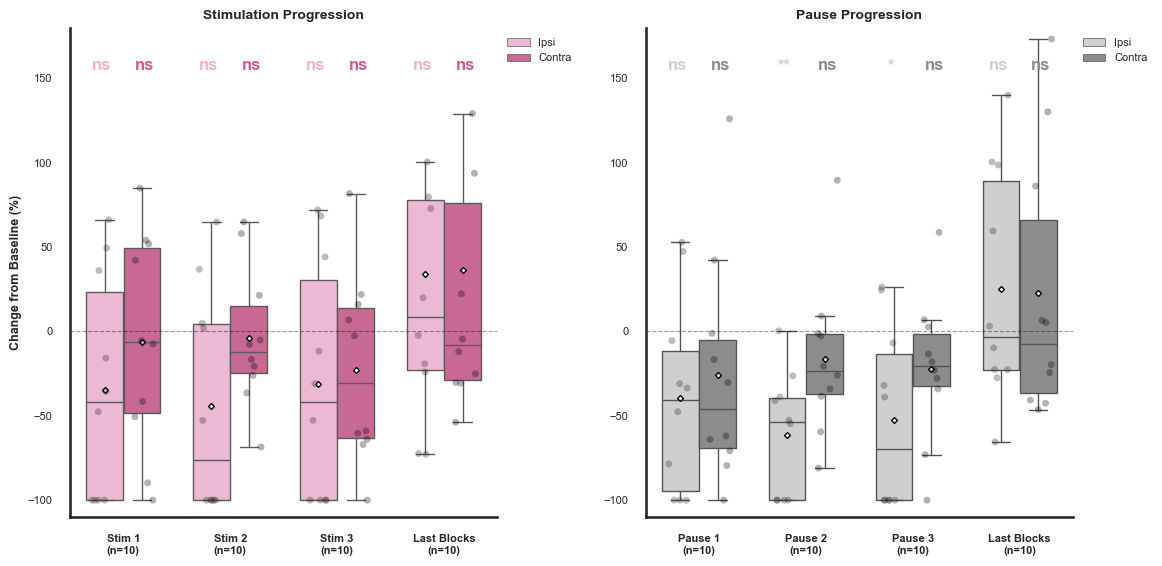

In [35]:
from scipy.stats import wilcoxon

def prepare_hemi_progression_data(hemi_type, block_type='stim'):
    all_subjects = []
    # שליפת הדאטה המתאים (ipsi או contra)
    raw_data = data_control['rates'][hemi_type]
    
    for name, subj_rates in zip(subject_ids, raw_data):
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        if block_type == 'stim':
            # בלוקים 1, 3, 5
            vals = subj_rates[1::2]
            stages = ['Stim 1', 'Stim 2', 'Stim 3', 'Last Blocks (mean)']
        else:
            # בלוקים 2, 4, 6
            vals = subj_rates[2::2]
            stages = ['Pause 1', 'Pause 2', 'Pause 3', 'Last Blocks (mean)']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        
        # בניה של השורה: 3 בלוקים ראשונים וממוצע השאר
        row = [pct_changes[0], pct_changes[1], pct_changes[2], 
               np.nanmean(pct_changes[3:]) if len(pct_changes) > 3 else np.nan]
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    
    # סינון IQR 3.0
    for col in df_wide.columns:
        Q1, Q3 = df_wide[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_wide.loc[(df_wide[col] < Q1 - 3*IQR) | (df_wide[col] > Q3 + 3*IQR), col] = np.nan
        
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Hemisphere'] = hemi_type.capitalize()
    return df_wide, df_long


def plot_combined_progression_final_v3():
    # יצירת פיגר רחב
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    sns.set_style("white")
    
    # גובה אחיד וגבוה יותר לסטטיסטיקה כדי למנוע דריסה
    y_stat_fixed = 155 
    
    def draw_on_ax(ax, block_type):
        hemi_types = ['ipsi', 'contra']
        df_list = []
        df_wide_dict = {}
        
        for h in hemi_types:
            df_w, df_l = prepare_hemi_progression_data(h, block_type)
            df_list.append(df_l)
            df_wide_dict[h.capitalize()] = df_w
            
        df_combined = pd.concat(df_list)
        
        if block_type == 'stim':
            pal = {'Ipsi': '#f4b1d2', 'Contra': '#d65a92'}
            title = "Stimulation Progression"
        else:
            pal = {'Ipsi': '#cfcfcf', 'Contra': '#8c8c8c'}
            title = "Pause Progression"
            
        # בוקספלוט
        sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Hemisphere',
                    palette=pal, width=0.7, fliersize=0, zorder=2, linewidth=1,
                    showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                               "markeredgecolor":"black", "markersize":3}, ax=ax)
        
        sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Hemisphere',
                      dodge=True, color='black', alpha=0.3, size=2.5, jitter=0.2, ax=ax, zorder=3, s=5)
        
        # --- סטטיסטיקה בגובה אחיד למעלה ---
        offsets = [-0.2, 0.2]
        current_stages = df_combined['Stage'].unique()
        
        for i, stage in enumerate(current_stages):
            for h_idx, h_name in enumerate(['Ipsi', 'Contra']):
                data = df_wide_dict[h_name][stage].dropna()
                if len(data) >= 5:
                    _, p = wilcoxon(data)
                    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                    ax.text(i + offsets[h_idx], y_stat_fixed, stars, ha='center', 
                            fontsize=12, fontweight='bold', color=pal[h_name])

        ax.axhline(0, color='black', linestyle='--', alpha=0.4, linewidth=0.8)
        
        # עיצוב צירים
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_ylabel("Change from Baseline (%)" if ax == ax1 else "", fontsize=9, fontweight='bold')
        
        # הסרת כותרת ציר X
        ax.set_xlabel("") 
        
        # תוויות X
        new_labels = []
        for stage in current_stages:
            n_val = df_wide_dict['Ipsi'][stage].dropna().count()
            label = stage.replace(" (mean)", "")
            new_labels.append(f"{label}\n(n={n_val})")
        ax.set_xticklabels(new_labels, fontsize=8, fontweight='bold')
        
        # הגדלת טווח ציר Y
        ax.set_ylim(-110, 180) 
        ax.set_yticks(np.arange(-100, 151, 50))
        ax.tick_params(labelsize=8)
        
        # מקרא מחוץ לגרף
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[:2], labels[:2], title=None, fontsize=8, 
                  frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
        sns.despine(ax=ax)

    draw_on_ax(ax1, 'stim')
    draw_on_ax(ax2, 'pause')
    
    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.show()

# הרצה
plot_combined_progression_final_v3()

In [18]:
import joblib
joblib.dump(for_avg_props_raw, 'for_avg_props_raw_stim_frontal.pkl')

['for_avg_props_raw_stim_frontal.pkl']

In [42]:
for subj_idx, subj in enumerate(subject_ids):
    print(f"  {subj}: {data_stim['rates']['all'][subj_idx][0]:.2f} spikes/min")


  485: 12.61 spikes/min
  486: 6.17 spikes/min
  487: 8.14 spikes/min
  488: 18.94 spikes/min
  497: 5.14 spikes/min
  498: 1.48 spikes/min
  499: 24.58 spikes/min
  505: 15.43 spikes/min
  5107: 2.21 spikes/min
  515: 9.53 spikes/min
  520: 0.67 spikes/min
  545: 24.91 spikes/min


In [44]:
for subj_idx, subj in enumerate(controls):
    print(f"  {subj}: {data_control['rates']['all'][subj_idx][0]:.2f} spikes/min")


  394: 26.06 spikes/min
  396: 4.90 spikes/min
  398: 5.02 spikes/min
  402: 1.65 spikes/min
  404: 0.93 spikes/min
  406: 2.83 spikes/min
  415: 8.42 spikes/min
  416: 1.79 spikes/min
  417: 22.74 spikes/min
  423: 4.82 spikes/min


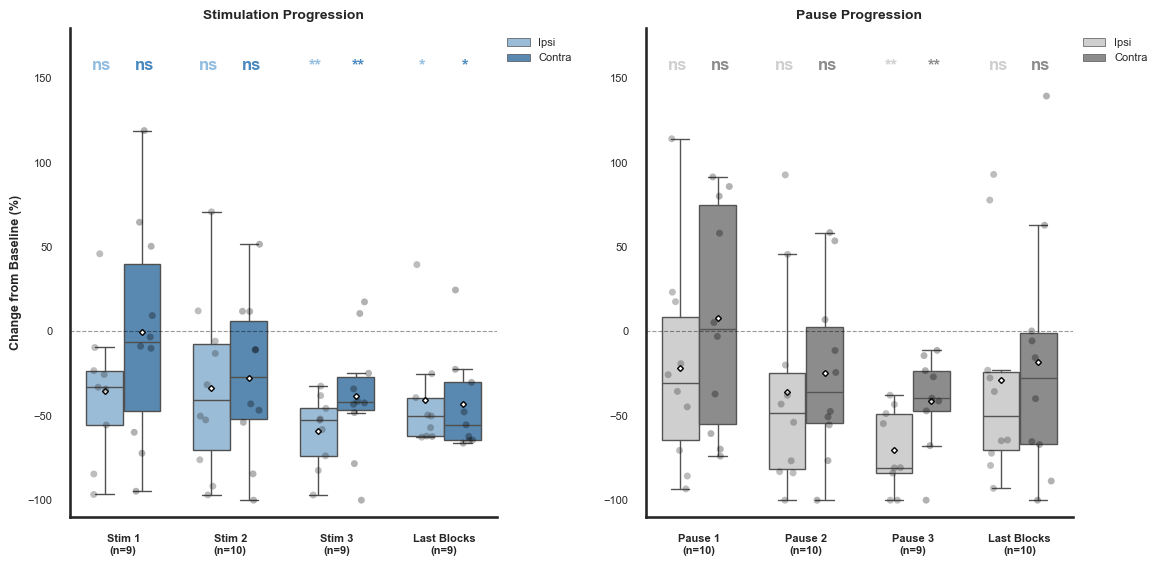

In [36]:
from scipy.stats import wilcoxon

def prepare_hemi_progression_data(hemi_type, block_type='stim'):
    all_subjects = []
    # שליפת הדאטה המתאים (ipsi או contra)
    raw_data = for_avg_props_raw['rates'][hemi_type]
    
    for name, subj_rates in zip(subject_ids, raw_data):
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        if block_type == 'stim':
            # בלוקים 1, 3, 5
            vals = subj_rates[1::2]
            stages = ['Stim 1', 'Stim 2', 'Stim 3', 'Last Blocks (mean)']
        else:
            # בלוקים 2, 4, 6
            vals = subj_rates[2::2]
            stages = ['Pause 1', 'Pause 2', 'Pause 3', 'Last Blocks (mean)']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        
        # בניה של השורה: 3 בלוקים ראשונים וממוצע השאר
        row = [pct_changes[0], pct_changes[1], pct_changes[2], 
               np.nanmean(pct_changes[3:]) if len(pct_changes) > 3 else np.nan]
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    
    # סינון IQR 3.0
    for col in df_wide.columns:
        Q1, Q3 = df_wide[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_wide.loc[(df_wide[col] < Q1 - 3*IQR) | (df_wide[col] > Q3 + 3*IQR), col] = np.nan
        
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Hemisphere'] = hemi_type.capitalize()
    return df_wide, df_long


def plot_combined_progression_final_v3():
    # יצירת פיגר רחב
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    sns.set_style("white")
    
    # גובה אחיד וגבוה יותר לסטטיסטיקה כדי למנוע דריסה
    y_stat_fixed = 155 
    
    def draw_on_ax(ax, block_type):
        hemi_types = ['ipsi', 'contra']
        df_list = []
        df_wide_dict = {}
        
        for h in hemi_types:
            df_w, df_l = prepare_hemi_progression_data(h, block_type)
            df_list.append(df_l)
            df_wide_dict[h.capitalize()] = df_w
            
        df_combined = pd.concat(df_list)
        
        if block_type == 'stim':
            pal = {'Ipsi': '#91bde1', 'Contra': '#4a89bf'}
            title = "Stimulation Progression"
        else:
            pal = {'Ipsi': '#cfcfcf', 'Contra': '#8c8c8c'}
            title = "Pause Progression"
            
        # בוקספלוט
        sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Hemisphere',
                    palette=pal, width=0.7, fliersize=0, zorder=2, linewidth=1,
                    showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                               "markeredgecolor":"black", "markersize":3}, ax=ax)
        
        sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Hemisphere',
                      dodge=True, color='black', alpha=0.3, size=2.5, jitter=0.2, ax=ax, zorder=3, s=5)
        
        # --- סטטיסטיקה בגובה אחיד למעלה ---
        offsets = [-0.2, 0.2]
        current_stages = df_combined['Stage'].unique()
        
        for i, stage in enumerate(current_stages):
            for h_idx, h_name in enumerate(['Ipsi', 'Contra']):
                data = df_wide_dict[h_name][stage].dropna()
                if len(data) >= 5:
                    _, p = wilcoxon(data)
                    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                    ax.text(i + offsets[h_idx], y_stat_fixed, stars, ha='center', 
                            fontsize=12, fontweight='bold', color=pal[h_name])

        ax.axhline(0, color='black', linestyle='--', alpha=0.4, linewidth=0.8)
        
        # עיצוב צירים
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_ylabel("Change from Baseline (%)" if ax == ax1 else "", fontsize=9, fontweight='bold')
        
        # הסרת כותרת ציר X
        ax.set_xlabel("") 
        
        # תוויות X
        new_labels = []
        for stage in current_stages:
            n_val = df_wide_dict['Ipsi'][stage].dropna().count()
            label = stage.replace(" (mean)", "")
            new_labels.append(f"{label}\n(n={n_val})")
        ax.set_xticklabels(new_labels, fontsize=8, fontweight='bold')
        
        # הגדלת טווח ציר Y
        ax.set_ylim(-110, 180) 
        ax.set_yticks(np.arange(-100, 151, 50))
        ax.tick_params(labelsize=8)
        
        # מקרא מחוץ לגרף
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[:2], labels[:2], title=None, fontsize=8, 
                  frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
        sns.despine(ax=ax)

    draw_on_ax(ax1, 'stim')
    draw_on_ax(ax2, 'pause')
    
    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.show()

# הרצה
plot_combined_progression_final_v3()

In [47]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. טעינת הנתונים
df = pd.read_csv('frontal_and_control_block_rates.csv')

# --- 2. שלב המיצוע (חדש) ---
# אנחנו מחשבים את ממוצע ה-rate עבור כל נבדק בכל סוג בלוק
# זה מבטיח שלכל נבדק יהיה משקל שווה במודל, ללא קשר למספר הבלוקים שביצע
df_subj = df.groupby(['subject_id', 'group_label', 'block_type'])['rate'].mean().reset_index()

# 3. הכנת הנתונים: הגדרת רמות ייחוס (Reference Levels)
# חשוב לבצע את זה על ה-DataFrame החדש (df_subj)
df_subj['group_label'] = pd.Categorical(df_subj['group_label'], categories=['control', 'stimulation'])
df_subj['block_type'] = pd.Categorical(df_subj['block_type'], categories=['pause_block', 'stimuli_block'])

# --- 4. בניית המודל ההיררכי על הממוצעים ---
# המודל כעת רץ על df_subj שבו יש פחות תצפיות (2 לכל נבדק)
model = smf.mixedlm("rate ~ group_label * block_type", df_subj, groups=df_subj["subject_id"])
result = model.fit()

# הדפסת סיכום המודל הסטטיסטי המעודכן
print(result.summary())

                              Mixed Linear Model Regression Results
Model:                          MixedLM               Dependent Variable:               rate     
No. Observations:               44                    Method:                           REML     
No. Groups:                     22                    Scale:                            2.8064   
Min. group size:                2                     Log-Likelihood:                   -122.6720
Max. group size:                2                     Converged:                        Yes      
Mean group size:                2.0                                                              
-------------------------------------------------------------------------------------------------
                                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------
Intercept                                         

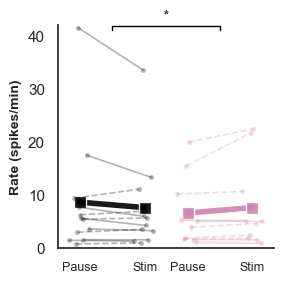

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

# הגדרות סגנון
sns.set_context("notebook", font_scale=1.0)
sns.set_style("white")
df = pd.read_csv('frontal_and_control_block_rates.csv')

# 1. הכנת נתונים
df_subj = (df[df.block_type.isin(['stimuli_block', 'pause_block'])]
           .groupby(['subject_id', 'group_label', 'block_type'])['rate']
           .mean()
           .unstack()
           .reset_index())

stim_grp = df_subj[df_subj.group_label == 'stimulation']
ctrl_grp = df_subj[df_subj.group_label == 'control']

# 2. יצירת הגרף
fig, ax = plt.subplots(figsize=(3,3)) # גובה מצומצם כפי שביקשת

c_stim = 'black'
c_ctrl = '#ce84ad'
jitter_val = 0.05 

def plot_enhanced_lines(data, x_base, color):
    # ציור הממוצע קודם (כדי שיהיה "מתחת" לנבדקים במידת הצורך)
    m_pause = data['pause_block'].mean()
    m_stim = data['stimuli_block'].mean()
    # zorder=3 - הממוצע נמצא באמצע
    ax.plot(x_base, [m_pause, m_stim], '-s', color=color, linewidth=4, 
            markersize=9, zorder=3, markeredgecolor='white', alpha=0.9)

    # ציור הנבדקים עם jitter ו-zorder גבוה יותר
    for _, row in data.iterrows():
        j = np.random.uniform(-jitter_val, jitter_val)
        x_pos = [x_base[0] + j, x_base[1] + j]
        
        ls = '-' if row['stimuli_block'] < row['pause_block'] else '--'
        # zorder=4 - הנבדקים מעל הממוצע
        ax.plot(x_pos, [row['pause_block'], row['stimuli_block']],
                linestyle=ls, marker='o', color=color, alpha=0.3, 
                linewidth=1.2, markersize=3.5, zorder=4, markeredgecolor='none')

# ציור הקבוצות
plot_enhanced_lines(stim_grp, [0, 0.3], c_stim)
plot_enhanced_lines(ctrl_grp, [0.5, 0.8], c_ctrl)

# 3. סוגר אינטראקציה
y_max = df_subj[['pause_block', 'stimuli_block']].max().max()
y_bracket = y_max * 1.01
ax.plot([0.15, 0.15, 0.65, 0.65], [y_bracket * 0.98, y_bracket, y_bracket, y_bracket * 0.98], 
        color='black', linewidth=1)
ax.text(0.4, y_bracket * 1.02, f'*', 
        ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. עיצוב צירים
ax.set_xticks([0, 0.3, 0.5, 0.8])
ax.set_xticklabels(['Pause', 'Stim', 'Pause', 'Stim'], fontsize=9)
ax.set_ylabel('Rate (spikes/min)', fontsize=10, fontweight='bold')
ax.set_xlim(-0.1, 0.9)
ax.set_ylim(0, 42)


# 5. מקרא
# legend_elements = [
#     Line2D([0], [0], color=c_stim, lw=2, label='Stim'),
#     Line2D([0], [0], color=c_ctrl, lw=2, label='Ctrl'),
#     Line2D([0], [0], color='gray', lw=1, ls='-', label='Decr'),
#     Line2D([0], [0], color='gray', lw=1, ls='--', label='Incr')
# ]
# ax.legend(handles=legend_elements, loc='upper right', fontsize=8, frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

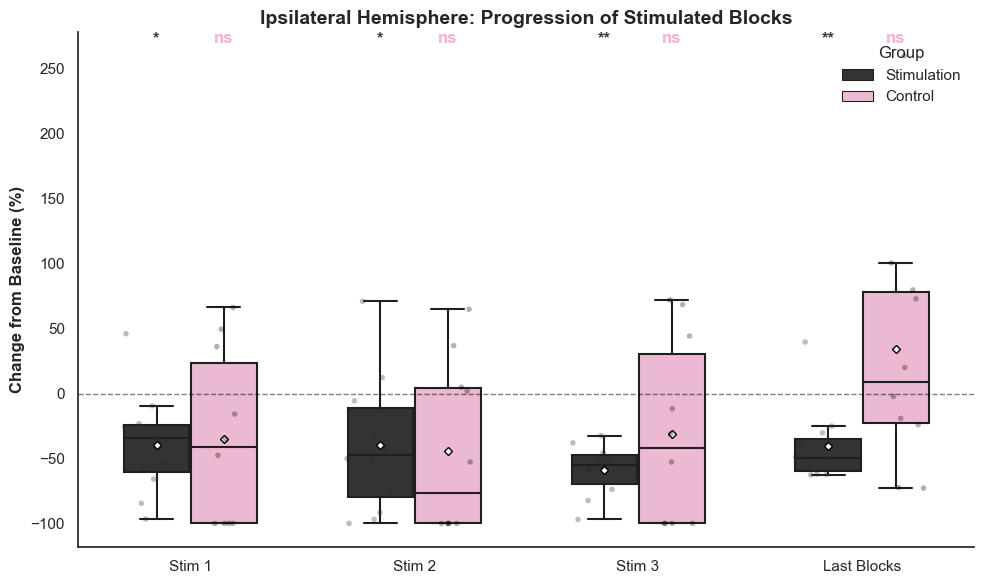

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon

def prepare_progression_single_hemi(data_source, group_name, hemi_type='ipsi'):
    all_subjects = []
    # שליפת הדאטה (מניח שקיים subject_ids גלובלי או מועבר)
    raw_data = data_source['rates'][hemi_type]
    
    for name, subj_rates in zip(subject_ids, raw_data):
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        # לוקחים רק את מקטעי הגירוי (1, 3, 5...)
        vals = subj_rates[1::2]
        stages = ['Stim 1', 'Stim 2', 'Stim 3', 'Last Blocks']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        
        # בניה של השורה: 3 בלוקים ראשונים וממוצע השאר
        row = [pct_changes[0], pct_changes[1], pct_changes[2], 
               np.nanmean(pct_changes[3:]) if len(pct_changes) > 3 else np.nan]
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    
    # סינון IQR 3.0
    for col in df_wide.columns:
        Q1, Q3 = df_wide[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_wide.loc[(df_wide[col] < Q1 - 3*IQR) | (df_wide[col] > Q3 + 3*IQR), col] = np.nan
        
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Group'] = group_name
    return df_wide, df_long

def plot_ipsi_progression_comparison():
    # 1. הכנת נתונים משתי הקבוצות (רק איפסי)
    df_wide_stim, df_long_stim = prepare_progression_single_hemi(data_stim, 'Stimulation', 'ipsi')
    df_wide_ctrl, df_long_ctrl = prepare_progression_single_hemi(data_control, 'Control', 'ipsi')
    
    df_combined = pd.concat([df_long_stim, df_long_ctrl])
    
    # 2. הגדרות עיצוב
    plt.figure(figsize=(10, 6))
    sns.set_style("white")
    
    # פלטה: שחור לגירוי, ורוד לקונטרול
    pal = {'Stimulation': '#333333', 'Control': '#f4b1d2'}
    
    # 3. ציור הבוקספלוט (שני בוקסים לכל שלב)
    ax = sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                     palette=pal, width=0.6, fliersize=0, zorder=2, linewidth=1.5,
                     showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                                "markeredgecolor":"black", "markersize":4})
    
    # הוספת נקודות גולמיות (Jitter)
    sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                  dodge=True, color='black', alpha=0.3, size=4, jitter=0.2, zorder=3)

    # 4. סטטיסטיקה (מבחן Wilcoxon מול הבייסליין לכל קבוצה בנפרד)
    y_stat = df_combined['Change_Percent'].max() + 10
    stages = df_combined['Stage'].unique()
    offsets = [-0.15, 0.15] # הזזה שמאלה לגירוי וימינה לקונטרול
    
    for i, stage in enumerate(stages):
        # סטטיסטיקה לגירוי
        d_stim = df_wide_stim[stage].dropna()
        if len(d_stim) >= 5:
            _, p = wilcoxon(d_stim)
            star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            plt.text(i + offsets[0], y_stat, star, ha='center', fontweight='bold', color=pal['Stimulation'])
            
        # סטטיסטיקה לקונטרול
        d_ctrl = df_wide_ctrl[stage].dropna()
        if len(d_ctrl) >= 5:
            _, p = wilcoxon(d_ctrl)
            star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            plt.text(i + offsets[1], y_stat, star, ha='center', fontweight='bold', color=pal['Control'])

    # 5. עיצוב סופי
    plt.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    plt.title("Ipsilateral Hemisphere: Progression of Stimulated Blocks", fontsize=14, fontweight='bold')
    plt.ylabel("Change from Baseline (%)", fontsize=12, fontweight='bold')
    plt.xlabel("")
    
    # הסרת כפילויות במקרא מה-stripplot
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[:2], labels[:2], title="Group", frameon=False, loc='upper right')
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_ipsi_progression_comparison()

--- Statistics for STIM Progression ---
Stim 1 - Between Groups p: 0.8047
Stim 2 - Between Groups p: 0.4638
Stim 3 - Between Groups p: 0.7328
Last Blocks - Between Groups p: 0.0448


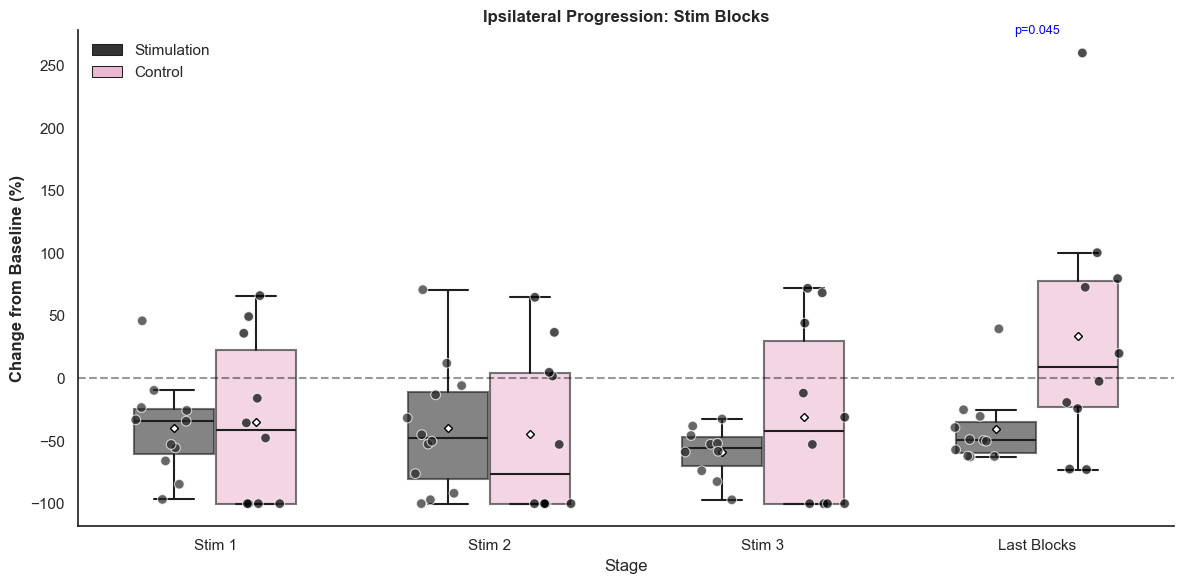

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, mannwhitneyu

# פונקציה מתוקנת ששומרת על הלוגיקה המקורית שלך
def prepare_final_data(data_source, hemi_type='ipsi', block_type='stim', group_label='Group'):
    all_subjects = []
    raw_data = data_source['rates'][hemi_type]
    
    for name, subj_rates in zip(subject_ids, raw_data):
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        if block_type == 'stim':
            vals = subj_rates[1::2]
            stages = ['Stim 1', 'Stim 2', 'Stim 3', 'Last Blocks']
        else:
            vals = subj_rates[2::2]
            stages = ['Pause 1', 'Pause 2', 'Pause 3', 'Last Blocks']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        row = [pct_changes[0], pct_changes[1], pct_changes[2], 
               np.nanmean(pct_changes[3:]) if len(pct_changes) > 3 else np.nan]
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    # סינון IQR 3.0 כפי שהיה לך
    for col in df_wide.columns:
        Q1, Q3 = df_wide[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_wide.loc[(df_wide[col] < Q1 - 3*IQR) | (df_wide[col] > Q3 + 3*IQR), col] = np.nan
        
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Group'] = group_label
    return df_wide, df_long

def plot_final_comparison(block_to_plot='stim'):
    # טעינת הנתונים מחדש לשתי הקבוצות - רק איפסי
    df_w_stim, df_l_stim = prepare_final_data(data_stim, 'ipsi', block_to_plot, 'Stimulation')
    df_w_ctrl, df_l_ctrl = prepare_final_data(data_control, 'ipsi', block_to_plot, 'Control')
    
    df_combined = pd.concat([df_l_stim, df_l_ctrl])
    
    plt.figure(figsize=(12, 6))
    sns.set_style("white")
    
    # צבעים: שחור לגירוי, ורוד לקונטרול
    pal = {'Stimulation': '#333333', 'Control': '#f4b1d2'}
    
    # בוקספלוט עם שקיפות כדי שהנקודות ייראו
    ax = sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                     palette=pal, width=0.6, fliersize=0, zorder=2,
                     boxprops=dict(alpha=0.6), # שקיפות הבוקס
                     showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                                "markeredgecolor":"black", "markersize":4})
    
    # נקודות גדולות יותר עם מסגרת לבנה למניעת "היבלעות" בשחור
    sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                  dodge=True, color='black', alpha=0.7, size=7, jitter=0.2, zorder=3,
                  linewidth=0.8, edgecolor='white')

    # סטטיסטיקה
    stages = df_combined['Stage'].unique()
    y_max = df_combined['Change_Percent'].max()
    
    print(f"--- Statistics for {block_to_plot.upper()} Progression ---")
    for i, stage in enumerate(stages):
        d_s = df_w_stim[stage].dropna()
        d_c = df_w_ctrl[stage].dropna()
        
        # מבחן בין קבוצות
        if len(d_s) > 0 and len(d_c) > 0:
            _, p_bet = mannwhitneyu(d_s, d_c)
            print(f"{stage} - Between Groups p: {p_bet:.4f}")
            if p_bet < 0.05:
                plt.text(i, y_max + 15, f"p={p_bet:.3f}", ha='center', color='blue', fontsize=9)

    plt.axhline(0, color='black', linestyle='--', alpha=0.4)
    plt.ylabel("Change from Baseline (%)", fontweight='bold')
    plt.title(f"Ipsilateral Progression: {block_to_plot.capitalize()} Blocks", fontweight='bold')
    
    # ניקוי מקרא
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[:2], labels[:2], frameon=False)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה על מקטעי הגירוי
plot_final_comparison('stim')

--------------------------------------------------
BETWEEN-GROUP COMPARISON (Stim vs Ctrl)
--------------------------------------------------
Stim 1: p-value (Stim vs Ctrl) = 0.8047
Stim 2: p-value (Stim vs Ctrl) = 0.4638
Stim 3: p-value (Stim vs Ctrl) = 0.7328
Last Blocks: p-value (Stim vs Ctrl) = 0.0448


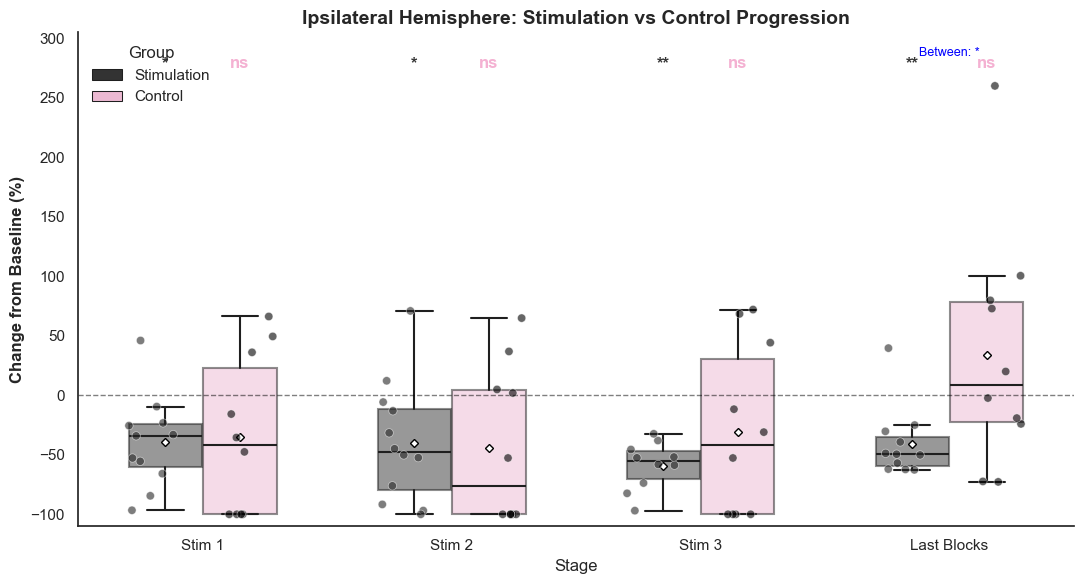

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, mannwhitneyu

def plot_ipsi_progression_comparison_v2():
    # 1. הכנת נתונים
    df_wide_stim, df_long_stim = prepare_progression_single_hemi(data_stim, 'Stimulation', 'ipsi')
    df_wide_ctrl, df_long_ctrl = prepare_progression_single_hemi(data_control, 'Control', 'ipsi')
    df_combined = pd.concat([df_long_stim, df_long_ctrl])
    
    plt.figure(figsize=(11, 6))
    sns.set_style("white")
    
    # פלטה: שחור שקוף וורוד פסטל
    pal = {'Stimulation': '#333333', 'Control': '#f4b1d2'}
    
    # 2. ציור הבוקספלוט עם שקיפות (alpha) גבוהה יותר לבוקסים
    ax = sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                     palette=pal, width=0.6, fliersize=0, zorder=2, linewidth=1.5,
                     boxprops=dict(alpha=0.5), # הופך את הבוקס לשקוף כדי לראות את הנקודות
                     showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                                "markeredgecolor":"black", "markersize":4})
    
    # 3. הוספת נקודות גדולות ובולטות יותר (Stripplot)
    sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                  dodge=True, color='black', alpha=0.6, size=6, jitter=0.2, zorder=3,
                  linewidth=0.5, edgecolor='white') # מסגרת לבנה לנקודות

    # 4. סטטיסטיקה והדפסה
    y_stat_top = df_combined['Change_Percent'].max() + 15
    stages = ['Stim 1', 'Stim 2', 'Stim 3', 'Last Blocks']
    offsets = [-0.15, 0.15]
    
    print("-" * 50)
    print("BETWEEN-GROUP COMPARISON (Stim vs Ctrl)")
    print("-" * 50)

    for i, stage in enumerate(stages):
        d_stim = df_wide_stim[stage].dropna()
        d_ctrl = df_wide_ctrl[stage].dropna()
        
        # א. מבחן בין הקבוצות (Mann-Whitney)
        if len(d_stim) >= 3 and len(d_ctrl) >= 3:
            u_stat, p_between = mannwhitneyu(d_stim, d_ctrl)
            print(f"{stage}: p-value (Stim vs Ctrl) = {p_between:.4f}")
            
            # הוספת סימון בין הקבוצות בגרף (אם תרצי קו מחבר)
            if p_between < 0.05:
                star_b = '*' if p_between < 0.05 else '**'
                plt.text(i, y_stat_top + 10, f"Between: {star_b}", ha='center', fontsize=9, color='blue')

        # ב. מבחן בתוך כל קבוצה (Wilcoxon מול 0)
        for idx, (data, grp_name) in enumerate([(d_stim, 'Stimulation'), (d_ctrl, 'Control')]):
            if len(data) >= 5:
                _, p_within = wilcoxon(data)
                star_w = '***' if p_within < 0.001 else '**' if p_within < 0.01 else '*' if p_within < 0.05 else 'ns'
                plt.text(i + offsets[idx], y_stat_top, star_w, ha='center', fontweight='bold', color=pal[grp_name])

    # 5. עיצוב סופי
    plt.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    plt.title("Ipsilateral Hemisphere: Stimulation vs Control Progression", fontsize=14, fontweight='bold')
    plt.ylabel("Change from Baseline (%)", fontsize=12, fontweight='bold')
    plt.ylim(df_combined['Change_Percent'].min() - 10, y_stat_top + 30)
    
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[:2], labels[:2], title="Group", frameon=False)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_ipsi_progression_comparison_v2()

--- Statistics for STIM ---
Stim 1 - Between Groups p: 0.8047
Stim 2 - Between Groups p: 0.4638
Stim 3 - Between Groups p: 0.7328
Last Blocks - Between Groups p: 0.0448


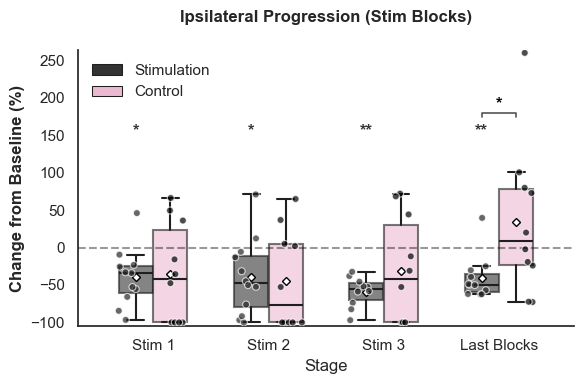

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, mannwhitneyu

def plot_final_comparison_with_brackets(block_to_plot='stim'):
    # 1. הכנת הנתונים (מבוסס על prepare_final_data מהשלב הקודם)
    df_w_stim, df_l_stim = prepare_final_data(data_stim, 'ipsi', block_to_plot, 'Stimulation')
    df_w_ctrl, df_l_ctrl = prepare_final_data(data_control, 'ipsi', block_to_plot, 'Control')
    df_combined = pd.concat([df_l_stim, df_l_ctrl])
    
    plt.figure(figsize=(6, 4))
    sns.set_style("white")
    
    pal = {'Stimulation': '#333333', 'Control': '#f4b1d2'}
    
    # 2. ציור הבוקספלוט
    ax = sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                     palette=pal, width=0.6, fliersize=0, zorder=2,
                     boxprops=dict(alpha=0.6), 
                     showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                                "markeredgecolor":"black", "markersize":4})
    
    # 3. נקודות דגימה בולטות
    sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                  dodge=True, color='black', alpha=0.7, size=5, jitter=0.2, zorder=3,
                  linewidth=0.8, edgecolor='white')

    # 4. הגדרות גובה לסטטיסטיקה
    y_within = 150 # גובה כוכביות מול בייסליין
    y_between_start = 175 # גובה התחלה לסוגר בין קבוצות
    stages = df_combined['Stage'].unique()
    offsets = [-0.15, 0.15]
    
    print(f"--- Statistics for {block_to_plot.upper()} ---")
    for i, stage in enumerate(stages):
        d_s = df_w_stim[stage].dropna()
        d_c = df_w_ctrl[stage].dropna()
        
        # א. סטטיסטיקה בתוך קבוצה (מול 0) - בגובה 150
        for idx, (data, grp_name) in enumerate([(d_s, 'Stimulation'), (d_c, 'Control')]):
            if len(data) >= 5:
                _, p_w = wilcoxon(data)
                if p_w < 0.05:
                    star_w = '***' if p_w < 0.001 else '**' if p_w < 0.01 else '*'
                    plt.text(i + offsets[idx], y_within, star_w, ha='center', 
                             fontweight='bold', color=pal[grp_name], fontsize=12)

        # ב. סטטיסטיקה בין קבוצות + קו מחבר
        if len(d_s) > 0 and len(d_c) > 0:
            _, p_bet = mannwhitneyu(d_s, d_c)
            print(f"{stage} - Between Groups p: {p_bet:.4f}")
            
            if p_bet < 0.05:
                star_b = '***' if p_bet < 0.001 else '**' if p_bet < 0.01 else '*'
                # ציור הסוגר (Bracket)
                x1, x2 = i + offsets[0], i + offsets[1]
                h = 5 # גובה ה"כתפיים" של הסוגר
                plt.plot([x1, x1, x2, x2], [y_between_start, y_between_start+h, y_between_start+h, y_between_start], 
                         lw=1.2, color='#555555')
                plt.text((x1+x2)/2, y_between_start + h + 2, star_b, ha='center', 
                         va='bottom', color='black', fontweight='bold', fontsize=12)

    # 5. עיצוב צירים ומקרא
    plt.axhline(0, color='black', linestyle='--', alpha=0.4)
    plt.ylim(-105, 264) # הגדלת הטווח כדי שיהיה מקום לסוגרים
    plt.ylabel("Change from Baseline (%)", fontweight='bold')
    plt.title(f"Ipsilateral Progression ({block_to_plot.capitalize()} Blocks)", fontweight='bold', pad=20)
    
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[:2], labels[:2], frameon=False, loc='upper left')
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_final_comparison_with_brackets('stim')

In [17]:
import numpy as np

# בדיקה עבור האיבר הראשון ברשימה
print(np.mean(data_stim['rates']['all'][0]))
print(np.mean(for_avg_props_raw['rates']['all'][0]))

5.503293474468573
5.503293474468573


In [19]:
import numpy as np

# בדיקה עבור האיבר הראשון ברשימה
print(len(data_stim['rates']['all']))
print(len(for_avg_props_raw['rates']['all']))

10
10


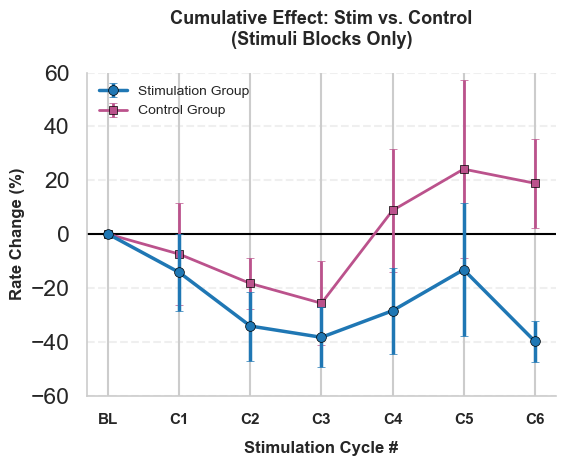

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד נתונים עבור קבוצת הגירוי ---
df_cum_stim = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
mean_stim = df_cum_stim.mean()
sem_stim = df_cum_stim.sem()

# --- 2. עיבוד נתונים עבור קבוצת הקונטרול ---
df_cum_ctrl = get_clean_matrix(data_control['rates']['all'], mode='baseline')
mean_ctrl = df_cum_ctrl.mean()
sem_ctrl = df_cum_ctrl.sem()

# --- 3. שליפת זמני הגירוי בלבד (אינדקסים 1, 3, 5, 7) ---
stim_idx = [1, 3, 5, 7, 9, 11] # אינדקסים של בלוקי הגירוי בתוך המטריצה

# פונקציה להכנת הקו (הוספת 0 של ה-BL בהתחלה)
def prepare_group_line(mean_s, sem_s, idx_list):
    y = [0] + mean_s.iloc[idx_list].tolist()
    err = [0] + sem_s.iloc[idx_list].tolist()
    return y, err

y_stim, err_stim = prepare_group_line(mean_stim, sem_stim, stim_idx)
y_ctrl, err_ctrl = prepare_group_line(mean_ctrl, sem_ctrl, stim_idx)

# ציר X (BL ואז מחזורים 1 עד 4)
x_axis = np.arange(len(y_stim))

# --- 4. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(6, 5))

# הגדרות סטייל
stim_color = '#1f77b4' # כחול חזק לקבוצת הגירוי
ctrl_color = '#bb528c' # אפור לקבוצת הביקורת

style_stim = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 7, 'linewidth': 2.5, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
style_ctrl = {'fmt': '-s', 'color': ctrl_color, 'ecolor': ctrl_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markerfacecolor': '#bb528c', 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

# ציור הקווים
ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation Group', zorder=5, **style_stim)
ax.errorbar(x_axis, y_ctrl, yerr=err_ctrl, label='Control Group', zorder=4, **style_ctrl)

# קו אפס שחור
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)

# עיצוב צירים
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# הגדרות Y
ax.set_yticks(np.arange(-60, 80, 20))
ax.set_ylim(-60, 60)
ax.set_ylabel('Rate Change (%)', fontsize=12, fontweight='bold')

# הגדרות X
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6'], fontsize=11, fontweight='bold')
ax.set_xlabel('Stimulation Cycle #', fontsize=12, fontweight='bold', labelpad=10)

ax.set_title('Cumulative Effect: Stim vs. Control\n(Stimuli Blocks Only)', fontsize=13, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

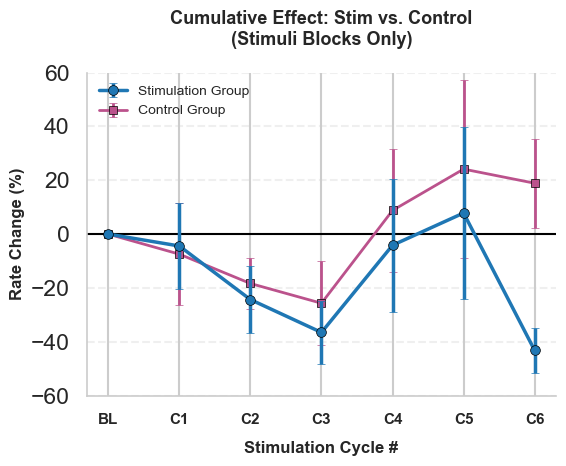

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד נתונים עבור קבוצת הגירוי ---
df_cum_stim = get_clean_matrix(for_avg_props_raw['rates']['all'], mode='baseline')
mean_stim = df_cum_stim.mean()
sem_stim = df_cum_stim.sem()

# --- 2. עיבוד נתונים עבור קבוצת הקונטרול ---
df_cum_ctrl = get_clean_matrix(data_control['rates']['all'], mode='baseline')
mean_ctrl = df_cum_ctrl.mean()
sem_ctrl = df_cum_ctrl.sem()

# --- 3. שליפת זמני הגירוי בלבד (אינדקסים 1, 3, 5, 7) ---
stim_idx = [1, 3, 5, 7, 9, 11] # אינדקסים של בלוקי הגירוי בתוך המטריצה

# פונקציה להכנת הקו (הוספת 0 של ה-BL בהתחלה)
def prepare_group_line(mean_s, sem_s, idx_list):
    y = [0] + mean_s.iloc[idx_list].tolist()
    err = [0] + sem_s.iloc[idx_list].tolist()
    return y, err

y_stim, err_stim = prepare_group_line(mean_stim, sem_stim, stim_idx)
y_ctrl, err_ctrl = prepare_group_line(mean_ctrl, sem_ctrl, stim_idx)

# ציר X (BL ואז מחזורים 1 עד 4)
x_axis = np.arange(len(y_stim))

# --- 4. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(6, 5))

# הגדרות סטייל
stim_color = '#1f77b4' # כחול חזק לקבוצת הגירוי
ctrl_color = '#bb528c' # אפור לקבוצת הביקורת

style_stim = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 7, 'linewidth': 2.5, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
style_ctrl = {'fmt': '-s', 'color': ctrl_color, 'ecolor': ctrl_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markerfacecolor': '#bb528c', 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

# ציור הקווים
ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation Group', zorder=5, **style_stim)
ax.errorbar(x_axis, y_ctrl, yerr=err_ctrl, label='Control Group', zorder=4, **style_ctrl)

# קו אפס שחור
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)

# עיצוב צירים
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# הגדרות Y
ax.set_yticks(np.arange(-60, 80, 20))
ax.set_ylim(-60, 60)
ax.set_ylabel('Rate Change (%)', fontsize=12, fontweight='bold')

# הגדרות X
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6'], fontsize=11, fontweight='bold')
ax.set_xlabel('Stimulation Cycle #', fontsize=12, fontweight='bold', labelpad=10)

ax.set_title('Cumulative Effect: Stim vs. Control\n(Stimuli Blocks Only)', fontsize=13, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
stim_side_right = ['485', '487', '489', '490', '496', '497', '5101', '5107', '515', '520', '538', '544', '545',
                       '396', '398', '404', '406', '415']
controls = ['394', '396', '398', '402', '404', '406', '415', '416', '417', '423']
plot_legend = ['all', 'ipsi', 'contra', 'frontal', 'temporal']
frontal_chans = [f"{side}{string}{number}" for string in ['OF', 'AC', 'AF', 'FA', 'IF-dAC', 'OPR'] for number in range(1, 9) for side in ['R', 'L']]
temporal_chans = [f"{string}{number}" for string in ['RA', 'LA', 'RAH', 'LAH', 'RMH', 'LMH', 'REC', 'LEC', 'RPHG', 'LPHG'] for number in range(1, 9)]
feat_path = r'D:\Ofer_backup\V6_model\p%s\unichannel_model\min_amplitude_1\features\p%s_flat_features.csv'
curr_run_subjects = ['515', '545']
is_control = curr_run_subjects == controls
for_avg_props = {}
for_avg_props_raw = {} 
baselines = [] 
base_relative = True

scaler = StandardScaler()
def get_subj_data(subj):
    df = pd.read_csv(feat_path % (subj, subj))

    # נוסיף גם timestamp + channel
    cols = ["timestamp", "channel", "amplitude", "duration", "group", "group_event_duration", "group_event_size",
            "group_event_deepest",
            "group_event_shallowest", "group_event_spatial_spread", "stimuli_flag", "hypnogram_flag", "angle",
            "relative_spike_amplitude", "relative_spike_duration"]
    df = df[cols].copy()

    # רק NREM
    # df = df[df["hypnogram_flag"] == "nrem"]
    df = df.drop_duplicates(subset="group", keep="first")

    # סינון דגימות מלוכלכות לפי קובץ הארטיפקטים של אותו נבדק
    ann_path = fr"D:\Maya\clean Stim Project\P{subj}\P{subj}_annotations_ms.csv"
    df = utils.remove_noisy_samples_and_channels(subj, df, ann_path, ts_col="timestamp", channel_col="channel")

    df["subject_id"] = subj
    return df


def init_dicts_with_baseline_rates(subj_features, nrem_start, stim_start, side):
    baseline_minutes = (stim_start - nrem_start) / 60
    baselines.append(baseline_minutes)
    # if there is no sleep before first stim (515, 545)
    # TODO: remove 515 and 545?! maybe avg across all
    if baseline_minutes < 0:
        # take 10 minutes before stimuli as baseline
        baseline = subj_features[(subj_features['timestamp'] > (stim_start - 10 * 60) * 1000) &
                                 (subj_features['timestamp'] < stim_start * 1000)]
        baseline_minutes = 10
    else:
        # take epochs after sleep onset but before first stimuli as baseline
        # baseline = subj_features[subj_features['stimuli_flag'] == 'before_first_stimuli_session']
        baseline = subj_features[(subj_features['stimuli_flag'] == 'before_first_stimuli_session') & (
                    subj_features['timestamp'] > nrem_start * 1000)]
    # נסדר לפי זמן כדי שה"שורה הראשונה" תהיה באמת הכי מוקדמת בזמן
    baseline = baseline.sort_values('timestamp')
    # לקחת שורה ראשונה לכל group
    baseline_groups = baseline.groupby('group', as_index=False).first()

    base_rate = len(baseline_groups) / baseline_minutes
    rates = {'all': [base_rate],
             'ipsi': [len(baseline_groups[baseline_groups['channel'].str[0] == side]) / baseline_minutes],
             'contra': [len(baseline_groups[baseline_groups['channel'].str[0] != side]) / baseline_minutes],
             'frontal': [len(baseline_groups[baseline_groups['channel'].isin(frontal_chans)]) / baseline_minutes],
             'temporal': [len(baseline_groups[baseline_groups['channel'].isin(temporal_chans)]) / baseline_minutes]}
    props = {'rates': rates}
    for prop in ['relative_spike_amplitude', 'relative_spike_duration', 'group_event_size',
                 'group_event_spatial_spread']:
        if 'group' in prop:
            baseline_prop = baseline_groups
        else:
            baseline_prop = baseline
        curr = {'all': [np.mean(baseline_prop[prop])],
                'ipsi': [np.mean(baseline_prop[baseline_prop['channel'].str[0] == side][prop])],
                'contra': [np.mean(baseline_prop[baseline_prop['channel'].str[0] != side][prop])],
                'frontal': [np.mean(baseline_prop[baseline_prop['channel'].isin(frontal_chans)][prop])],
                'temporal': [np.mean(baseline_prop[baseline_prop['channel'].isin(temporal_chans)][prop])]}
        props[prop] = curr

    n_chans = {'all': subj_features['channel'].nunique(),
               'ipsi': subj_features[subj_features['channel'].str[0] == side]['channel'].nunique(),
               'contra': subj_features[subj_features['channel'].str[0] != side]['channel'].nunique(),
               'frontal': subj_features[subj_features['channel'].isin(frontal_chans)]['channel'].nunique(),
               'temporal': subj_features[subj_features['channel'].isin(temporal_chans)]['channel'].nunique()}
    return props, n_chans


def append_to_props(props, curr_df, side, time):
    # rates
    groups_df = curr_df.groupby('group', as_index=False).first()
    props['rates']['all'].append(len(groups_df) / time)
    props['rates']['ipsi'].append(len(groups_df[groups_df['channel'].str[0] == side]) / time)
    props['rates']['contra'].append(len(groups_df[groups_df['channel'].str[0] != side]) / time)
    props['rates']['frontal'].append(len(groups_df[groups_df['channel'].isin(frontal_chans)]) / time)
    props['rates']['temporal'].append(len(groups_df[groups_df['channel'].isin(temporal_chans)]) / time)
    # props
    for prop in ['relative_spike_amplitude', 'relative_spike_duration', 'group_event_size',
                 'group_event_spatial_spread']:
        if 'group' in prop:
            df = groups_df
        else:
            df = curr_df
        props[prop]['all'].append(np.mean(df[prop]))
        props[prop]['ipsi'].append(np.mean(df[df['channel'].str[0] == side][prop]))
        props[prop]['contra'].append(np.mean(df[df['channel'].str[0] != side][prop]))
        props[prop]['frontal'].append(np.mean(df[df['channel'].isin(frontal_chans)][prop]))
        props[prop]['temporal'].append(np.mean(df[df['channel'].isin(temporal_chans)][prop]))



# with and without norm
for subj in curr_run_subjects:  # for now removing 515 and 545 because they don't have baseline before stimuli
    stim_side = 'R' if subj in stim_side_right else 'L'
    final_features = get_subj_data(subj)
    if is_control:
        nrem_epochs = utils.get_control_nrem_epochs(subj)
        # remove first 30 minutes for control (like we started recording 30 min after sleep onset)
        final_features = final_features[(final_features['timestamp'] > (nrem_epochs[0][0] + 30 * 60) * 1000)]
        # initiate all data to new time zero for stimuli timings
        final_features['timestamp'] = final_features['timestamp'] - ((nrem_epochs[0][0] + 30 * 60) * 1000)
        nrem_epochs_unreal, nrem_stim_epochs, stim_epochs = utils.get_nrem_epochs(utils.control_stim[subj])
    else:
        nrem_epochs, nrem_stim_epochs, stim_epochs = utils.get_nrem_epochs(subj)
    props, n_chans = init_dicts_with_baseline_rates(final_features, nrem_epochs[0][0], stim_epochs[0][0], stim_side)

    for i, (start, end) in enumerate(stim_epochs):
        stim_block = final_features[
            (final_features['timestamp'] > start * 1000) & (final_features['timestamp'] < end * 1000)]
        stim_minutes = (end - start) / 60
        append_to_props(props, stim_block, stim_side, stim_minutes)
        if i + 1 < len(stim_epochs):
            pause_block = final_features[(final_features['timestamp'] > end * 1000) & (
                        final_features['timestamp'] < stim_epochs[i + 1][0] * 1000)]
            pause_minutes = (stim_epochs[i + 1][0] - end) / 60
            append_to_props(props, pause_block, stim_side, pause_minutes)
        else:
            # for now using only 5 minutes after last stimuli
            after = final_features[
                (final_features['timestamp'] > end * 1000) & (final_features['timestamp'] < (end + 60 * 5) * 1000)]
            append_to_props(props, after, stim_side, 5)

    # plot the spike rate in each epoch here
    for prop in props.keys():
        if prop not in for_avg_props.keys():
            for_avg_props[prop] = {legend: [] for legend in props[prop].keys()}
        if prop not in for_avg_props_raw.keys():
            for_avg_props_raw[prop] = {legend: [] for legend in props[prop].keys()}
        for (legend, curr_rates) in props[prop].items():
            if legend in plot_legend:
                if base_relative:
                    baseline_val = curr_rates[0] if curr_rates[0] != 0 else 1e-9  # מניעת חלוקה באפס
                    norm = [(x - baseline_val) / baseline_val for x in curr_rates]
                else:
                    norm = scaler.fit_transform(np.array(curr_rates).reshape(-1, 1)).flatten()
                for_avg_props[prop][legend].append(norm)
                for_avg_props_raw[prop][legend].append(curr_rates)

joblib.dump(for_avg_props_raw, 'no_base_515_545.pkl')

['no_base_515_545.pkl']

In [29]:
len(data_stim['rates']['all'])

13

In [37]:
stim_pkl = joblib.load('for_avg_props_raw_stim.pkl')
len(stim_pkl['rates']['all'])

13

In [38]:
# 1. הרשימה המלאה המקורית (15 נבדקים)
subjects_orig = ['485', '486', '487', '488', '489', '496', '497', '498', '499', '505', '5107', '515', '520', '538', '545']

# 2. הנבדקים שבאמת קיימים בנתונים (13 נבדקים - הורדנו את 545 ו-515)
subjects_in_data = [s for s in subjects_orig if s not in ['515', '545']]

# 3. הרשימה הסופית שאתה רוצה להשאיר (לפי הבקשה הקודמת שלך)
subjects_final = ['485', '486', '487', '488', '497', '498', '499', '505', '5107', '515', '520', '545']
# הערה: מכיוון ש-515 ו-545 לא קיימים בנתונים, הם יוסרו אוטומטית בתהליך הבא.

# 4. ביצוע הסינון
keep_set = set(subjects_final)

for feature in stim_pkl:
    for location in stim_pkl[feature]:
        current_list = stim_pkl[feature][location]
        new_list = []
        
        # רצים על הרשימה הקיימת (באורך 13) ומצמידים לה את השמות מ-subjects_in_data
        for i in range(len(current_list)):
            subj_name = subjects_in_data[i]
            if subj_name in keep_set:
                new_list.append(current_list[i])
        
        # עדכון המבנה
        stim_pkl[feature][location] = new_list

print(f"Done! New length of lists: {len(stim_pkl['rates']['all'])}")

Done! New length of lists: 10


In [41]:
import pandas as pd

# רשימת המזהים לפי סדר הופעתם ב-data_stim
subject_ids = ['485', '486', '487', '488', '497', '498', '499', '505', '5107', '520']

def create_wide_df(data_list, ids):
    # מציאת אורך הבלוקים המקסימלי לצורך יצירת העמודות
    max_len = max(len(sub) for sub in data_list)
    cols = ['BL'] + [f'Block_{i}' for i in range(1, max_len)]
    
    # יצירת ה-DataFrame
    df = pd.DataFrame(data_list, columns=cols)
    # הוספת עמודת מזהה הנבדק בתחילת הטבלה
    df.insert(0, 'Subject_ID', ids)
    return df

# יצירת ה-DFs (בהנחה ש-stim_pkl קיים אצלך)
df_rates = create_wide_df(stim_pkl['rates']['all'], subject_ids)
df_rates


# שמירה לקבצים
# df_rates.to_csv('subject_firing_rates_wide.csv', index=False)
# df_amp.to_csv('subject_amplitudes_wide.csv', index=False)

,Subject_ID,BL,Block_1,Block_2,Block_3,Block_4,Block_5,Block_6,Block_7,Block_8,...,Block_21,Block_22,Block_23,Block_24,Block_25,Block_26,Block_27,Block_28,Block_29,Block_30
0,485,12.610973,5.796996,7.005146,2.921098,2.064271,3.434616,7.596021,4.700520,3.400000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,486,6.167572,0.617497,1.843256,5.642399,4.794228,3.953999,4.011171,2.691573,2.200000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,487,8.140053,7.398974,12.503944,8.158525,6.806790,6.602772,3.897747,0.886715,4.331202,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,488,18.939999,17.078471,3.858033,2.256918,3.131945,3.062353,5.385204,14.791012,16.977034,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,497,24.575105,45.639319,49.097040,38.992546,37.054382,35.039159,42.633693,31.748089,47.594338,...,24.989411,36.260397,30.917627,49.418225,29.79096,50.442093,29.7319,32.026916,34.01182,44.6
5,498,15.434322,3.106157,4.870031,6.439863,5.853861,7.054749,6.997017,8.764659,4.912235,...,5.301470,6.230873,4.873377,5.400000,NaN,NaN,NaN,NaN,NaN,NaN
6,499,2.214242,2.805819,3.166745,1.620767,2.554103,1.434583,1.167728,2.849515,2.928534,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,505,9.529154,12.621465,10.773892,8.355269,2.712977,5.299885,4.857088,4.515661,6.559739,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,5107,0.668971,1.007553,0.776262,0.617949,0.773849,0.203572,0.194653,1.283381,1.124677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,520,24.910009,17.834735,20.728443,12.537351,16.424214,10.781379,15.264337,11.916605,4.800000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
df_amp = create_wide_df(stim_pkl['relative_spike_amplitude']['all'], subject_ids)
df_amp

,Subject_ID,BL,Block_1,Block_2,Block_3,Block_4,Block_5,Block_6,Block_7,Block_8,...,Block_21,Block_22,Block_23,Block_24,Block_25,Block_26,Block_27,Block_28,Block_29,Block_30
0,485,4.844971,3.397493,3.726531,4.994247,3.772729,2.303360,2.140661,1.862584,1.598580,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,486,4.772130,3.908315,4.819372,3.929598,3.730244,3.672232,4.147824,3.853882,4.670480,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,487,4.701253,4.584296,4.816905,5.020012,4.278294,4.373474,4.518823,4.235429,5.037818,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,488,4.344732,4.453441,5.771038,3.342532,3.734596,3.830349,4.140049,4.366090,4.406797,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,497,2.666590,2.764660,2.819826,2.955438,2.989418,3.066401,2.897185,2.750326,2.897273,...,2.842936,2.913892,2.757282,2.859015,2.80063,2.662089,2.736853,2.748575,2.712122,2.845178
5,498,2.987754,2.436344,1.230327,1.681125,1.407808,1.567160,1.562074,1.140916,1.411269,...,1.099568,1.149401,1.895520,1.668935,NaN,NaN,NaN,NaN,NaN,NaN
6,499,3.142910,2.810187,3.277795,2.287041,2.375777,3.117132,4.570786,2.142008,3.159904,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,505,2.572124,2.295508,2.580888,2.678722,2.906941,2.532286,2.792924,2.586526,2.991046,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,5107,2.854668,2.413982,2.289165,2.141746,2.381028,2.270083,3.493096,1.584668,2.878229,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,520,5.083565,4.166194,4.917554,4.367032,2.404189,1.534671,2.159310,2.343704,2.056135,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
len(for_avg_props_raw['relative_spike_amplitude']['all'])

2

In [48]:
no_base_df_amp = create_wide_df(for_avg_props_raw['relative_spike_amplitude']['all'], ['515', '545'])
no_base_df_rates = create_wide_df(for_avg_props_raw['rates']['all'], ['515', '545'])

In [51]:
no_base_df_amp

,Subject_ID,BL,Block_1,Block_2,Block_3,Block_4,Block_5,Block_6,Block_7,Block_8,Block_9,Block_10,Block_11,Block_12
0,515,5.077661,0.754951,1.374400,1.270529,2.755008,1.132872,1.831602,1.288281,1.241193,1.424040,1.795267,1.271187,0.967475
1,545,5.716397,5.008920,6.255382,3.220830,5.033557,3.905629,4.165183,5.031972,2.591881,7.080193,3.307346,NaN,NaN


In [50]:
# concat rates df
final_df_rates = pd.concat([df_rates, no_base_df_rates], ignore_index=True).reset_index(drop=True)
# concat amplitude df
final_df_amp = pd.concat([df_amp, no_base_df_amp], ignore_index=True).reset_index(drop=True)
# save csv
final_df_rates.to_csv('final_firing_rates_wide.csv', index=False)
final_df_amp.to_csv('final_amplitudes_wide.csv', index=False)

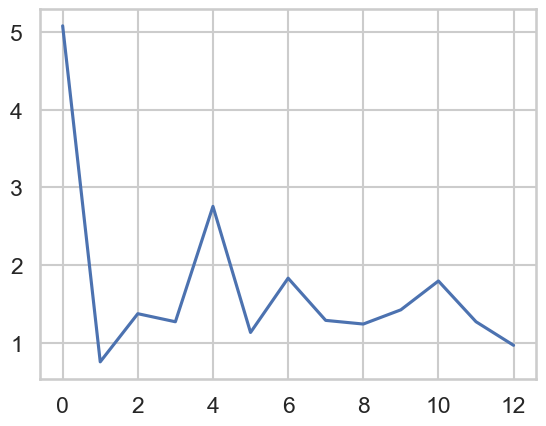

In [46]:
plt.plot(for_avg_props_raw['relative_spike_amplitude']['all'][0])

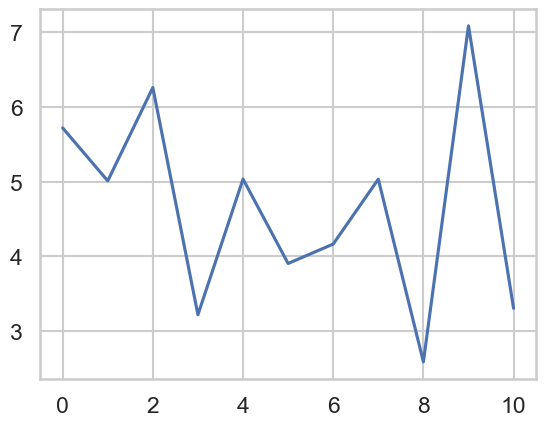

In [47]:
plt.plot(for_avg_props_raw['relative_spike_amplitude']['all'][1])

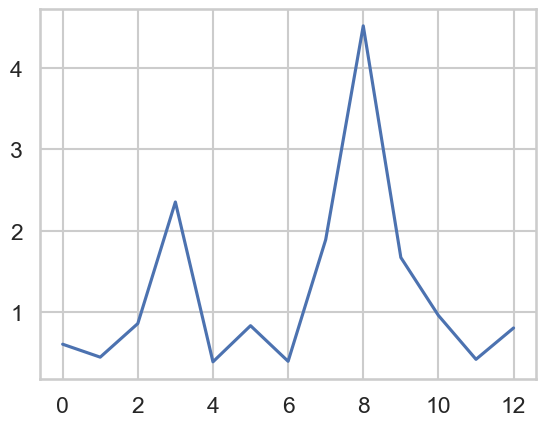

In [52]:
plt.plot(for_avg_props_raw['rates']['all'][0])


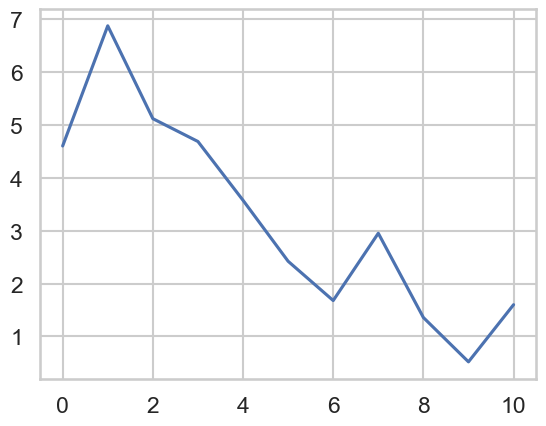

In [53]:
plt.plot(for_avg_props_raw['rates']['all'][1])


In [54]:
for_avg_props_raw

{'rates': {'all': [[0.6,
    0.4404975860732283,
    0.8545160526019369,
    2.3522134764408382,
    0.38279099292793634,
    0.8284517961870503,
    0.389538299730245,
    1.8876498759045008,
    4.522527841812027,
    1.6684161864177,
    0.9542531060938615,
    0.4137417424043911,
    0.8],
   [4.6,
    6.8700747625782865,
    5.116096025186932,
    4.684306154894399,
    3.5732084591008557,
    2.4212667933347927,
    1.678895659743816,
    2.95040164098529,
    1.3577425267588443,
    0.520380108759443,
    1.6]],
  'ipsi': [[0.6,
    0.35239806885858266,
    0.7509383492562475,
    1.8294993705650964,
    0.38279099292793634,
    0.41422589809352517,
    0.389538299730245,
    1.8876498759045008,
    4.334089181736526,
    1.6684161864177,
    0.9542531060938615,
    0.4137417424043911,
    0.8],
   [2.0,
    2.626793291574051,
    2.361275088547815,
    0.425846014081309,
    1.8806360311057135,
    0.6053166983336982,
    0.0,
    1.8966867692048293,
    0.19396321810840633,
  